In [1]:
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import RegularGridInterpolator
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic
import ipywidgets as widgets
import random


In [104]:
%load_ext autoreload
%autoreload 2

import sys
for p in ['../src']:
    if p not in sys.path:
        sys.path.append(p)
        
import spikeml as sml
from spikeml.utils.nb_util import xdisplay, Markup
from spikeml.core.signal import signal_dc, signal_pulse, encode1_onehot, encode_onehot, signal_ranges, mean_per_input
from spikeml.core.ngram import build_ngram, ngram_find, ngram_msample, print_ngrams

from spikeml.plot.plot_util import plot_hist, plot_data, plot_lidata, plot_input, plot_xt, plot_mt, plot_spikes, imshow_matrix, imshow_nmatrix
from spikeml.core.params import Params, LayerParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams

from spikeml.core.params import Params, LayerParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams
from spikeml.ui.ipywidgets_ui import ui

from spikeml.core.matrix import matrix_split, normalize_matrix, _mult, cmask, cmask2, matrix_init, matrix_init2
from spikeml.core.monitor import Monitor

from spikeml.core.spikes import pspike, spike
from spikeml.core.base import Component, Module, Fan, Composite, Chain
from spikeml.core.snn import Layer, SimpleLayer, LinearLayer, SNN, SSNN, SSensor, DSSNN, Connector, LinearConnector, RateConnector, LIConnector, LIConnector2
from spikeml.core.chain import make_snn_chain, make_ssnn_chain, make_ssnn_rate_chain, chain_validate
from spikeml.core.snn import ssnn_apply_update
from spikeml.core.feedback import compute_error, xcompute_error, compute_sg, FeedbackAdapter
from spikeml.core.runner import run, nrun, Context, run_with, run_with_feedback

from spikeml.core.snn_monitor import SSensorMonitor, LayerMonitor, SNNMonitor, SSNNMonitor, ConnectorMonitor, LIConnectorMonitor
from spikeml.core.snn_viewer import  SSensorMonitorViewer, LayerMonitorViewer, SNNMonitorViewer, SSNNMonitorViewer, ConnectorMonitorViewer, LIConnectorMonitorViewer, ErrorMonitorViewer
from spikeml.core.snn_stats import connector_stats, htest_connections, htest_connector_identity
from spikeml.core.snn_stats_viewer import plot_snn_stats

from spikeml.core.optimize import make_params_spec, vec2dic, setattrs, params_search, set_all_attrs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
SEED=37
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(edgeitems=3, infstr='inf', linewidth=120, nanstr='nan', precision=4, suppress=False, threshold=1000, formatter=None)


# Experiments

In [4]:
def test_run_ssnn(size=None, T=None, ss=None, body=None, params=None, feedback=True, callback=None, plot=True, log_step=1, options=None):
    if params is None:
        params = SSNNParams()
        print(params.fmt())
    nn = make_ssnn_rate_chain(size=size, body=body, params=params)
    #nn.log()
    chain_validate(nn)
    #print('-'*10)
    result = run_with_feedback(nn, source=ss,  T=T, params=params, feedback=feedback, callback=callback, plot=plot, log_step=log_step, options=options)
    return result


def test_nrun_ssnn(runs=3, ss=None, body_creator=None, params=None, size=None, feedback=True, plot=False, log_runs=1, log_step=-1, options=None):
    if params is None:
        params = SSNNParams()
        print(params.fmt())
    def nn_creator(n,_):
        body = body_creator(params) if body_creator is not None else None
        return make_ssnn_rate_chain(name=f'nn{n}', size=size, body=body, params=params)
    results = nrun(nn_creator= nn_creator, runs=runs, ss=ss, params=params, feedback=feedback, plot=plot, log_runs=log_runs, log_step=log_step)
    return results



## Simple 1+1 Layer Chain SSNN/RC:
###  `[10|01]* -> | SS:2 | SSNN/RC:2x2 | <`  


SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=5.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=30.0,e_b=2,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x000002441145EFE0> :
  nn.s <spikeml.core.snn.SSensor object at 0x00000244222A5B40> : (2,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x000002441145C460> : (2, 2) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x000002441145C8B0> : (2, 2)
t= 0:
nn.s: sx=[0.5 0. ]; s=[0.5 0. ]  -> zs=[1 0]
nn.1: s=[0.5 0. ] | zs=[1 0] -> y=[0.05 0.05] | zy=[0 0]


----------
t= 4000:
nn.s: sx=[0.  0.5]; s=[0.     0.7137]  -> zs=[0 1]
nn.1: s=[0.     0.7137] | zs=[0 1] -> y=[0. 1.] | zy=[0 1]


----------
nn:
   mean_error: 0.2271
   0: [0.5 0. ] (#2000): Err: 0.2520
   1: [0.  0.5] (#2000): Err: 0.2023
   0: [0.5 0. ] ([(0, 199), (400, 599), (800, 999), (1200, 1399), (1600, 1799), (2000, 2199), (2400, 2599), (2800, 2999), (3200, 3399), (3600, 3799)]): Err: 0.2520
   1: [0.  0.5] ([(200, 399), (600, 799), (1000, 1199), (1400, 1599), (1800, 1999), (2200, 2399), (2600, 2799), (3000, 3199), (3400, 3599), (3800, 3999)]): Err: 0.2023
nn.s.zs:
  0: [0.5 0. ] (#2000); N:[1189, 328] ([0.78, 0.22];[1.00, 0.00])
  1: [0.  0.5] (#2001); N:[236, 1193] ([0.17, 0.83];[0.00, 1.00])
  0: [0.5 0. ] ([(0, 199), (400, 599), (800, 999), (1200, 1399), (1600, 1799), (2000, 2199), (2400, 2599), (2800, 2999), (3200, 3399), (3600, 3799)]); N:[[125, 71], [129, 67], [130, 56], [119, 65], [127, 0], [103, 2], [116, 0], [110, 67], [109, 0], [121, 0]] ([[0.64, 0.36], [0.66, 0.34], [0.70, 0.30], [0.65, 0.35], [1.00, 0.00], [0.98, 0.02], [1.00, 0.00], [0.62, 0.38], [1.00, 0.00], [1.00, 0.00]];[[1.00, 0.00], 

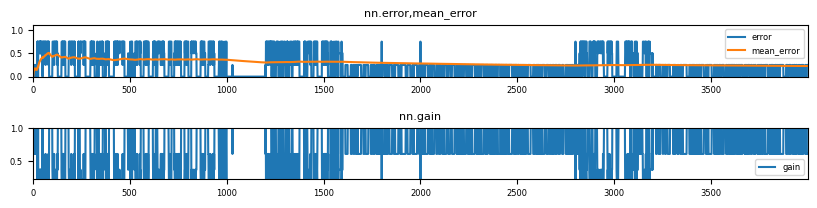

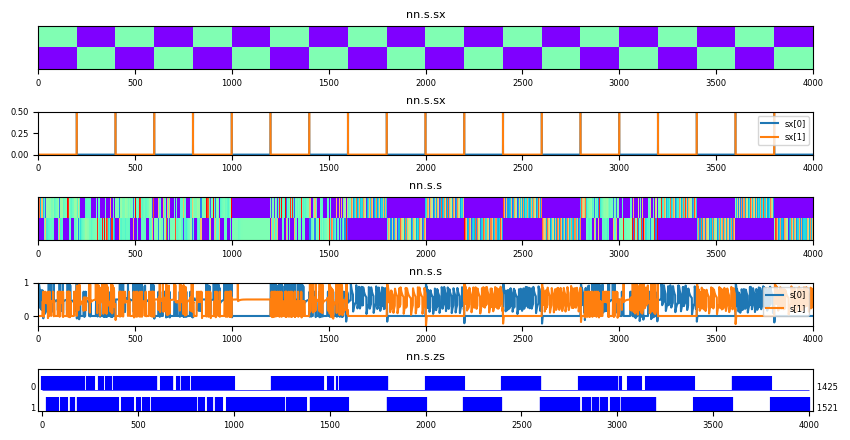

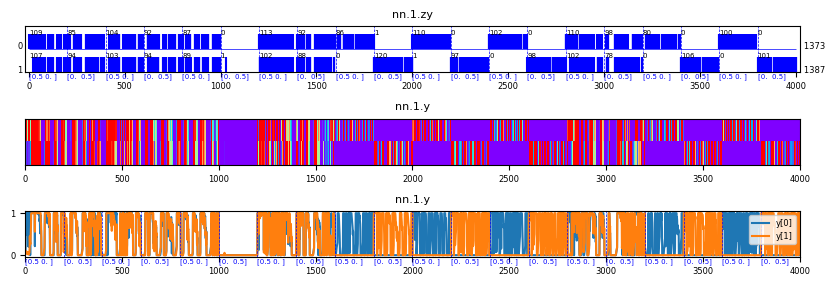

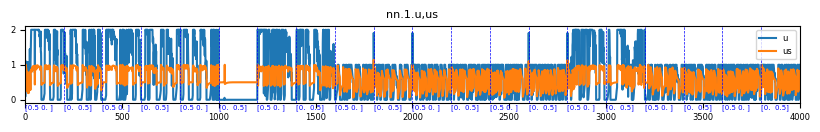

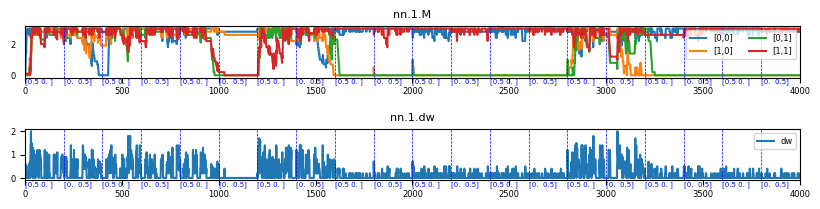

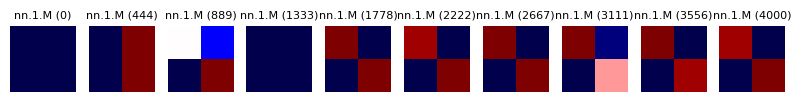

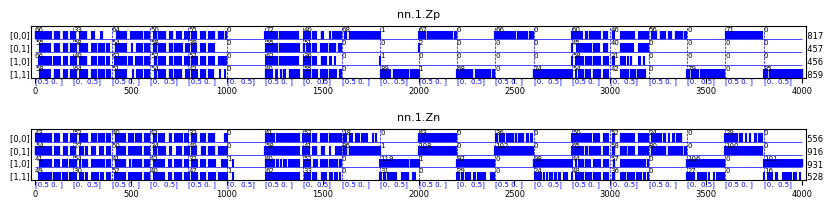

In [54]:
print(SSNNParams().fmt())
params_2_2 = SSNNParams(g=2,  e_err=2, t_p=2, t_d=5, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=30, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_2_2.fmt())
ss_0_1 = signal_pulse(2, T=200, L=10, s=[0,1], value=.5)
ss_0_1_= signal_pulse(2, T=100, L=1, s=[0,-1,1,-1], value=.5)
#ss_0= signal_pulse(2, T=500, L=1, s=[0], value=.5)


SIZE_2_2=[2,2]

options = None
#options = {'log.matrix': False, 'log.err': False}
result_2_2 = test_run_ssnn(size=SIZE_2_2, ss=ss_0_1, params=params_2_2, log_step=0, options=options)
#result_2_2

SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=5.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=30.0,e_b=2,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.9


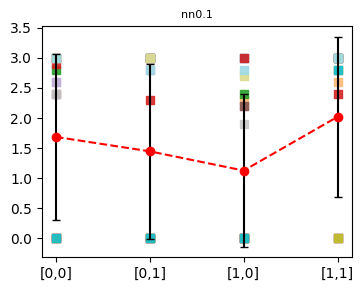

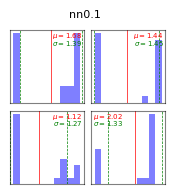

nn0.1: [0,0] x [1,0]]
  c1: [3.  2.6 0.  0.  2.8 3.  2.9 3.  0.  2.6 2.4 3.  0.  0.  0.  2.4 0.  3.  0.  3. ]
  c2: [3.  0.  0.  2.3 2.4 0.  3.  0.  0.  2.2 2.2 0.  0.  0.  0.  1.9 0.  2.7 0.  2.8]
  test: Mann-Whitney U test
  statistic: 256.0
  p-value: 0.11050316839646601
  reject_H0: False
nn0.1: [1,1] x [0,1]]
  c1: [3.  0.  2.8 2.6 3.  2.8 2.4 0.  0.  3.  3.  0.  3.  0.  3.  3.  0.  3.  2.8 3. ]
  c2: [3.  0.  0.  3.  3.  0.  2.3 0.  0.  2.8 3.  0.  3.  0.  0.  3.  0.  3.  0.  2.8]
  test: Mann-Whitney U test
  statistic: 238.0
  p-value: 0.2772125062607843
  reject_H0: False
nn0:
   mean_error: 0.3274
   0: [0.5 0. ] (#4001): Err: 0.3190
   1: [0.  0.5] (#3999): Err: 0.3358
   0: [0.5 0. ] ([(0, 200), (401, 600), (801, 1000), (1201, 1400), (1601, 1800), (2001, 2200), (2401, 2600), (2801, 3000), (3201, 3400), (3601, 3800), (4001, 4200), (4401, 4600), (4801, 5000), (5201, 5400), (5601, 5800), (6001, 6200), (6401, 6600), (6801, 7000), (7201, 7400), (7601, 7800)]): Err: 0.3190
   1:

In [58]:
params_2_2 = SSNNParams(g=2,  e_err=2, t_p=2, t_d=5, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=30, t_tdp=10, pmax=.9, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_2_2.fmt())
ss_0_1 = signal_pulse(2, T=200, L=20, s=[0,1], value=.5)
results_2_2 = test_nrun_ssnn(runs=20, size=SIZE_2_2, ss=ss_0_1, params=params_2_2, log_runs=-1, log_step=-1, options=options)
plot_snn_stats(results_2_2)
htest_connector_identity(results_2_2)    
results_2_2.log_monitor()

SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=5.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=30.0,e_b=2,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8


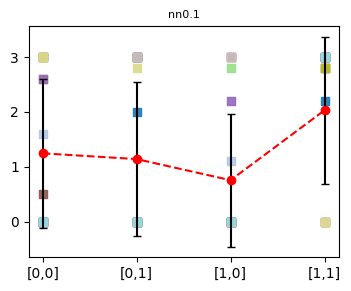

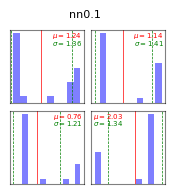

nn0.1: [0,0] x [1,0]]
  c1: [3.  1.6 0.  0.  0.  2.6 3.  2.6 2.6 0.  0.5 0.  0.  0.  0.  3.  3.  3.  0.  0. ]
  c2: [3.  1.1 0.  0.  0.  2.8 3.  0.  2.2 0.  0.  0.  0.  0.  0.  3.  0.  0.  0.  0. ]
  test: Mann-Whitney U test
  statistic: 239.5
  p-value: 0.2310782987262825
  reject_H0: False
nn0.1: [1,1] x [0,1]]
  c1: [2.2 3.  3.  3.  0.  3.  3.  0.  3.  0.  2.8 0.  3.  0.  2.8 3.  2.8 0.  3.  3. ]
  c2: [2.  3.  0.  0.  0.  3.  3.  0.  3.  0.  3.  0.  0.  0.  0.  3.  0.  2.8 0.  0. ]
  test: Mann-Whitney U test
  statistic: 256.5
  p-value: 0.10150022733063374
  reject_H0: False
nn0:
   mean_error: 0.3151
   0: [0.5 0. ] (#2001): Err: 0.3103
   1: [0.  0.5] (#1999): Err: 0.3199
   0: [0.5 0. ] ([(0, 200), (401, 600), (801, 1000), (1201, 1400), (1601, 1800), (2001, 2200), (2401, 2600), (2801, 3000), (3201, 3400), (3601, 3800)]): Err: 0.3103
   1: [0.  0.5] ([(201, 400), (601, 800), (1001, 1200), (1401, 1600), (1801, 2000), (2201, 2400), (2601, 2800), (3001, 3200), (3401, 3600), (3801

In [55]:
params_2_2 = SSNNParams(g=2,  e_err=2, t_p=2, t_d=5, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=30, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_2_2.fmt())
results_2_2 = test_nrun_ssnn(runs=20, size=SIZE_2_2, ss=ss_0_1, params=params_2_2, log_runs=-1, log_step=-1, options=options)
plot_snn_stats(results_2_2)
htest_connector_identity(results_2_2)    
results_2_2.log_monitor()

In [99]:
from spikeml.core.signal import stats_per_input, mean_per_input, sum_per_input, var_per_input, std_per_input

def _rate_stats(ref):
    monitor = ref.monitor
    sx = monitor._get_sensor_input()
    if sx is None:
        print('WARN: No sensor input', self)
        return None
    ref, size, n = sum_per_input(monitor.zy, sx, E=monitor.E)
    #ref_, ranges, n_ = sum_per_input(monitor.zy, sx, E=ref.E, aggregate=False)
    return ref, size, n
    
def rate_stats(results, split=True):
    layers = results.get_layers()
    rates = {}
    for i, layers_ in enumerate(layers):
        n_ = None
        n2 = None
        sx_ = None
        name = None
        nn = []
        size_ = None
        r_ = None
        r2 = None
        rr = []
        for layer in layers_:
            sx, size, n = _rate_stats(layer)
            r = n.copy() / size
            print('r:', r, 'n:', n, 'size:', size)
            if n_ is None:
                r_ = r
                n_ = n.copy()
                n2 = n**2
                r2 = r_**2
                sx_ = sx
                size_ = size 
                name = layer.name[0:layer.name.find('.')]
            else:
                n_ += n                
                n2 += n**2
                r_ += r
                r2 += n / size
            #print(layer.name, type(layer).__name__, sx, size)
            #print('n:', n)
            nn.append(n)
            rr.append(r)
            #print('nn:', nn)
        n_mean = n_/len(layers_)
        n_sd = np.sqrt(n2/len(layers_) - n_mean**2)
        r_mean = r_/len(layers_)
        r_sd = np.sqrt(r2/len(layers_) - r_mean**2)
        print('->r_mean:', r, 'r_sd:', r_sd)
        print('->nn:', nn)
        print('->rr:', rr)
        nn = np.array(nn)
        rr = np.array(rr)
        #print(layer.name, type(layer).__name__, 'sx:', sx, 'mean:', n_mean, n_sd)
        rates[name] = {'sx': sx, 'n_mean': n_mean, 'n_sd': n_sd, 'r_mean': r_mean, 'r_sd': r_sd, 'n': nn, 'r': rr}
        #plot_rates_layer(MM[i], title=conns_[0].name)
    if split:
        rates_ = {}
        for key, rates in rates.items():
            sx_rates = {}
            for i in range(rates['sx'].shape[0]):
                skey = str(rates['sx'][i].tolist()) 
                sx_rates[skey] = {'sx': rates['sx'][i], 'n_mean': rates['n_mean'][i], 'n_sd': rates['n_sd'][i], 
                                  'r_mean': rates['r_mean'][i], 'r_sd': rates['r_sd'][i], 'n': rates['n'][:,i], 'r': rates['r'][:,i]}
                #print(rates['n'])
            rates_[key] = sx_rates
        rates = rates_

    return rates


rates_2_2 = rate_stats(results_2_2)
print(rates_2_2)

r: [[0.4714 0.4026]
 [0.4316 0.4796]] n: [[1886 1610]
 [1727 1918]] size: [4001 3999]
r: [[5.1837e-01 2.5006e-04]
 [8.4479e-02 0.0000e+00]] n: [[2074    1]
 [ 338    0]] size: [4001 3999]
r: [[2.4994e-04 1.0228e-01]
 [0.0000e+00 5.2438e-01]] n: [[   1  409]
 [   0 2097]] size: [4001 3999]
r: [[0.4891 0.3531]
 [0.3269 0.4931]] n: [[1957 1412]
 [1308 1972]] size: [4001 3999]
r: [[0.4619 0.3903]
 [0.4191 0.4781]] n: [[1848 1561]
 [1677 1912]] size: [4001 3999]
r: [[0.5054 0.3068]
 [0.2859 0.4956]] n: [[2022 1227]
 [1144 1982]] size: [4001 3999]
r: [[0.4759 0.4704]
 [0.4711 0.4789]] n: [[1904 1881]
 [1885 1915]] size: [4001 3999]
r: [[5.2812e-01 2.5006e-04]
 [8.6228e-02 0.0000e+00]] n: [[2113    1]
 [ 345    0]] size: [4001 3999]
r: [[0.0002 0.0003]
 [0.     0.    ]] n: [[1 1]
 [0 0]] size: [4001 3999]
r: [[0.4711 0.4779]
 [0.4626 0.4736]] n: [[1885 1911]
 [1851 1894]] size: [4001 3999]
r: [[0.5056 0.2171]
 [0.1887 0.5084]] n: [[2023  868]
 [ 755 2033]] size: [4001 3999]
r: [[0.5176 0.001 

C:\Users\jsima\AppData\Local\Temp\ipykernel_5220\3026094846.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', data.shape[1])


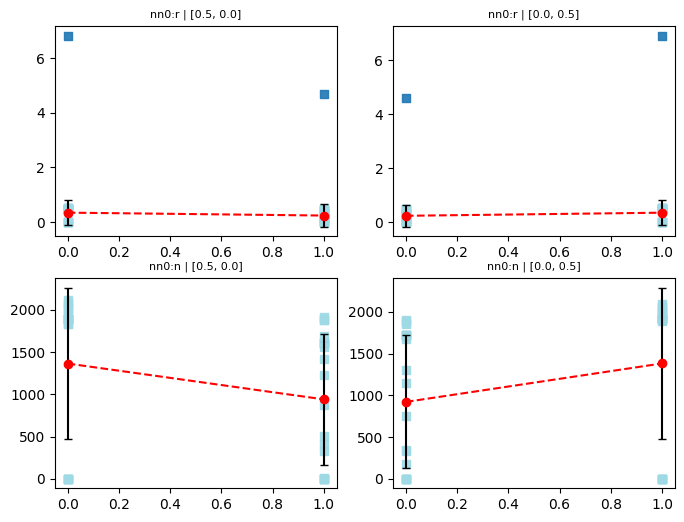

In [102]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib import cm


def _plot_rate_stats(m, sd, data=None, title=None, _type=None, callback=None, ax=None):

    xx = range(0, m.shape[0])
            
    fig = None
    if ax is None:
        nrows, ncols = 1, 1
        fig, axs = plt.subplots(nrows, ncols, figsize=(1*len(xx), 3*nrows))
        ax = axs if nrows==1 and ncols==1 else axs[i] if nrows==1 else axs[0][0]
            
    y = m.flatten()
    yerr = sd.flatten() if sd is not None else None
    #print('m:', m, 'sd:', sd)
    #print('xx:', xx, 'y:', y, 'yerr:', yerr)

    ax.errorbar(xx, y, yerr=yerr, capsize=3, fmt="r--o", ecolor = "black")
    if data is not None:
        colors = cm.get_cmap('tab20', data.shape[1])
        for i in range(data.shape[0]):
            ax.scatter(xx, data[i], color=colors(i), marker='s', s=30, alpha=0.9)
          
    if callback is not None:
        callback(ax)
    
    if title is not None:
        tstyle = { 'fontsize': 8 }
        ax.set_title(title, **tstyle)

    #ax.legend(fontsize=6)
    #ax.tick_params(axis='both', which='major', labelsize=6)
    #ax.tick_params(axis='both', which='minor', labelsize=6)
    #if xlabel is not None:
    #    ax.set_xlabel(xlabel, fontsize=6)
    #if ylabel is not None:
    #    ax.set_xlabel(ylabel, fontsize=6)

    if fig is not None:
        #plt.tight_layout()
        plt.show()

def plot_rate_stats(rates, title=None, _type=None, callback=None):
    for key,rates_ in rates.items():
        nrows, ncols = 2, len(rates_.keys())
        fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
        for i, (sx_name,sx_rates) in enumerate(rates_.items()):
            #ax = axs if nrows==1 and ncols==1 else axs[i] if nrows==1 else axs[0][i]
            _plot_rate_stats(sx_rates['r_mean'], sx_rates['r_sd'], sx_rates['r'], title=f'{key}:r | {sx_name}', ax=axs[0][i])
            _plot_rate_stats(sx_rates['n_mean'], sx_rates['n_sd'], sx_rates['n'], title=f'{key}:n | {sx_name}', ax=axs[1][i])

plot_rate_stats(rates_2_2)

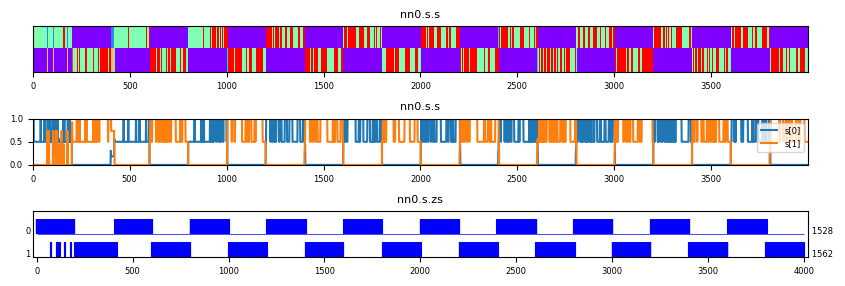

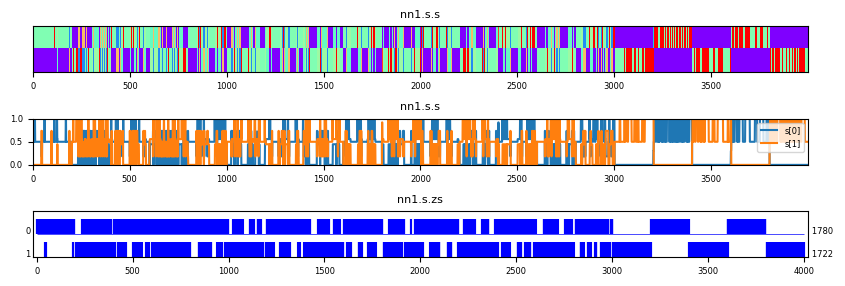

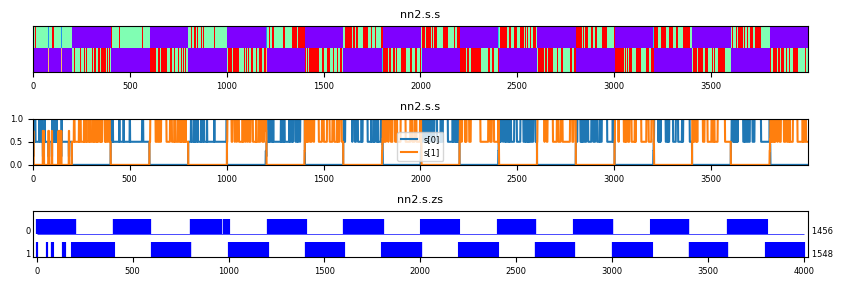

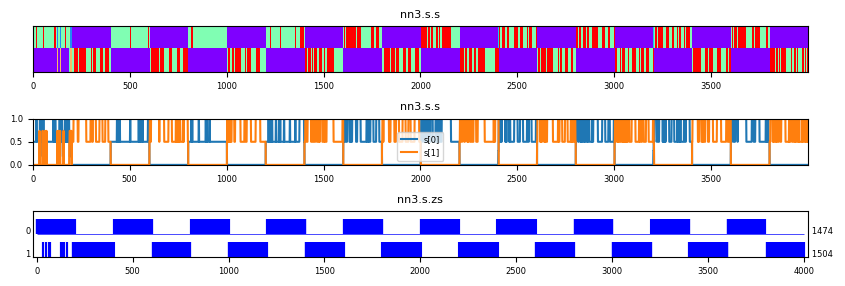

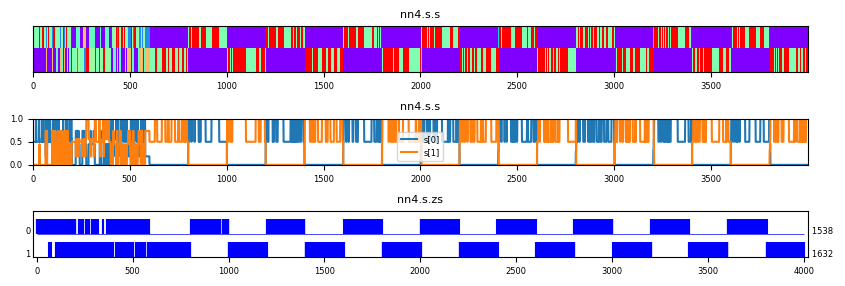

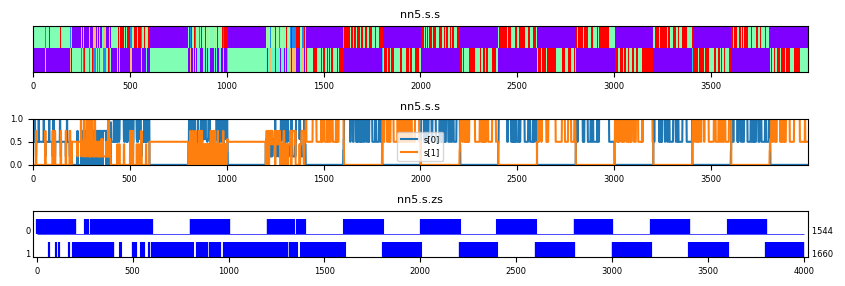

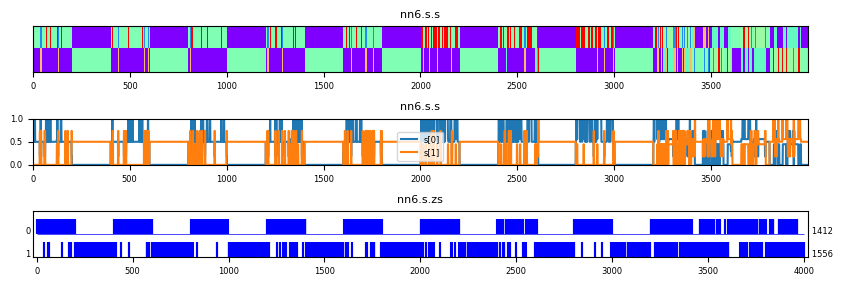

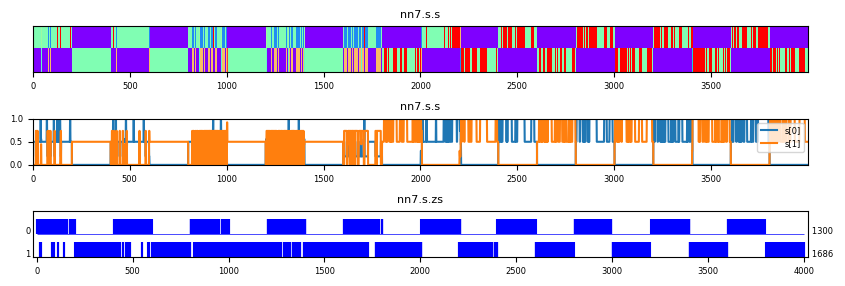

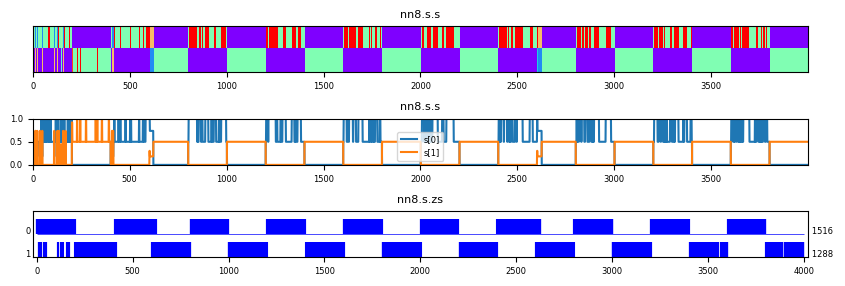

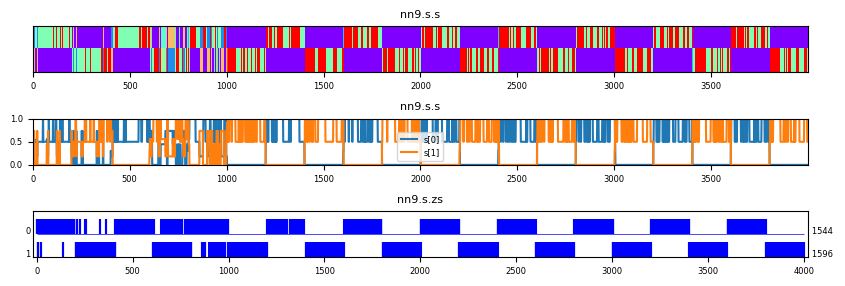

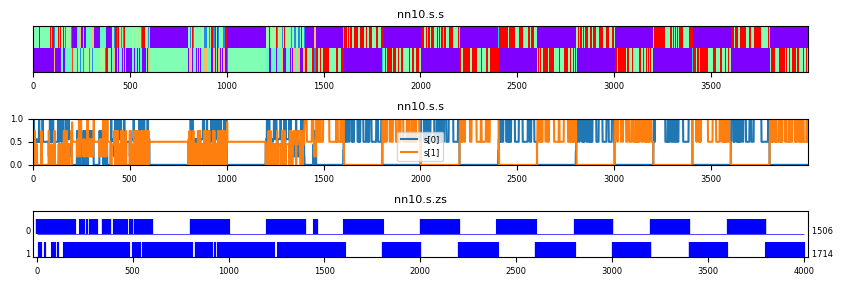

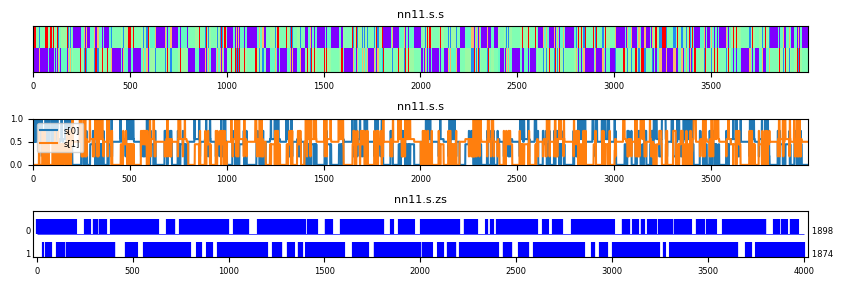

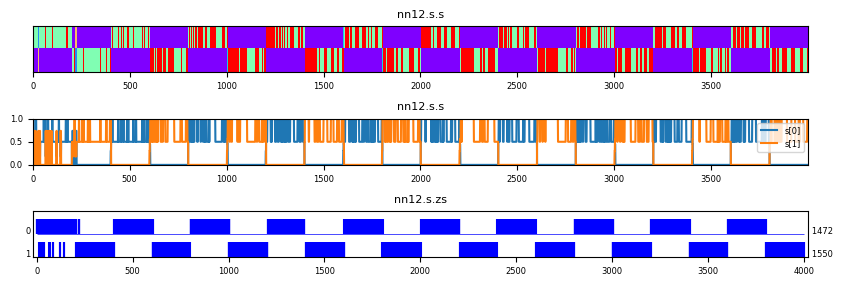

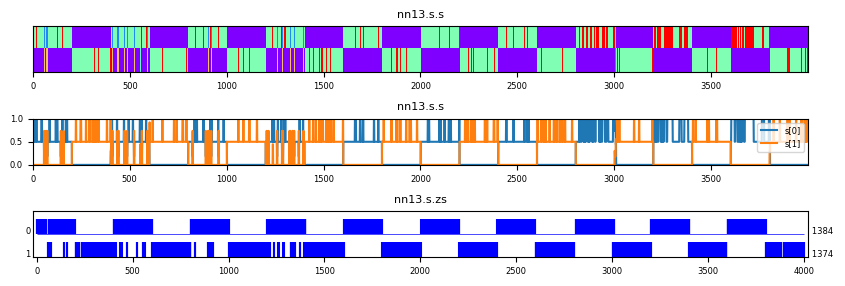

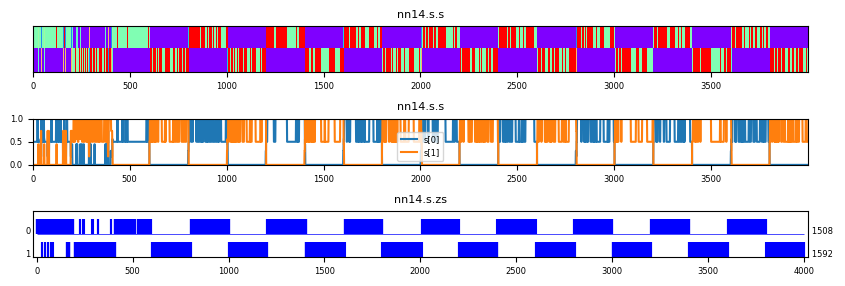

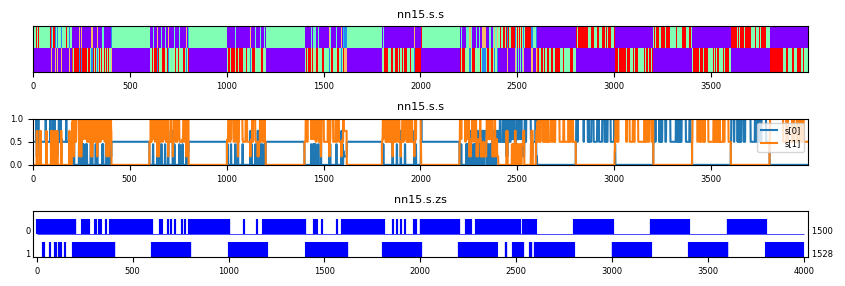

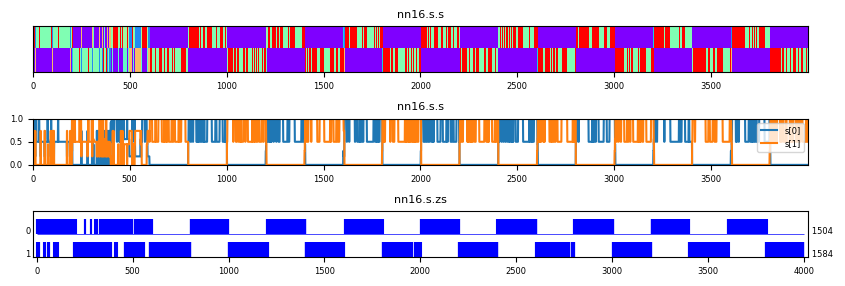

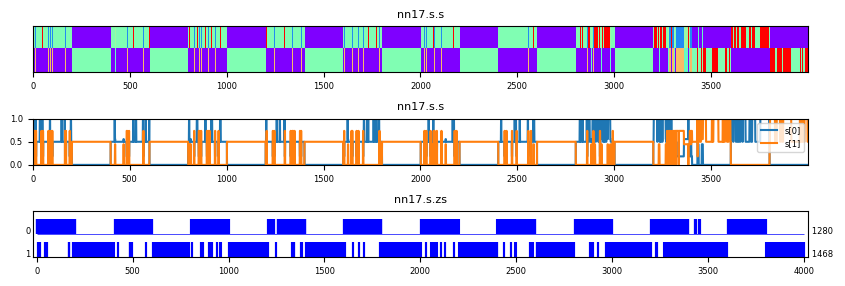

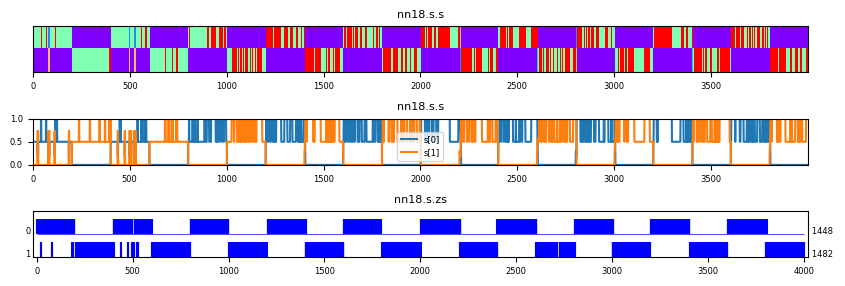

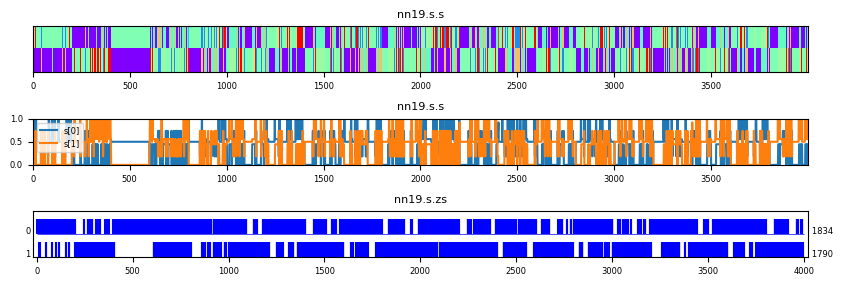

In [34]:
#plot_snn_stats(results_2_2)
S_ = ['sx', 's', 'zs']
Y_ = ['zy', 'y', 'r'] + ['u']
X_ = ['k_x']
C = ['M', 'dw']
CZ = ['Wp', 'Wn', 'Zp', 'Zn', '_Cp', '_Cn']

def _render(result, *args):
    nn = result['nn']
    options = args[0]
    nn.render(options)              
   
from spikeml.core.snn_viewer import  SSensorMonitorViewer, LayerMonitorViewer, SNNMonitorViewer, SSNNMonitorViewer, ConnectorMonitorViewer, LIConnectorMonitorViewer, ErrorMonitorViewer
from spikeml.core.runner import run, nrun, Context

#results_2_2[0]['nn'].render({'include': ['s']})
results_2_2.iterate(_render, {'include': ['s', 'zs']})


## Chain - Body: Twist: 
### `[10|01]* -> | SS:2 | SSNN/RC:2x2 | L2x2 |<` 

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=2.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x000002440B5300A0> :
  nn.s <spikeml.core.snn.SSensor object at 0x000002440B533010> : (2,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x000002440B531540> : (2, 2) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x000002440B5309A0> : (2, 2)
  bd <spikeml.core.snn.LinearLayer object at 0x000002446D9F4130> : (2, 2) OK OK
t= 0:
nn.s: sx=[0.5 0. ]; s=[0.5 0. ]  -> zs=[1 0]
nn.1: s=[0.5 0. ] | zs=[1 0] -> y=[0.05 0.05] | zy=[0 0]


bd: s=[0.05 0.05] | zs=[0 0]-> y=[0.05 0.05] | zy=[0. 0.]


0.000,1.000
1.000,0.000


----------
t= 2000:
nn.s: sx=[0.  0.5]; s=[0.  0.5]  -> zs=[0 0]
nn.1: s=[0.  0.5] | zs=[0 0] -> y=[0. 0.] | zy=[0 0]


bd: s=[0. 0.] | zs=[0 0]-> y=[0. 0.] | zy=[0. 0.]


0.000,1.000
1.000,0.000


----------
nn:
   mean_error: 0.0715
   0: [0.5 0. ] (#1000): Err: 0.1285
   1: [0.  0.5] (#1000): Err: 0.0145
   0: [0.5 0. ] ([(0, 99), (200, 299), (400, 499), (600, 699), (800, 899), (1000, 1099), (1200, 1299), (1400, 1499), (1600, 1699), (1800, 1899)]): Err: 0.1285
   1: [0.  0.5] ([(100, 199), (300, 399), (500, 599), (700, 799), (900, 999), (1100, 1199), (1300, 1399), (1500, 1599), (1700, 1799), (1900, 1999)]): Err: 0.0145
nn.s.zs:
  0: [0.5 0. ] (#1000); N:[589, 1] ([1.00, 0.00];[1.00, 0.00])
  1: [0.  0.5] (#1001); N:[22, 629] ([0.03, 0.97];[0.00, 1.00])
  0: [0.5 0. ] ([(0, 99), (200, 299), (400, 499), (600, 699), (800, 899), (1000, 1099), (1200, 1299), (1400, 1499), (1600, 1699), (1800, 1899)]); N:[[59, 1], [57, 0], [63, 0], [55, 0], [62, 0], [51, 0], [56, 0], [69, 0], [55, 0], [62, 0]] ([[0.98, 0.02], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0.00]];[[1.00, 0.00], [1.00, 0.00], [1.00, 0.00], [1.00, 0

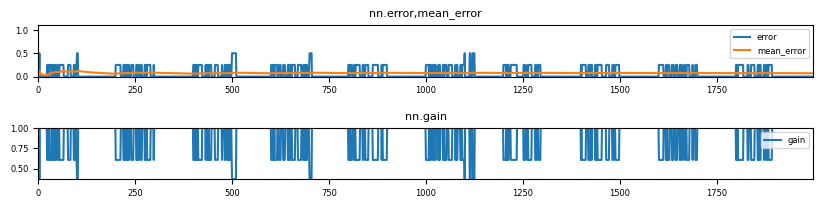

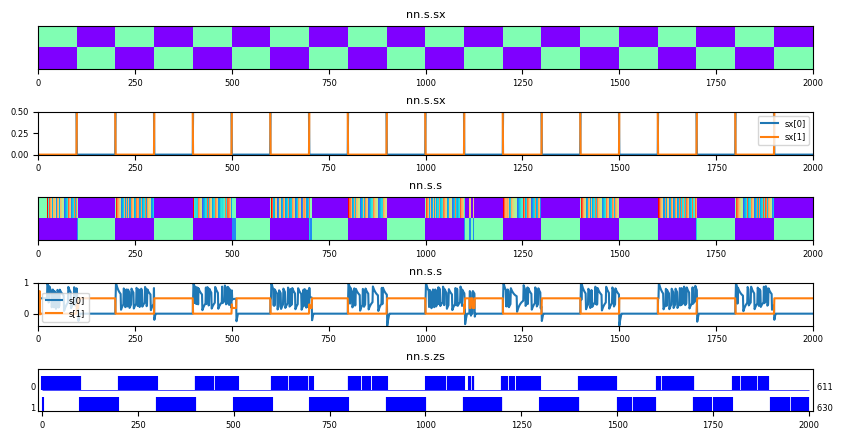

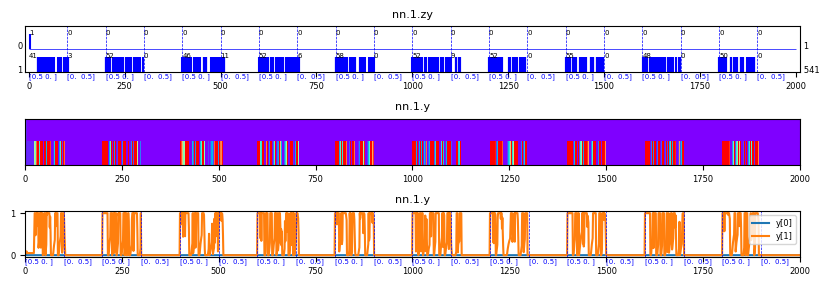

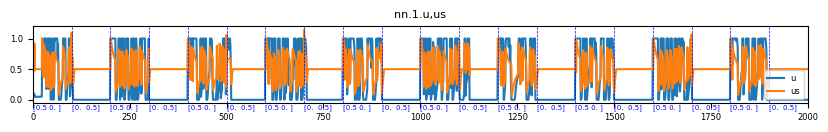

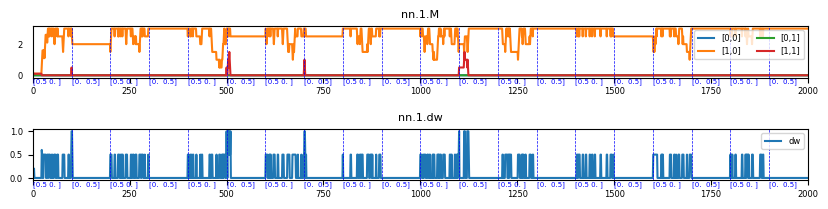

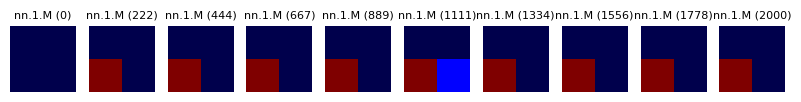

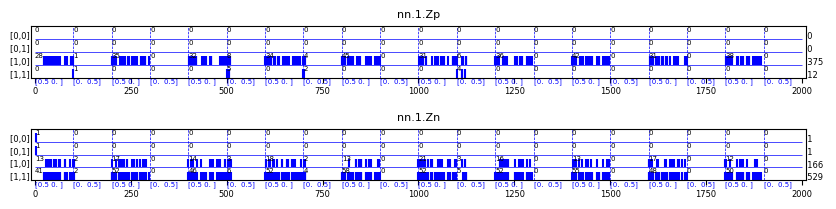

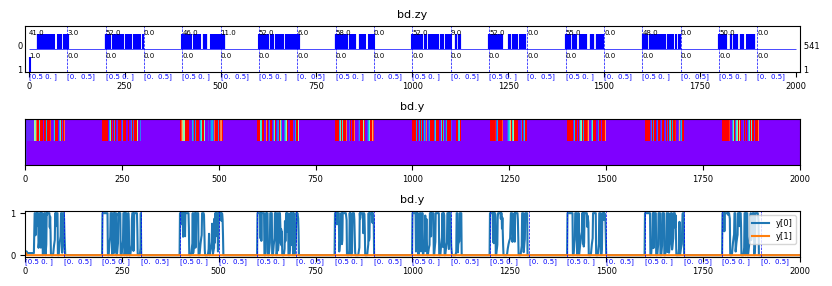

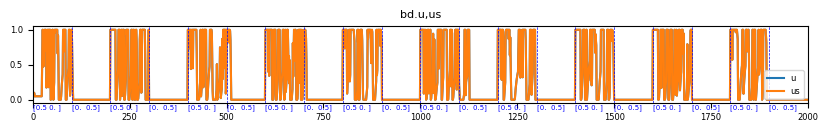

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x2440b531ea0>,
 'context': <spikeml.core.run.Context at 0x2440b5309d0>}

In [115]:
print(SSNNParams().fmt())
params_2_2_twist = SSNNParams(g=2,  e_err=2, t_p=2, t_d=2, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_2_2_twist.fmt())

ss_0_1 = signal_pulse(2, T=100, L=10, s=[0,1], value=.5)
ss_0_1_= signal_pulse(2, T=100, L=1, s=[0,-1,1,-1], value=.5)
#ss_0= signal_pulse(2, T=500, L=1, s=[0], value=.5)

SIZE_2_2=[2,2]

options = None
#options = {'log.matrix': False, 'log.err': False}
M_2_2_twist = np.ones(SIZE_2_2) - np.identity(2)
body_2_2_twist = LinearLayer(M_2_2_twist, name='bd', params=params_2_2_twist, auto_sample=True)
result_2_2_twist = test_run_ssnn(size=SIZE_2_2, ss=ss_0_1, body=body_2_2_twist, params=params_2_2_twist, log_step=0, options=options)
result_2_2_twist

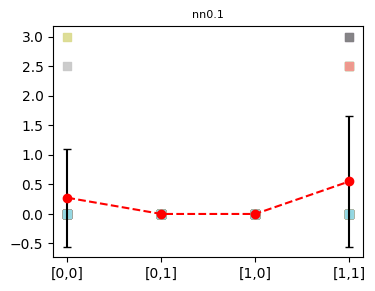

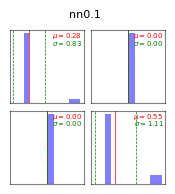

nn0.1: [0,0] x [1,0]]
  c1: [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  2.5 0.  3.  0.  0. ]
  c2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  test: Mann-Whitney U test
  statistic: 220.0
  p-value: 0.16258685072635493
  reject_H0: False
nn0.1: [1,1] x [0,1]]
  c1: [0.  0.  0.  0.  2.5 0.  0.  2.5 0.  3.  0.  0.  0.  0.  3.  0.  0.  0.  0.  0. ]
  c2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  test: Mann-Whitney U test
  statistic: 240.0
  p-value: 0.04009236218470621
  reject_H0: True
nn0:
   mean_error: 0.0004
   0: [0.5 0. ] (#1001): Err: 0.0007
   1: [0.  0.5] (#999): Err: 0.0000
   0: [0.5 0. ] ([(0, 100), (201, 300), (401, 500), (601, 700), (801, 900), (1001, 1100), (1201, 1300), (1401, 1500), (1601, 1700), (1801, 1900)]): Err: 0.0007
   1: [0.  0.5] ([(101, 200), (301, 400), (501, 600), (701, 800), (901, 1000), (1101, 1200), (1301, 1400), (1501, 1600), (1701, 1800), (1901, 1999)]): Err: 0.0000
nn1:
   mean_error: 0.0004
 

In [114]:
results_2_2_twist = test_nrun_ssnn(runs=20, size=SIZE_2_2, ss=ss_0_1, params=params_2_2_twist, log_runs=0, log_step=-1, options=options)
plot_snn_stats(results_2_2_twist)
htest_connector_identity(results_2_2_twist)    
results_2_2_twist.log_monitor()

## Chain 2 SSNN Layers:
### `[10|01]* -> |SS2 | SSNN/RC:2x2x2 |<` 

SSNNParams:c_k=2,t_c=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1,t_b=20,e_b=2
SSNNParams:c_k=2,t_c=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8,t_b=20.0,e_b=2
nn <spikeml.core.base.Chain object at 0x000001E737B675E0> :
  nn.s <spikeml.core.snn.SSensor object at 0x000001E75124FEB0> : (2,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x000001E737B64970> : (2, 2) OK OK
  nn.2 <spikeml.core.snn.SSNN object at 0x000001E737B64220> : (2, 2) OK OK
t=0
nn.s: sx=[0.25 0.  ]; s=[0.25 0.  ]  -> zs=[0 0]
nn.1: s=[0.25 0.  ] | zs=[0 0] -> y=[0.025 0.025] | zy=[0 0]


nn.2: s=[0.025 0.025] | zs=[0 0] -> y=[0.005 0.005] | zy=[0 0]


sx=[0.25 0.  ]; sy=[0. 0.]; sg=1.00; s=[0.25 0.  ]; err=0.000
----------
t=3999
nn.s: sx=[0.   0.25]; s=[0.   0.25]  -> zs=[0 1]
nn.1: s=[0.   0.25] | zs=[0 1] -> y=[0. 0.] | zy=[0 0]


nn.2: s=[0. 0.] | zs=[0 0] -> y=[0. 0.] | zy=[0 0]


sx=[0.   0.25]; sy=[0. 0.]; sg=1.00; s=[0.   0.25]; err=0.000
----------
nn:
   merr: 0.1943
   0: [0.25 0.  ] (#2001): Err: 0.3056
   1: [0.   0.25] (#1999): Err: 0.0828
   0: [0.25 0.  ] ([(0, 200), (401, 600), (801, 1000), (1201, 1400), (1601, 1800), (2001, 2200), (2401, 2600), (2801, 3000), (3201, 3400), (3601, 3800)]): Err: 0.3056
   1: [0.   0.25] ([(201, 400), (601, 800), (1001, 1200), (1401, 1600), (1801, 2000), (2201, 2400), (2601, 2800), (3001, 3200), (3401, 3600), (3801, 3999)]): Err: 0.0828
nn.s.zs:
  0: [0.25 0.  ] (#4002); N:[1900, 790] ([0.71, 0.29];[1.00, 0.00])
  1: [0.   0.25] (#3998); N:[224, 1656] ([0.12, 0.88];[0.00, 1.00])
  0: [0.25 0.  ] ([(0, 401), (802, 1201), (1602, 2001), (2402, 2801), (3202, 3601), (4002, 4401), (4802, 5201), (5602, 6001), (6402, 6801), (7202, 7601)]); N:[[146, 0], [180, 34], [202, 30], [234, 66], [180, 100], [220, 110], [156, 118], [190, 128], [198, 116], [194, 88]] ([[1.00, 0.00], [0.84, 0.16], [0.87, 0.13], [0.78, 0.22], [0.64, 0.36], [0

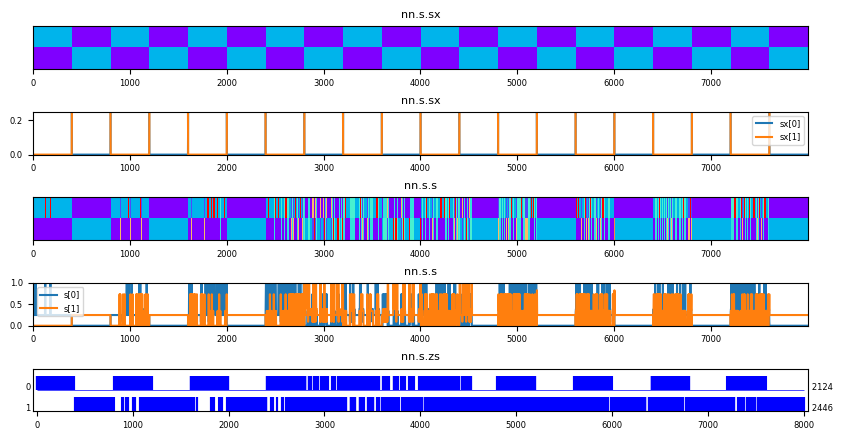

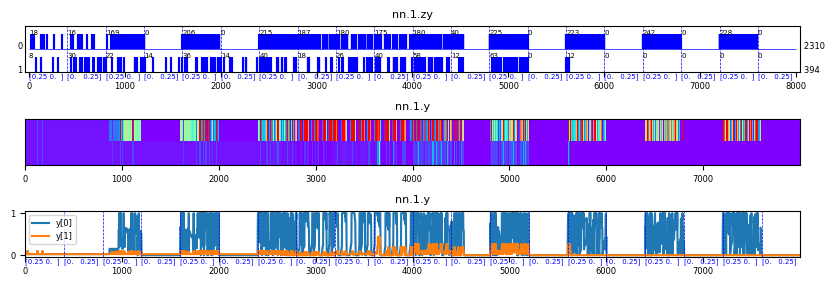

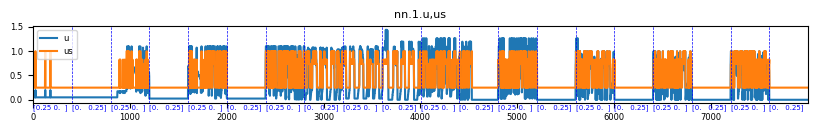

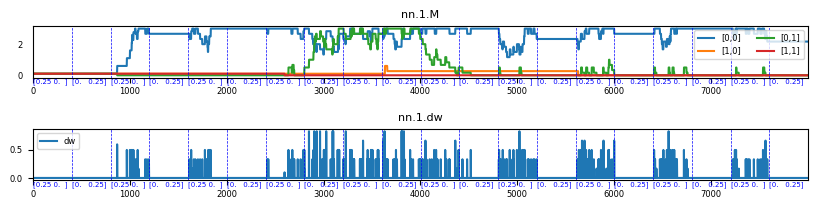

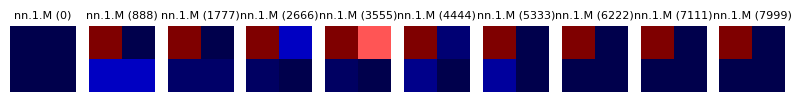

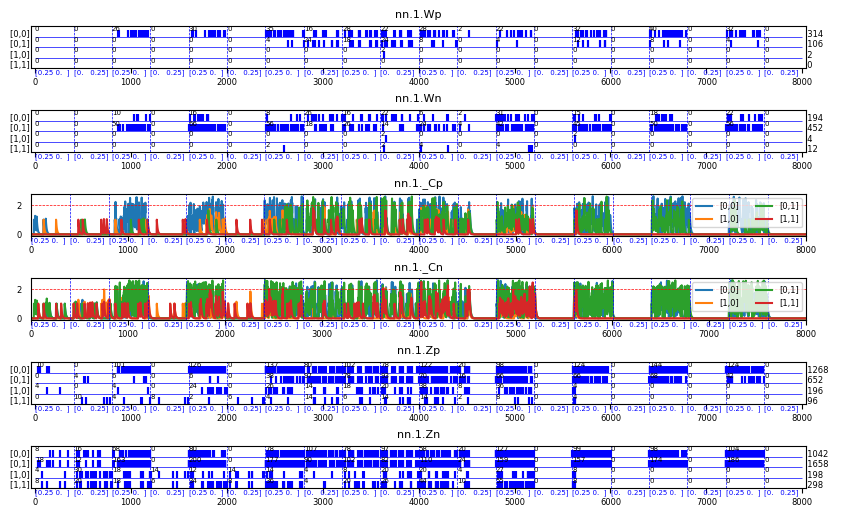

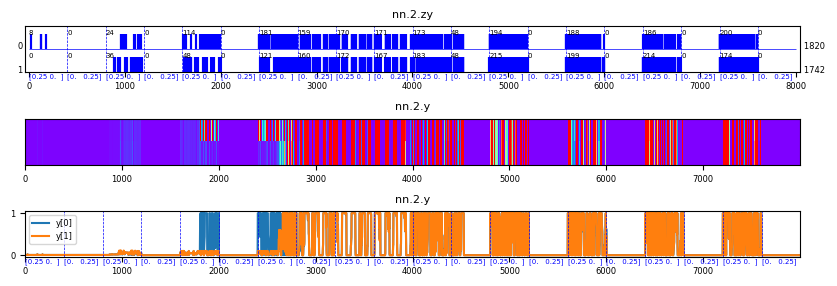

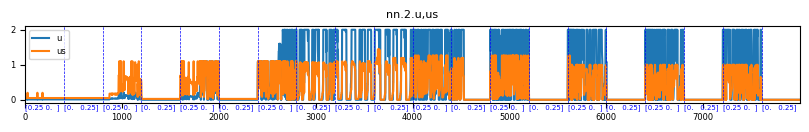

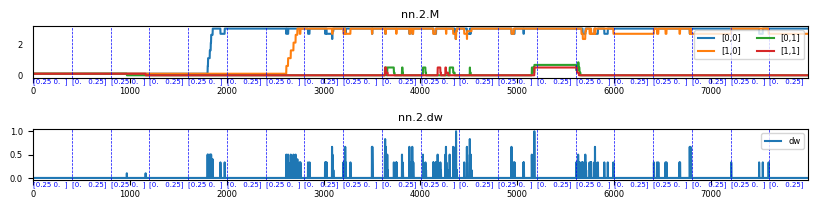

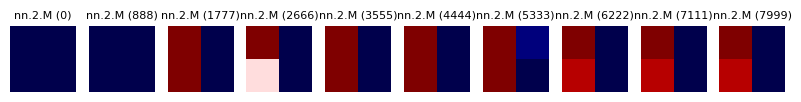

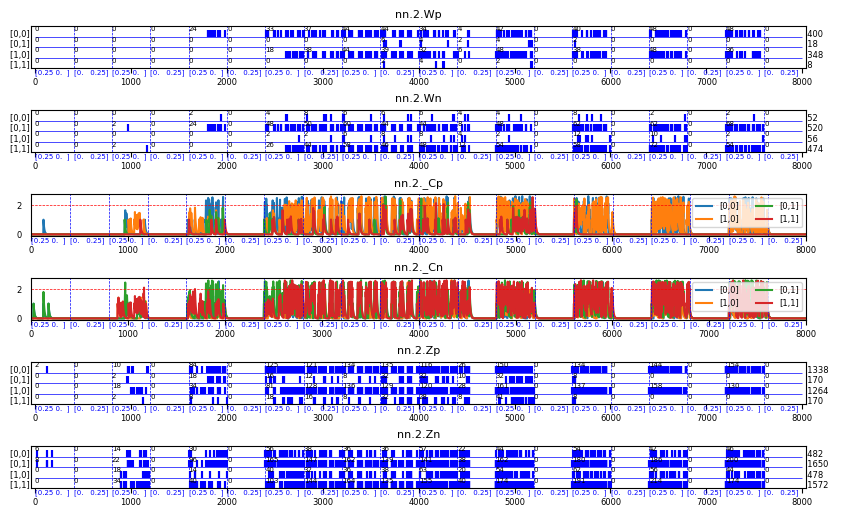

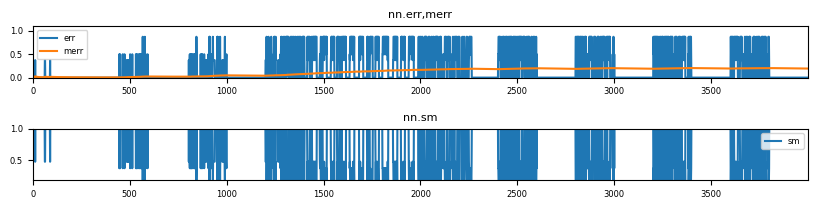

{'nn': <spikeml.core.base.Chain at 0x1e737b675e0>,
 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor at 0x1e7553f8b50>,
 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer at 0x1e7553f8190>,
 'context': Context(t=3999)}

In [ ]:
SNNParams().fmt())
params_2_2_2 = SSNNParams(g=2,  e_err=2, t_p=2, t_d=3, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_2_2_2.fmt())

sa = .25
ss_0_1 = signal_pulse(2, T=200, L=10, s=[0,1], value=sa)
ss_0_1_= signal_pulse(2, T=100, L=1, s=[0,-1,1,-1], value=sa)
#ss_0= signal_pulse(2, T=500, L=1, s=[0], value=sa)

SIZE_2_2_2=[2,2,2]

options = None
#options = {'log.matrix': False, 'log.err': False}
result_2_2_2 = test_run_ssnn(size=SIZE_2_2_2, ss=ss_0_1, params=params_2_2_2, log_step=0, options=options)
result_2_2_2

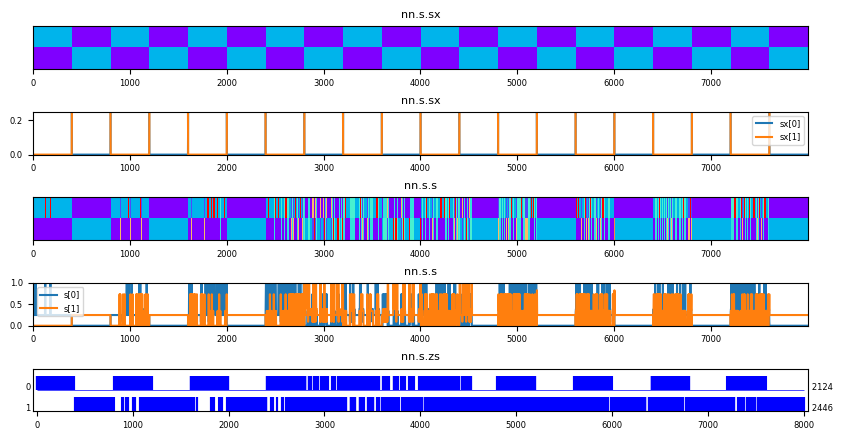

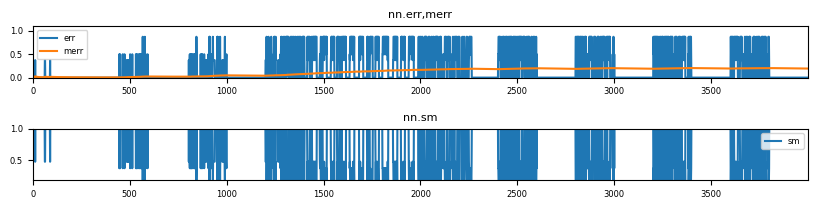

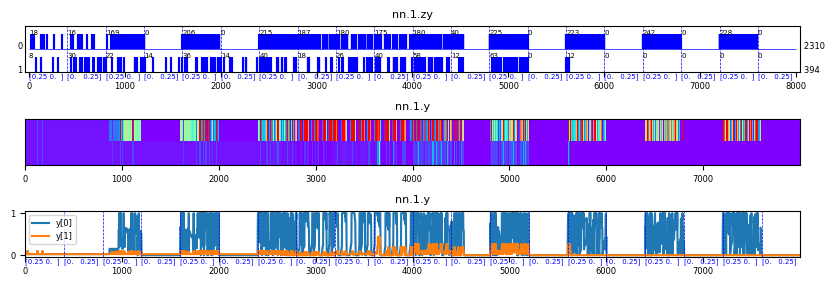

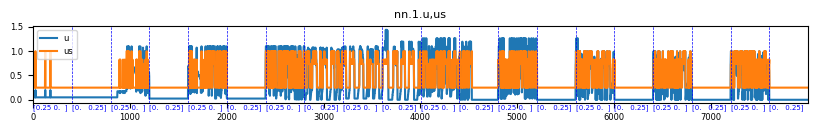

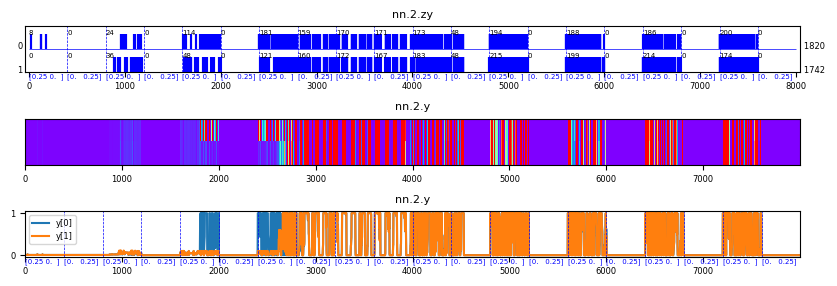

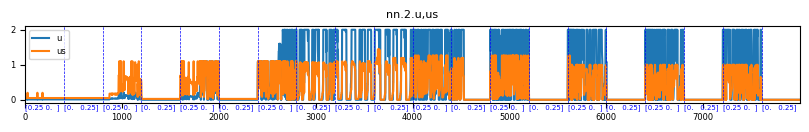

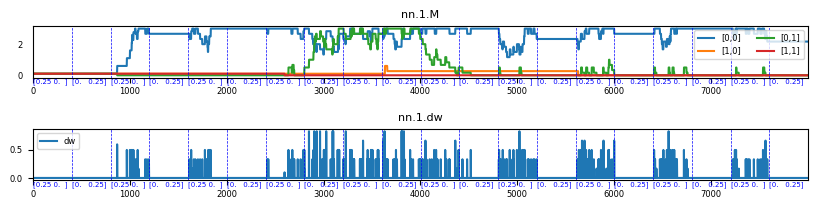

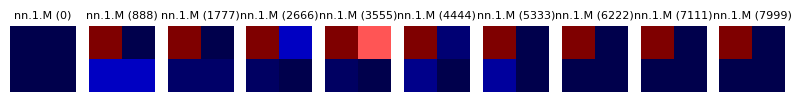

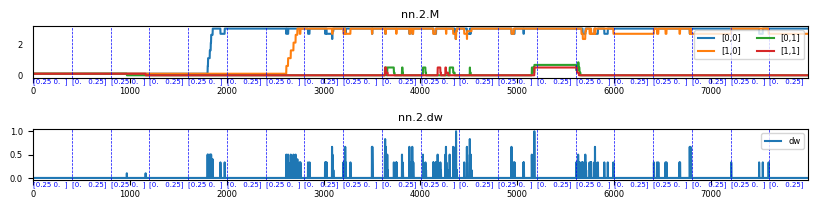

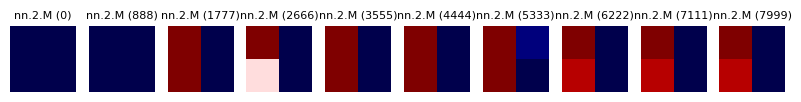

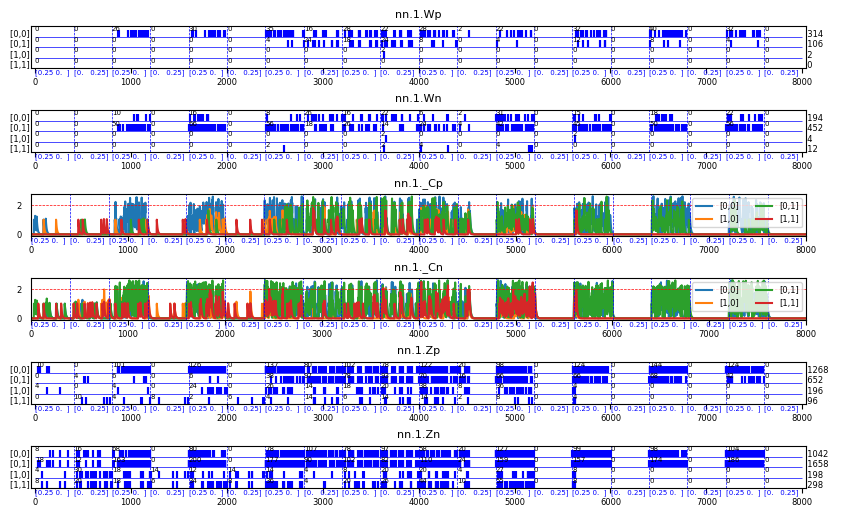

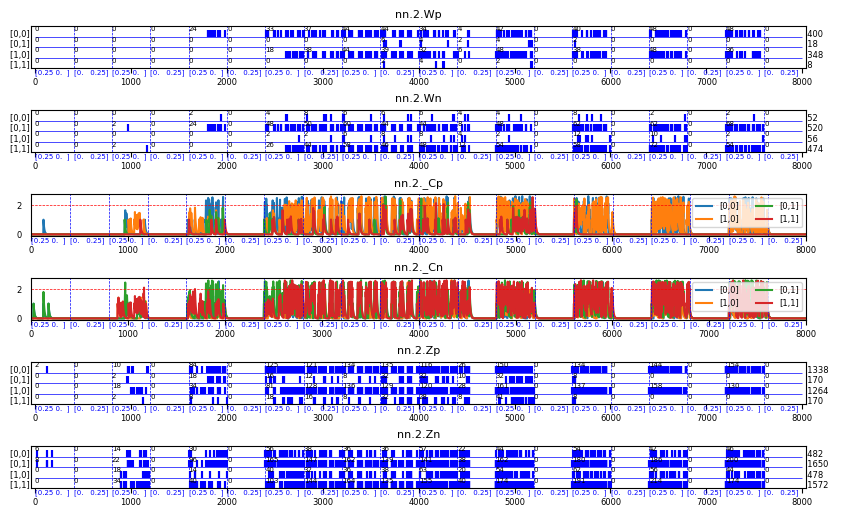

In [62]:
S_ = ['sx', 's', 'zs']
Y_ = ['zy', 'y', 'r'] + ['u']
X_ = ['k_x']
C_ = ['M', 'dw']
CZ_ = ['Wp', 'Wn', 'Zp', 'Zn', '_Cp', '_Cn']
ERR_ = ['err', 'sm']

result_2_2_2['nn'].render({'include': S_})
result_2_2_2['err_viewer'].render({'include': ERR_})
result_2_2_2['nn'].render({'include': ERR_})
result_2_2_2['nn'].render({'include': Y_ + X_})
result_2_2_2['nn'].render({'include': C_})
result_2_2_2['nn'].render({'include': CZ_})


In [ ]:
results_2_2_2 = test_nrun_ssnn(runs=20, size=SIZE_2_2_2, ss=ss_0_1, params=params_2_2_2, log_runs=1, log_step=-1, options=options)
plot_snn_stats(results_2_2_2)
htest_connector_identity(results_2_2_2)    
results_2_2_2".log_monitor()

## Chain - SSNN: 3x3

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=1.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x0000024425DD3E20> :
  nn.s <spikeml.core.snn.SSensor object at 0x0000024425DD0580> : (3,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x0000024425DD36D0> : (3, 3) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x0000024425DD1060> : (3, 3)
t= 0:
nn.s: sx=[0.5 0.  0. ]; s=[0.5 0.  0. ]  -> zs=[0 0 0]
nn.1: s=[0.5 0.  0. ] | zs=[0 0 0] -> y=[0.05 0.05 0.05] | zy=[0 0 0]


----------
t= 6000:
nn.s: sx=[0.  0.  0.5]; s=[0.     0.     0.3107]  -> zs=[0 0 0]
nn.1: s=[0.     0.     0.3107] | zs=[0 0 0] -> y=[0.     0.     0.1138] | zy=[0 0 0]


----------
nn:
   mean_error: 0.2044
   0: [0.5 0.  0. ] (#2000): Err: 0.2505
   1: [0.  0.5 0. ] (#2000): Err: 0.1687
   2: [0.  0.  0.5] (#2000): Err: 0.1941
   0: [0.5 0.  0. ] ([(0, 199), (600, 799), (1200, 1399), (1800, 1999), (2400, 2599), (3000, 3199), (3600, 3799), (4200, 4399), (4800, 4999), (5400, 5599)]): Err: 0.2505
   1: [0.  0.5 0. ] ([(200, 399), (800, 999), (1400, 1599), (2000, 2199), (2600, 2799), (3200, 3399), (3800, 3999), (4400, 4599), (5000, 5199), (5600, 5799)]): Err: 0.1687
   2: [0.  0.  0.5] ([(400, 599), (1000, 1199), (1600, 1799), (2200, 2399), (2800, 2999), (3400, 3599), (4000, 4199), (4600, 4799), (5200, 5399), (5800, 5999)]): Err: 0.1941
nn.s.zs:
  0: [0.5 0.  0. ] (#2000); N:[1167, 206, 221] ([0.73, 0.13, 0.14];[1.00, 0.00, 0.00])
  1: [0.  0.5 0. ] (#2000); N:[176, 1171, 128] ([0.12, 0.79, 0.09];[0.00, 1.00, 0.00])
  2: [0.  0.  0.5] (#2001); N:[151, 264, 1131] ([0.10, 0.17, 0.73];[0.00, 0.00, 1.00])
  0: [0.5 0.  0. ] ([(0, 199), (600, 799), (1200, 1399

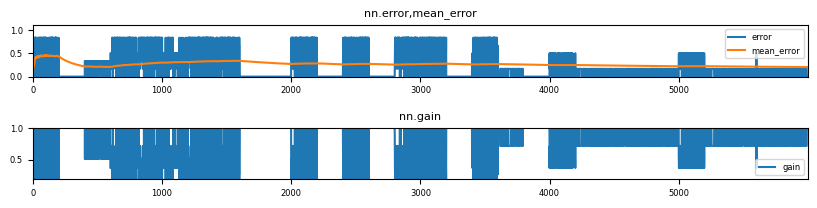

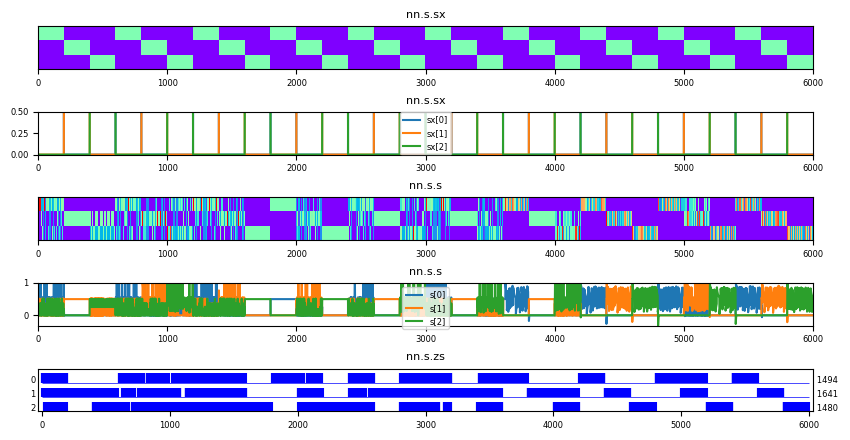

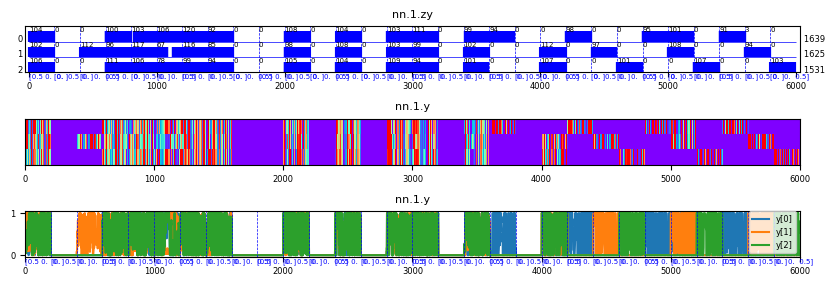

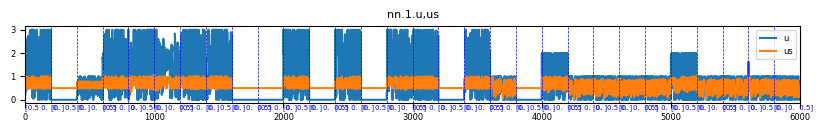

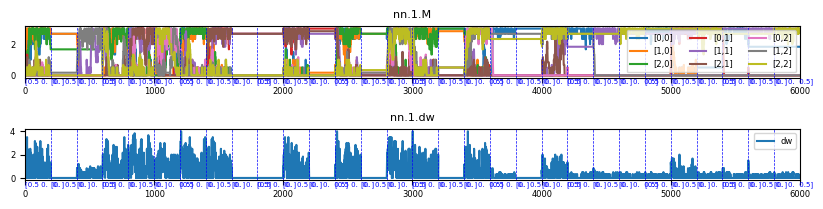

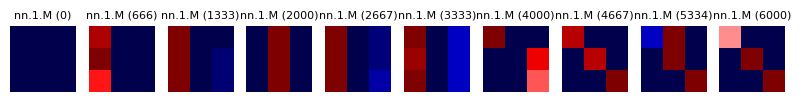

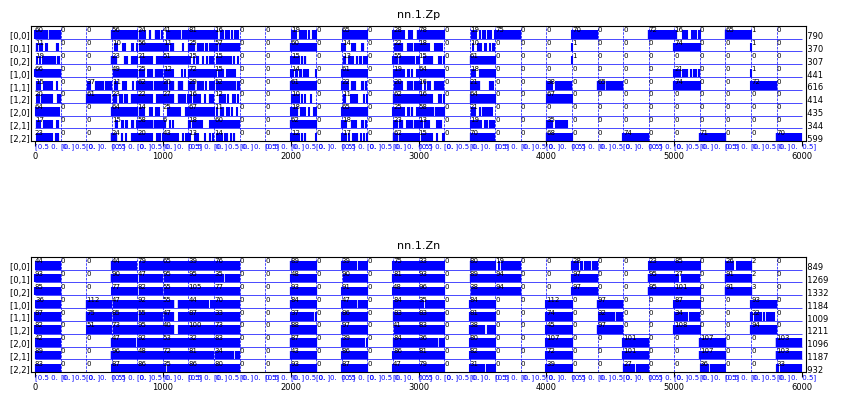

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x24425dd3940>,
 'context': <spikeml.core.run.Context at 0x24425dd1930>}

In [117]:
print(SSNNParams().fmt())
params_3_3 = SSNNParams(g=1,  e_err=2, t_p=2, t_d=3, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_3_3.fmt())

ss_0_1_2 = signal_pulse(3, T=200, L=10, s=[0,1,2], value=.5)
#ss_0_1_2_= signal_pulse(3, T=100, L=1, s=[0,1,2,-1], value=.5)
#ss_0__1__2__= signal_pulse(3, T=100, L=1, s=[0,-1,1,-1,2,-1], value=.5)

SIZE_3_3=[3,3]
options = None
#options = {'log.matrix': False, 'log.err': False}
result = test_run_ssnn(size=SIZE_3_3, ss=ss_0_1_2, params=params_3_3, log_step=0, options=options)
result

run: 1/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000020BAE1FE4D0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000020BC30633A0>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000020BAE1FC580>, 'context': Context(t=5999)}
run: 2/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000020BAE1FC4F0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000020BD32937C0>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000020BD3293580>, 'context': Context(t=5999)}
run: 3/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000020BAE1FDD50>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000020BAE1FD2A0>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000020BAE1FC4C0>, 'context': Context(t=5999)}
run: 4/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000020BAE1FDE10>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000020BAE1FE3E0

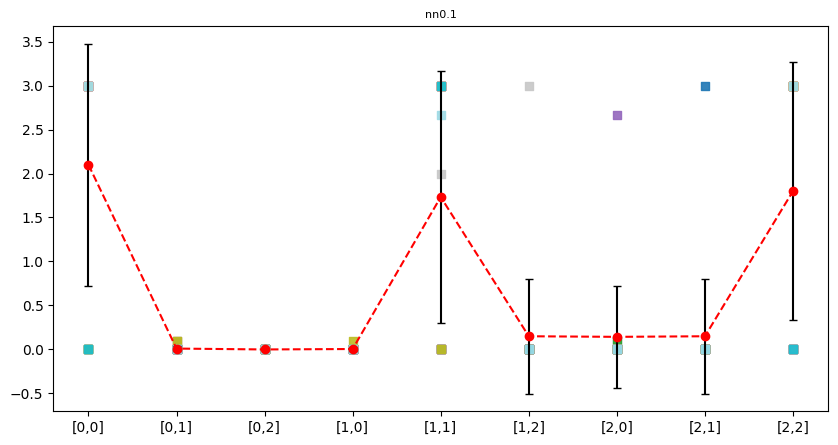

nn0.1: [0,0] x [1,0]]
  c1: [0. 0. 3. 3. 0. 3. 3. 3. 3. 3. 0. 3. 3. 3. 3. 3. 0. 3. 0. 3.]
  c2: [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0. ]
  test: Mann-Whitney U test
  statistic: 337.0
  p-value: 1.2339664234418895e-05
  reject_H0: True
nn0.1: [0,0] x [2,0]]
  c1: [0. 0. 3. 3. 0. 3. 3. 3. 3. 3. 0. 3. 3. 3. 3. 3. 0. 3. 0. 3.]
  c2: [0.     0.1    0.     0.     0.1    0.     0.     0.     2.6667 0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.    ]
  test: Mann-Whitney U test
  statistic: 331.0
  p-value: 5.5829466800925005e-05
  reject_H0: True
nn0.1: [1,1] x [0,1]]
  c1: [3.     0.     3.     3.     0.     3.     3.     3.     0.     3.     0.     0.     3.     0.     0.     2.     0.
 3.     3.     2.6667]
  c2: [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.1 0.  0.  0. ]
  test: Mann-Whitney U test
  statistic: 312.0
  p-value: 0.000344775222158414
  reject_H0: True
nn0.1: [1,1] x [2,1]]
  c1: [3.     0

In [ ]:
results_3_3 = test_nrun_ssnn(runs=20, size=SIZE_3_3, ss=ss_0_1_2, params=params_3_3, log_runs=1, log_step=-1, options=options)
plot_stats(results_3_3)
htest_connector_identity(results_3_3)    
results_3_3.log_monitor()

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=4.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=1.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x0000024412B406A0> :
  nn.s <spikeml.core.snn.SSensor object at 0x0000024428A12020> : (3,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x0000024412B40FD0> : (3, 3) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x0000024412B435E0> : (3, 3)
t= 0:
nn.s: sx=[0.15 0.15 0.  ]; s=[0.15 0.15 0.  ]  -> zs=[1 0 0]
nn.1: s=[0.15 0.15 0.  ] | zs=[1 0 0] -> y=[0.03 0.03 0.03] | zy=[0 0 0]


----------
t= 4000:
nn.s: sx=[0.  0.  0.3]; s=[0.  0.  0.3]  -> zs=[0 0 1]
nn.1: s=[0.  0.  0.3] | zs=[0 0 1] -> y=[0. 0. 0.] | zy=[0 0 0]


----------
nn:
   mean_error: 0.1817
   0: [0.15 0.15 0.  ] (#2000): Err: 0.2963
   1: [0.  0.  0.3] (#2000): Err: 0.0672
   0: [0.15 0.15 0.  ] ([(0, 99), (200, 299), (400, 499), (600, 699), (800, 899), (1000, 1099), (1200, 1299), (1400, 1499), (1600, 1699), (1800, 1899), (2000, 2099), (2200, 2299), (2400, 2499), (2600, 2699), (2800, 2899), (3000, 3099), (3200, 3299), (3400, 3499), (3600, 3699), (3800, 3899)]): Err: 0.2963
   1: [0.  0.  0.3] ([(100, 199), (300, 399), (500, 599), (700, 799), (900, 999), (1100, 1199), (1300, 1399), (1500, 1599), (1700, 1799), (1900, 1999), (2100, 2199), (2300, 2399), (2500, 2599), (2700, 2799), (2900, 2999), (3100, 3199), (3300, 3399), (3500, 3599), (3700, 3799), (3900, 3999)]): Err: 0.0672
nn.s.zs:
  0: [0.15 0.15 0.  ] (#2000); N:[782, 781, 1] ([0.50, 0.50, 0.00];[0.73, 0.27, 0.00])
  1: [0.  0.  0.3] (#2001); N:[99, 104, 845] ([0.09, 0.10, 0.81];[0.00, 0.00, 1.00])
  0: [0.15 0.15 0.  ] ([(0, 99), (200, 299), (400, 499), (600, 699), (800, 899), (100

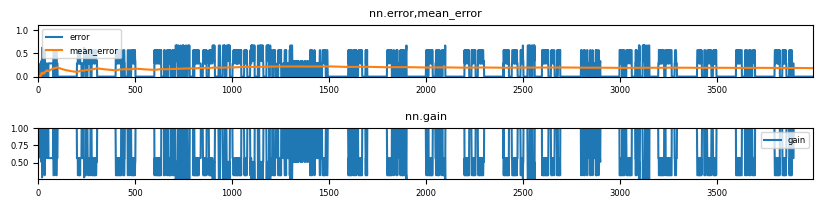

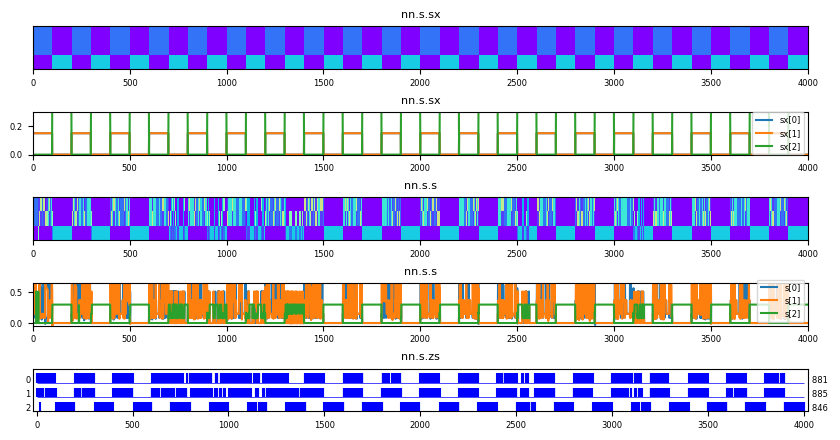

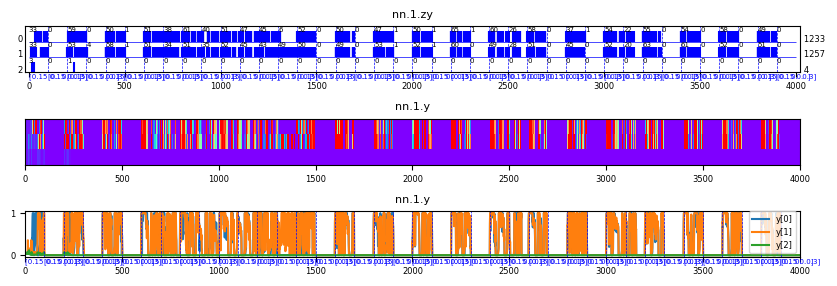

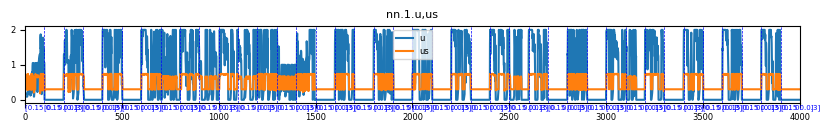

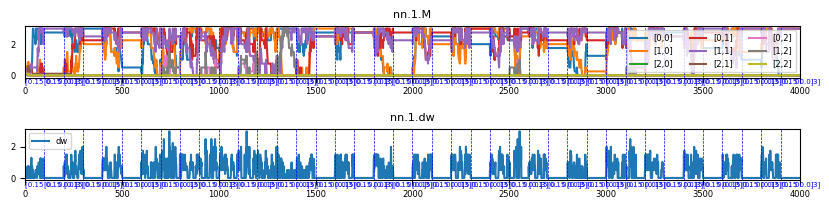

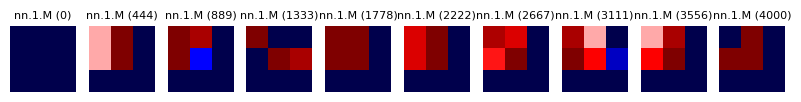

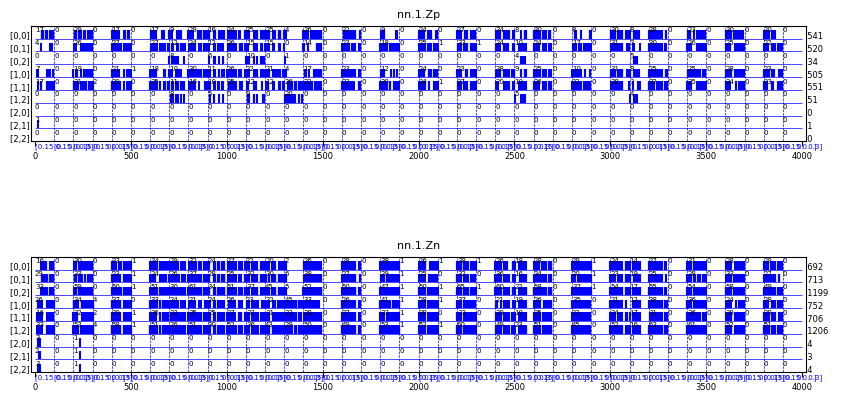

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x24425dd3fa0>,
 'context': <spikeml.core.run.Context at 0x24412e36a70>}

In [124]:
print(SSNNParams().fmt())
params_3_3 = SSNNParams(g=1,  e_err=2, t_p=2, t_d=4, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_3_3.fmt())
sa=.3
s0 = np.array([sa/2, sa/2, 0])
ss_01_2 = signal_pulse(3, T=100, L=20, s=[s0,2], value=sa)
#ss_0_1_2_= signal_pulse(3, T=100, L=1, s=[0,1,2,-1], value=.5)
#ss_0__1__2__= signal_pulse(3, T=100, L=1, s=[0,-1,1,-1,2,-1], value=.5)

SIZE_3_3=[3,3]
options = None
#options = {'log.matrix': False, 'log.err': False}
result_3_3 = test_run_ssnn(size=SIZE_3_3, ss=ss_01_2, params=params_3_3, log_step=0, options=options)
result_3_3

## SNN/RC Chain Fixed Pattern Detection: 
### `[110|001]*->|SS:3|SSNN/L:3x2|SSNN/RC:2x3|<`

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2.0,k_n=2.0,t_cp=30.0,t_cn=30.0,t_p=1.0,t_d=10.0,c_in=0.0,c_out=0.0,cmin=0.01,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
SSensorParams:t_b=40.0,e_b=2.0,g=2.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1.0,pmax=0.8,upsample_method=UpsampleMethod.REPEAT
nn <spikeml.core.base.Chain object at 0x0000021849046710> :
  s <spikeml.core.snn.SSensor object at 0x00000218490468C0> : (3,) OK OK
  sAB <spikeml.core.snn.SSNN object at 0x0000021849047520> : (2, 3) OK OK
  nn.0 <spikeml.core.snn.SSNN object at 0x0000021849046860> : (3, 2) OK OK
    nn.0 <spikeml.core.snn.LIConnector object at 0x0000021849046890> : (3, 2)
----------
t= 0:
s: sx=[0.4 0.4 0. ]; s=[0.4 0.4 0. ]  -> zs=[1 1 0]
sAB: s=[0.4 0.4 0. ] | zs=[1 1 0] -> y=[0.24 0.  ] | zy=[0 0]


0.300,0.300,0.000
0.000,0.000,0.450


nn.0: s=[0.24 0.  ] | zs=[0 0] -> y=[0.024 0.024 0.024] | zy=[0 0 0]


----------
t= 8000:
s: sx=[0.  0.  0.4]; s=[0.     0.     0.3928]  -> zs=[0 0 1]
sAB: s=[0.     0.     0.3928] | zs=[0 0 1] -> y=[0.     0.1768] | zy=[0 1]


0.300,0.300,0.000
0.000,0.000,0.450


nn.0: s=[0.     0.1768] | zs=[0 1] -> y=[0.0018 0.0018 0.0018] | zy=[0 0 0]


----------
nn:
   mean_error: 0.0715
   0: [0.4 0.4 0. ] (#4000): Err: 0.0998
   1: [0.  0.  0.4] (#4000): Err: 0.0432
   0: [0.4 0.4 0. ] ([(0, 399), (800, 1199), (1600, 1999), (2400, 2799), (3200, 3599), (4000, 4399), (4800, 5199), (5600, 5999), (6400, 6799), (7200, 7599)]): Err: 0.0998
   1: [0.  0.  0.4] ([(400, 799), (1200, 1599), (2000, 2399), (2800, 3199), (3600, 3999), (4400, 4799), (5200, 5599), (6000, 6399), (6800, 7199), (7600, 7999)]): Err: 0.0432
s.zs:
  0: [0.4 0.4 0. ] (#4000); N:[2312, 1923, 19] ([0.54, 0.45, 0.00];[1.00, 0.00, 0.00])
  1: [0.  0.  0.4] (#4001); N:[388, 17, 2133] ([0.15, 0.01, 0.84];[0.00, 0.00, 1.00])
  0: [0.4 0.4 0. ] ([(0, 399), (800, 1199), (1600, 1999), (2400, 2799), (3200, 3599), (4000, 4399), (4800, 5199), (5600, 5999), (6400, 6799), (7200, 7599)]); N:[[237, 231, 3], [237, 214, 1], [227, 179, 1], [241, 182, 3], [230, 186, 2], [224, 181, 1], [224, 187, 1], [214, 189, 2], [247, 185, 2], [231, 189, 3]] ([[0.50, 0.49, 0.01], [0.52, 0.47, 0.00], [0.5

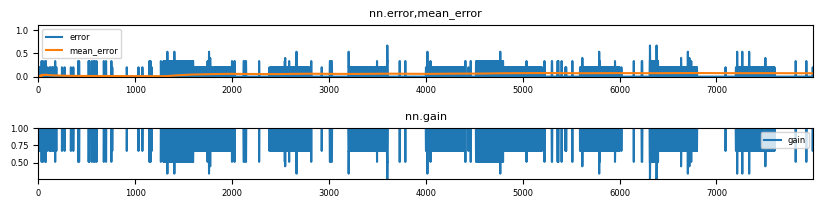

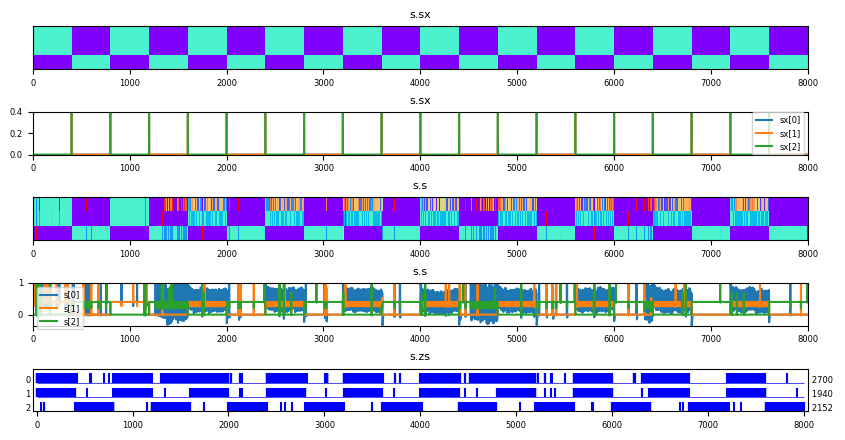

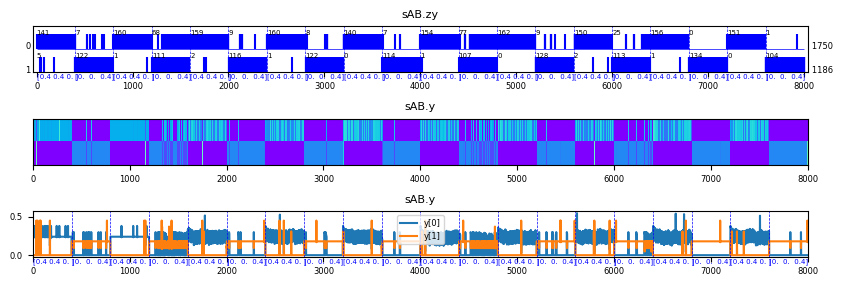

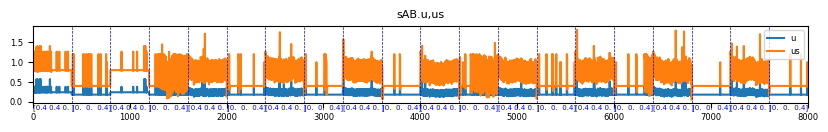

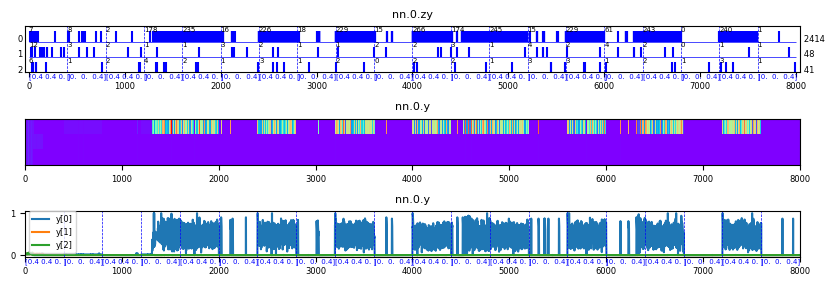

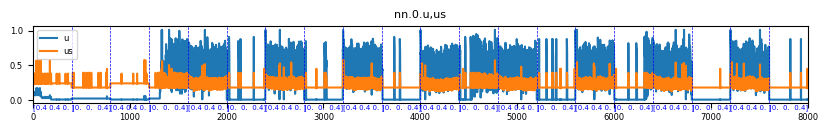

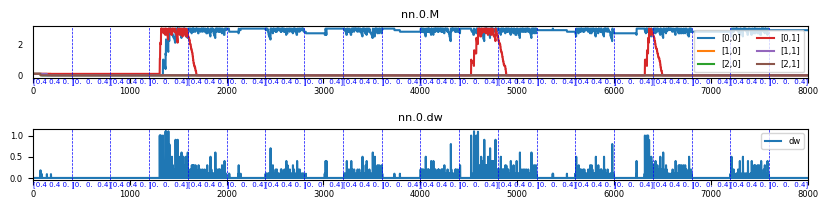

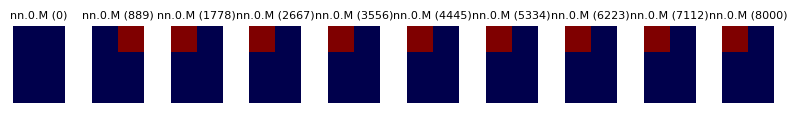

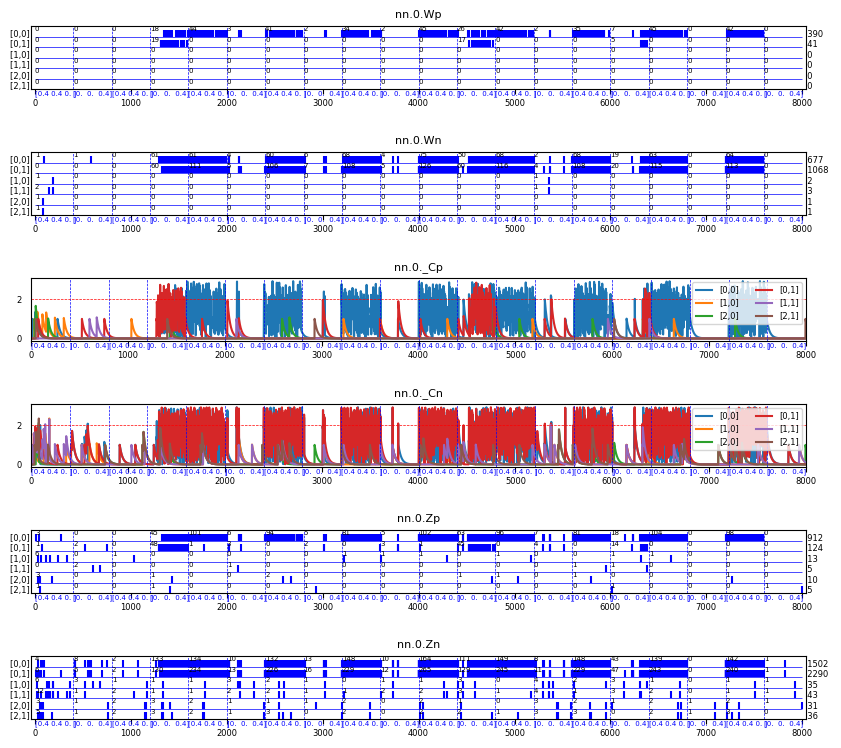

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x218490465c0>,
 'context': <spikeml.core.run.Context at 0x21849046590>}

In [ ]:
from spikeml.core.snn import Layer, SimpleLayer, LinearLayer, SNN, SSNN, SSensor, DSSNN, Connector, LinearConnector, RateConnector, RConnector, LIConnector2
from spikeml.core.chain import make_snn_chain, make_ssnn_chain, chain_validate, make_snn_echain, make_ssnn_echain
from spikeml.core.snn import ssnn_apply_update
from spikeml.core.feedback import compute_error, xcompute_error, compute_sg, FeedbackAdapter
from spikeml.core.runner import run, nrun, Context, run_with, run_with_feedback

def run_ssnn_2x3_lp(T=100, L=2, plot=True, log_step=0, options=None):
    print(SSNNParams().fmt())
    params = SSNNParams(g=2,  e_err=2, t_p=1, t_d=10, mean=0.1, sd=0, t_cp=30, t_cn=30,
                        t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, k_p=2, k_n=2, cmax=3, cmin=0.01, c_in=0, c_out= 0) #-1.5
    print(params.fmt())
    _params = params.model_dump()
    _params.update({'t_b': 40})
    sensor_params = SSensorParams.model_validate(_params)        
    print(sensor_params.fmt())
    
    sa=.4
    s0 = np.array([sa, sa, 0])
    ss_01_2 = signal_pulse(3, T=T, L=L, s=[s0,2], value=sa)
    #ss_01__2_ = signal_pulse(3, T=T, L=L, s=[s0,-1,2,-1], value=sa)

    ca= .3
    M_AB_3_2 = np.array([[ca,ca,0],[0,0,ca*1.5]])
    nn = make_ssnn_chain(size=[(3,2)], auto_sensor=False, params=params)
    nn.preappend([
        SSensor(name='s', n=3, params=sensor_params),
        SSNN(M_AB_3_2, name='sAB', params=params)
    ])

    chain_validate(nn)
    #nn.log()
    print('-'*10)
    result = run_with_feedback(nn, source=ss_01_2, params=params, plot=plot, log_step=log_step, options=options)
    return result

#options = {'log.matrix': False, 'log.err': False}    
result_2_2_p = run_ssnn_2x3_lp(T=400, L=10)
result_2_2_p

In [39]:
M = result_2_2_p['ref'].ref.refs[2].M
Zp= np.array(M.monitor.Zp)
Zn= np.array(M.monitor.Zn)
print(Zp[2000:2100,1,0])
print(Zn[2000:2100,1,0])
     

[0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1]
[1 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0]


## Chain Input Pattern; No Feedback: [110|001]*->|SSNN/RC:3xN|

SSNNParams:c_k=2,t_c=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1,t_b=20,e_b=2
SSNNParams:c_k=2,t_c=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=-3.0,cmax=3.0,mean=0.0,sd=0.05,g=1.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8,t_b=20.0,e_b=2
nn <spikeml.core.base.Chain object at 0x000001EABBAAB310> :
  nn.s <spikeml.core.snn.SSensor object at 0x000001EABBAA9120> : (3,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x000001EABBAA8040> : (5, 3) OK OK
t= 0:
nn.s: sx=[0.8 0.8 0. ]; s=[0.8 0.8 0. ]  -> zs=[1 0 0]
nn.1: s=[0.8 0.8 0. ] | zs=[1 0 0] -> y=[0.0468 0.023  0.     0.     0.0283] | zy=[0 0 0 0 0]


----------
nn.s.zs:
  0: [0.8 0.8 0. ] (#1000); N:[804, 792, 0] ([0.50, 0.50, 0.00];[1.00, 0.00, 0.00])
  1: [0.  0.  0.8] (#1001); N:[0, 0, 811] ([0.00, 0.00, 1.00];[0.00, 0.00, 1.00])
  0: [0.8 0.8 0. ] ([(0, 99), (200, 299), (400, 499), (600, 699), (800, 899), (1000, 1099), (1200, 1299), (1400, 1499), (1600, 1699), (1800, 1899)]); N:[[83, 79, 0], [80, 77, 0], [82, 79, 0], [77, 78, 0], [81, 85, 0], [81, 75, 0], [79, 79, 0], [84, 74, 0], [84, 86, 0], [73, 80, 0]] ([[0.51, 0.49, 0.00], [0.51, 0.49, 0.00], [0.51, 0.49, 0.00], [0.50, 0.50, 0.00], [0.49, 0.51, 0.00], [0.52, 0.48, 0.00], [0.50, 0.50, 0.00], [0.53, 0.47, 0.00], [0.49, 0.51, 0.00], [0.48, 0.52, 0.00]];[[0.98, 0.02, 0.00], [0.95, 0.05, 0.00], [0.95, 0.05, 0.00], [0.27, 0.73, 0.00], [0.02, 0.98, 0.00], [1.00, 0.00, 0.00], [0.50, 0.50, 0.00], [1.00, 0.00, 0.00], [0.12, 0.88, 0.00], [0.00, 1.00, 0.00]])
  1: [0.  0.  0.8] ([(100, 199), (300, 399), (500, 599), (700, 799), (900, 999), (1100, 1199), (1300, 1399), (1500, 1599), (170

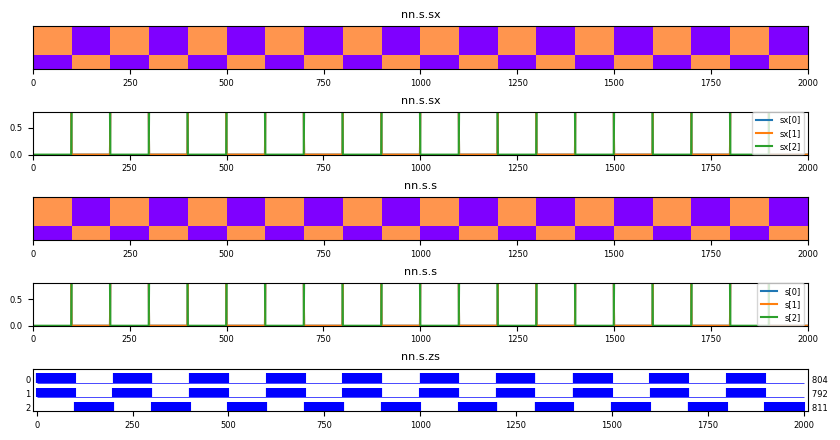

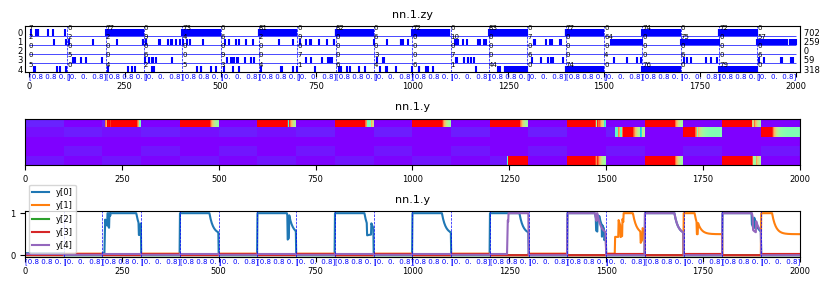

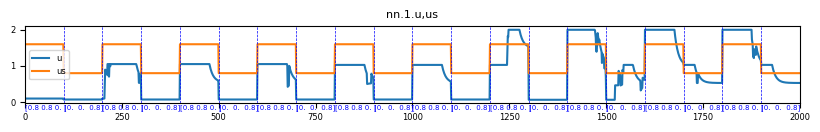

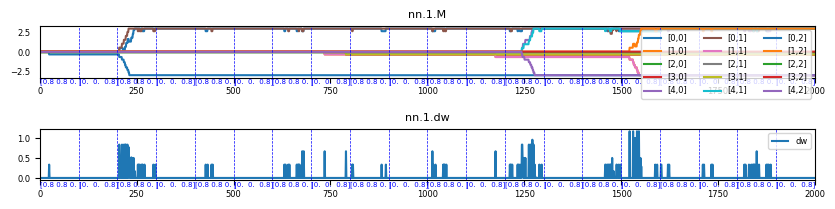

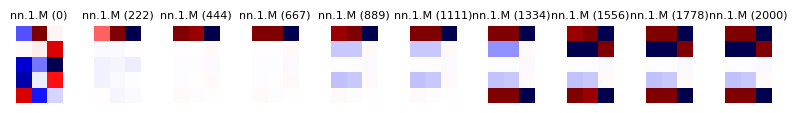

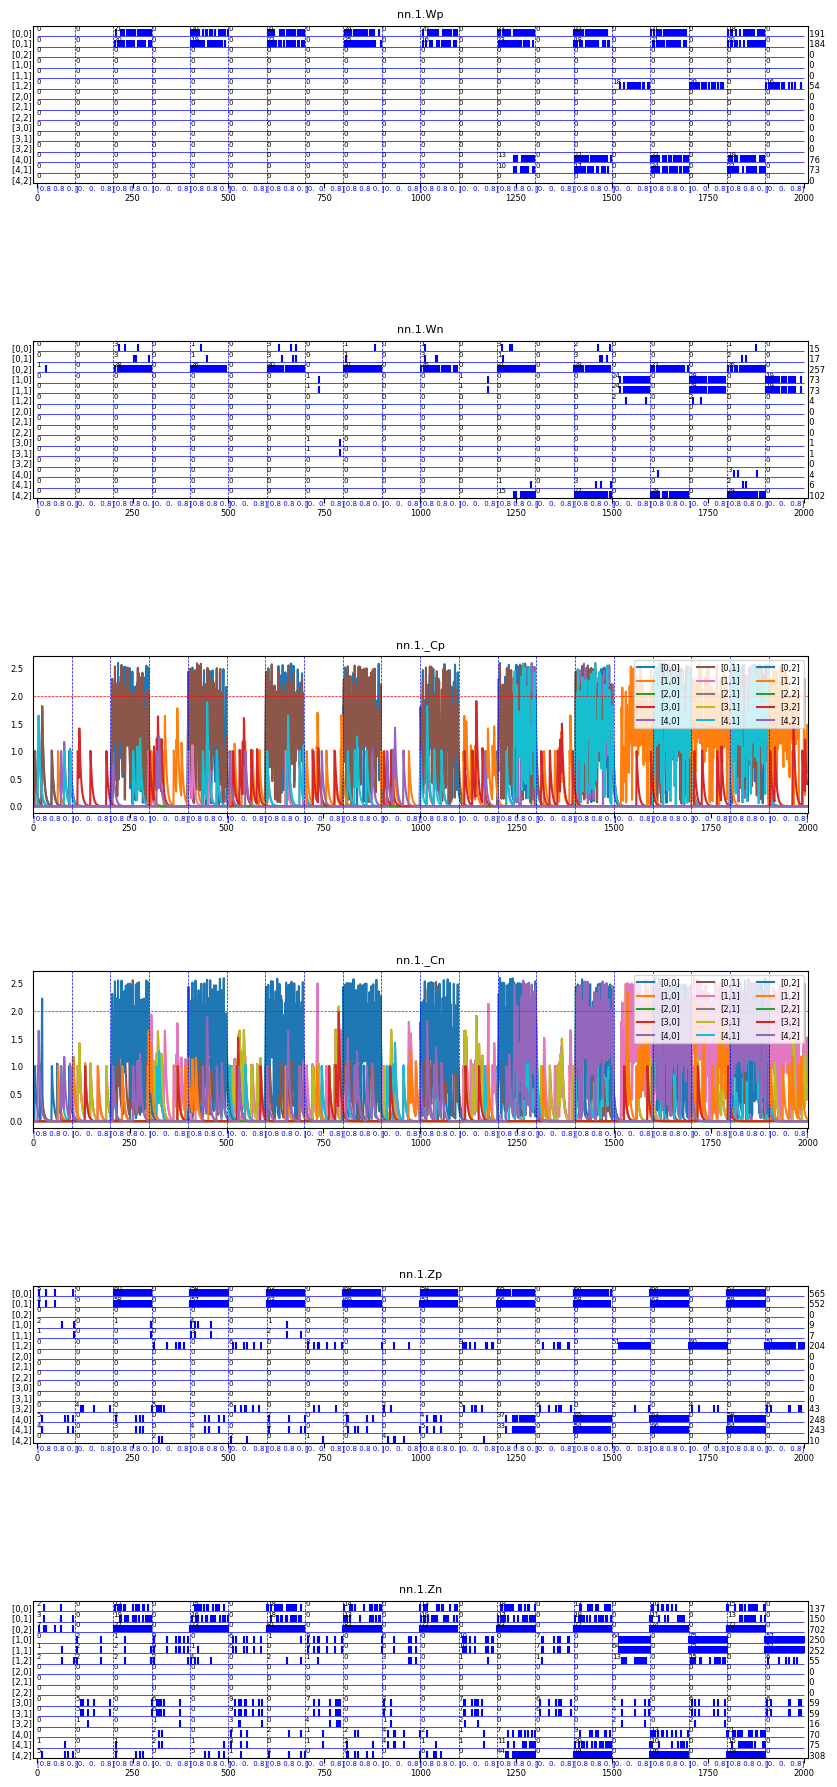

In [21]:
print(SSNNParams().fmt())
params_3_3b = SSNNParams(g=1, e_err=2, t_p=2, t_d=3, mean=0, sd=.05, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=-3, c_in=0, c_out= 0) #-1.5
print(params_3_3b.fmt())

sa=.8
s0 = np.array([sa, sa, 0])
ss_01_2 = signal_pulse(3, T=100, L=10, s=[s0,2], value=sa)
ss_01__2_ = signal_pulse(3, T=200, L=10, s=[s0,-1,2,-1], value=sa)

SIZE_3_3=[3,3]
N=5
SIZE_3_N=[3,N]
options = None
#options = {'log.matrix': False, 'log.err': False}
result_3_3b = test_run_ssnn(size=SIZE_3_N, ss=ss_01_2, params=params_3_3b, feedback=False, log_step=0, options=options)
result_3_3b


In [81]:
result_3_3b['nn'].auto_sample
print(len(result_3_3b['nn'].refs[0].monitor.sx))

200


## Chain - SSNN: 3x3x3 - Input Pattern

In [7]:
#size(s)=3 ;no feedback
#print(SSNNParams())
params = SSNNParams(g=2, pmax=.7, e_err=2, t_p=1, t_d=3,
                    t_b=0, t_tdp=10, e_z=3, vmin=0, vmax=1, cmax=1.5
                    , cmin=0, c_in=2, c_out= 3)
print(params)

s0 = np.array([1, 1, 0])
ss = signal_pulse(3, T=400, L=1, s=[s0,-1,2,-1], value=.3)
result = test_run_ssnn(ss=ss, params=params, mean=(.2,.1), sd=0, feedback=False, log_step=-1, debug=True)
result

SSNNParams({'k_p': 2, 'k_n': 2, 't_cp': 10, 't_cn': 10, 't_p': 1.0, 't_d': 3.0, 'c_in': 2.0, 'c_out': 3.0, 'cmin': 0.0, 'cmax': 1.5, 'mean': 0, 'sd': 0.1, 'size': None, 't_b': 0.0, 'e_b': 2, 'g': 2.0, 'e_err': 2.0, 'vmin': 0.0, 'vmax': 1.0, 'name': None, 'e_z': 3.0, 'pf': 1, 'pmax': 0.7})


TypeError: test_run_ssnn() got an unexpected keyword argument 'mean'

## Chain - SSNN: 5x5

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=1.0,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x000002446D9A1240> :
  nn.s <spikeml.core.snn.SSensor object at 0x000002440EF269B0> : (5,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x000002440EF26D70> : (5, 5) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x000002440EF26E00> : (5, 5)
t= 0:
nn.s: sx=[0.5 0.  0.  0.  0. ]; s=[0.5 0.  0.  0.  0. ]  -> zs=[1 0 0 0 0]
nn.1: s=[0.5 0.  0.  0.  0. ] | zs=[1 0 0 0 0] -> y=[0.05 0.05 0.05 0.05 0.05] | zy=[0 0 0 0 0]


----------
t= 5000:
nn.s: sx=[0.  0.  0.  0.  0.5]; s=[0.  0.  0.  0.  0.5]  -> zs=[0 0 0 0 0]
nn.1: s=[0.  0.  0.  0.  0.5] | zs=[0 0 0 0 0] -> y=[0. 0. 0. 0. 0.] | zy=[0 0 0 0 0]


----------
nn:
   mean_error: 0.1397
   0: [0.5 0.  0.  0.  0. ] (#1000): Err: 0.1923
   1: [0.  0.5 0.  0.  0. ] (#1000): Err: 0.0424
   2: [0.  0.  0.5 0.  0. ] (#1000): Err: 0.1979
   3: [0.  0.  0.  0.5 0. ] (#1000): Err: 0.2022
   4: [0.  0.  0.  0.  0.5] (#1000): Err: 0.0636
   0: [0.5 0.  0.  0.  0. ] ([(0, 99), (500, 599), (1000, 1099), (1500, 1599), (2000, 2099), (2500, 2599), (3000, 3099), (3500, 3599), (4000, 4099), (4500, 4599)]): Err: 0.1923
   1: [0.  0.5 0.  0.  0. ] ([(100, 199), (600, 699), (1100, 1199), (1600, 1699), (2100, 2199), (2600, 2699), (3100, 3199), (3600, 3699), (4100, 4199), (4600, 4699)]): Err: 0.0424
   2: [0.  0.  0.5 0.  0. ] ([(200, 299), (700, 799), (1200, 1299), (1700, 1799), (2200, 2299), (2700, 2799), (3200, 3299), (3700, 3799), (4200, 4299), (4700, 4799)]): Err: 0.1979
   3: [0.  0.  0.  0.5 0. ] ([(300, 399), (800, 899), (1300, 1399), (1800, 1899), (2300, 2399), (2800, 2899), (3300, 3399), (3800, 3899), (4300, 4399), (4800, 4899)]): Err: 0.2022
 

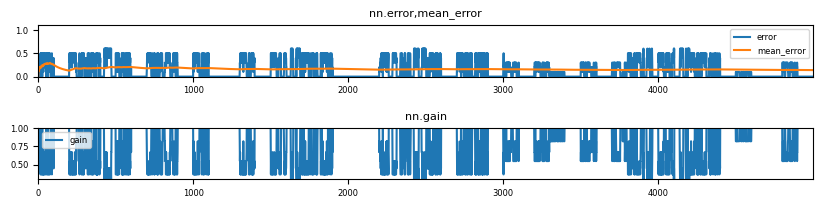

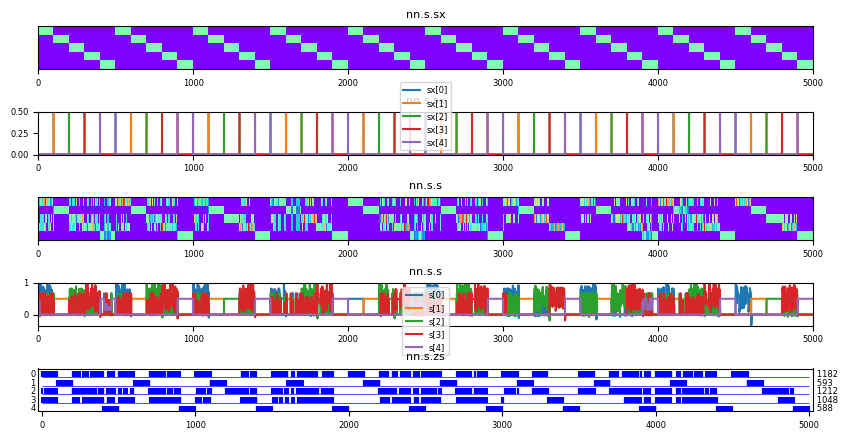

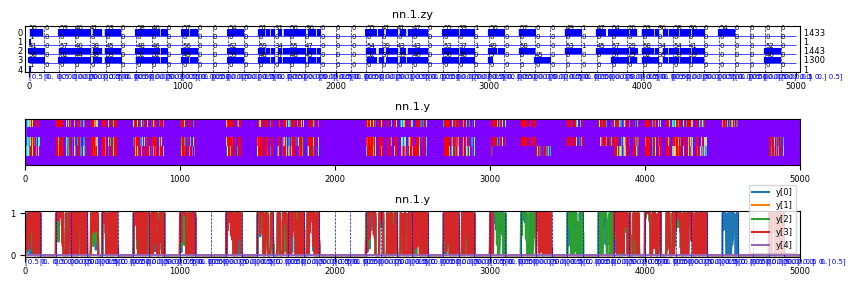

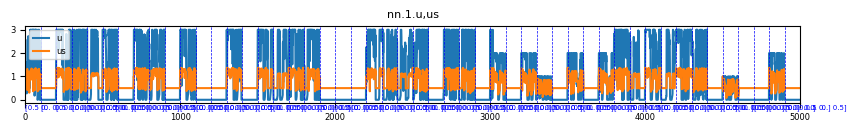

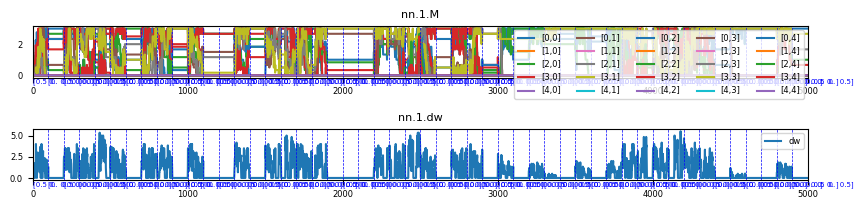

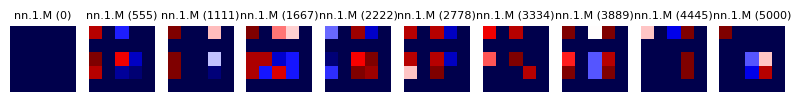

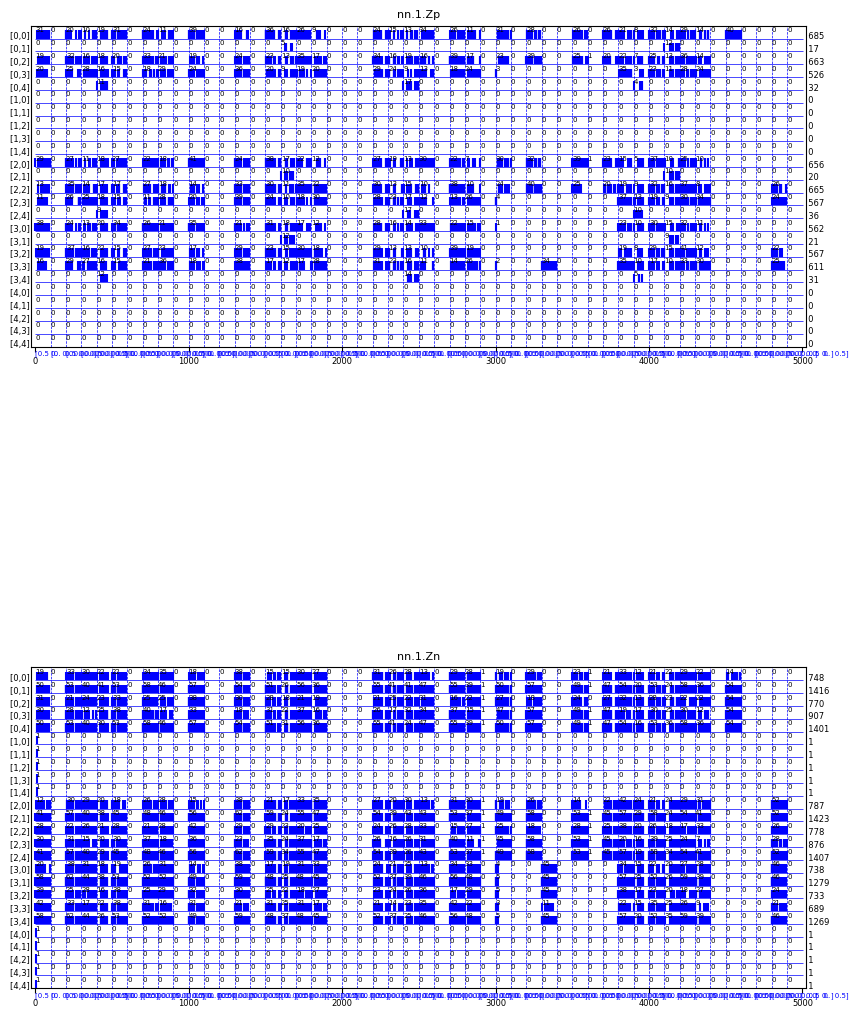

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x2440ef26800>,
 'context': <spikeml.core.run.Context at 0x2440c80b160>}

In [10]:
print(SSNNParams().fmt())
params_5_5 = SSNNParams(g=1,  e_err=2, t_p=2, t_d=3, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_5_5.fmt())

ss_0_5 = signal_pulse(5, T=100, L=10, s=[0,1,2,3,4], value=.5)
#ss_0_5_= signal_pulse(5, T=100, L=1, s=[0,1,2,3,4,-1], value=.5)
#ss_0__5= signal_pulse(5, T=100, L=1, s=[0,-1,1,-1,2,-1,3,-1,4], value=.5)

SIZE_5_5=[5,5]
options = None
#options = {'log.matrix': False, 'log.err': False}
result = test_run_ssnn(size=SIZE_5_5, ss=ss_0_5, params=params_5_5, log_step=0, options=options)
result

run: 1/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D6FAC96C0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D6FAC8B50>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D6FACB070>, 'context': Context(t=4999)}
run: 2/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D6FAC88E0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D4A97A860>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D6FAC89D0>, 'context': Context(t=4999)}
run: 3/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D6FACB820>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D6FAC8250>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D6FACBC70>, 'context': Context(t=4999)}
run: 4/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D6FAC8520>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D6FACAF20

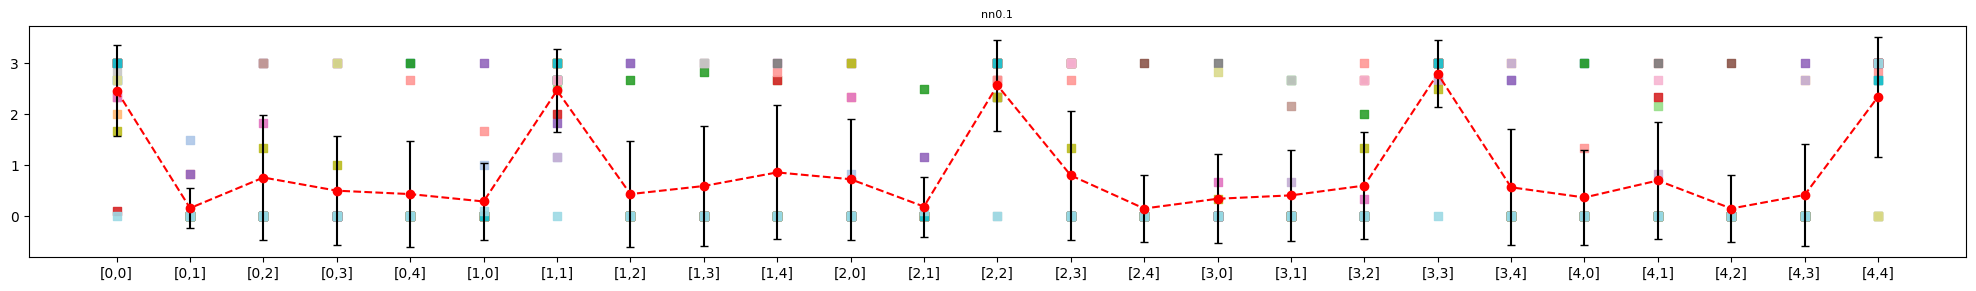

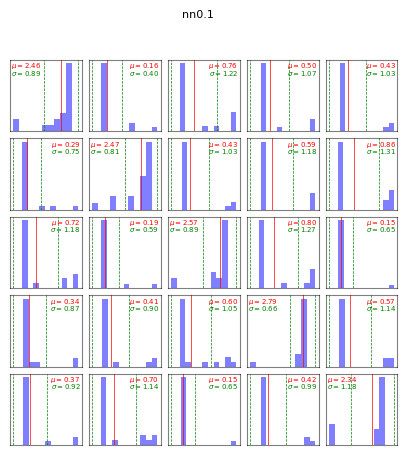

nn0.1: [0,0] x [1,0]]
  c1: [2.6667 2.6667 3.     2.     3.     3.     0.1    2.3333 3.     3.     3.     3.     2.3333 3.     3.     2.8333 1.6667
 2.6667 3.     0.    ]
  c2: [0.     1.     0.     0.     0.     0.     0.     1.6667 3.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.1   ]
  test: Mann-Whitney U test
  statistic: 370.0
  p-value: 1.490676671299268e-06
  reject_H0: True
nn0.1: [0,0] x [2,0]]
  c1: [2.6667 2.6667 3.     2.     3.     3.     0.1    2.3333 3.     3.     3.     3.     2.3333 3.     3.     2.8333 1.6667
 2.6667 3.     0.    ]
  c2: [0.     0.8333 0.     2.3333 0.     0.     0.     0.     3.     0.     0.     3.     2.3333 0.     0.     0.     3.
 0.     0.     0.    ]
  test: Mann-Whitney U test
  statistic: 334.5
  p-value: 0.00015693365732705146
  reject_H0: True
nn0.1: [0,0] x [3,0]]
  c1: [2.6667 2.6667 3.     2.     3.     3.     0.1    2.3333 3.     3.     3.     3.     2.3333 3.     3.     2.8333 1.6667
 2.6667 3.     0.    ]


In [73]:
results_5_5 = test_nrun_ssnn(runs=20, size=SIZE_5_5, ss=ss_0_5, params=params_5_5, log_runs=1, log_step=-1, options=options)
plot_snn_stats(results_5_5)
htest_connector_identity(results_5_5)    
results_5_5.log_monitor()

## Chain - SSNN: 7x7

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=0.5,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x000002440C7AC310> :
  nn.s <spikeml.core.snn.SSensor object at 0x0000024412EBAC50> : (7,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x0000024412EDEE00> : (7, 7) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x0000024412EB99C0> : (7, 7)
t= 0:
nn.s: sx=[0.5 0.  0.  0.  0.  0.  0. ]; s=[0.5 0.  0.  0.  0.  0.  0. ]  -> zs=[1 0 0 0 0 0 0]
nn.1: s=[0.5 0.  0.  0.  0.  0.  0. ] | zs=[1 0 0 0 0 0 0] -> y=[0.05 0.05 0.05 0.05 0.05 0.05 0.05] | zy=[0 0 0 0 0 0 0]


----------
t= 14000:
nn.s: sx=[0.  0.  0.  0.  0.  0.  0.5]; s=[0.  0.  0.  0.  0.  0.  0.5]  -> zs=[0 0 0 0 0 0 1]
nn.1: s=[0.  0.  0.  0.  0.  0.  0.5] | zs=[0 0 0 0 0 0 1] -> y=[0. 0. 0. 0. 0. 0. 0.] | zy=[0 0 0 0 0 0 0]


----------
nn:
   mean_error: 0.0731
   0: [0.5 0.  0.  0.  0.  0.  0. ] (#2000): Err: 0.1291
   1: [0.  0.5 0.  0.  0.  0.  0. ] (#2000): Err: 0.0685
   2: [0.  0.  0.5 0.  0.  0.  0. ] (#2000): Err: 0.1129
   3: [0.  0.  0.  0.5 0.  0.  0. ] (#2000): Err: 0.0039
   4: [0.  0.  0.  0.  0.5 0.  0. ] (#2000): Err: 0.0384
   5: [0.  0.  0.  0.  0.  0.5 0. ] (#2000): Err: 0.0852
   6: [0.  0.  0.  0.  0.  0.  0.5] (#2000): Err: 0.0739
   0: [0.5 0.  0.  0.  0.  0.  0. ] ([(0, 99), (700, 799), (1400, 1499), (2100, 2199), (2800, 2899), (3500, 3599), (4200, 4299), (4900, 4999), (5600, 5699), (6300, 6399), (7000, 7099), (7700, 7799), (8400, 8499), (9100, 9199), (9800, 9899), (10500, 10599), (11200, 11299), (11900, 11999), (12600, 12699), (13300, 13399)]): Err: 0.1291
   1: [0.  0.5 0.  0.  0.  0.  0. ] ([(100, 199), (800, 899), (1500, 1599), (2200, 2299), (2900, 2999), (3600, 3699), (4300, 4399), (5000, 5099), (5700, 5799), (6400, 6499), (7100, 7199), (7800, 7899), (8500, 8599), (9200, 9299),

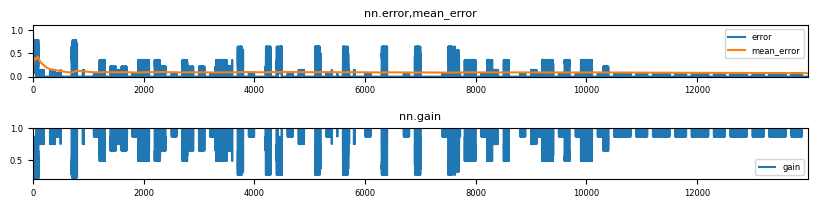

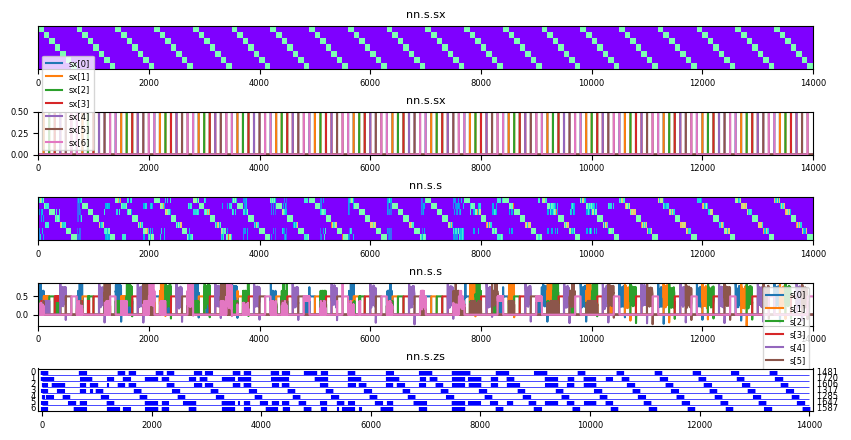

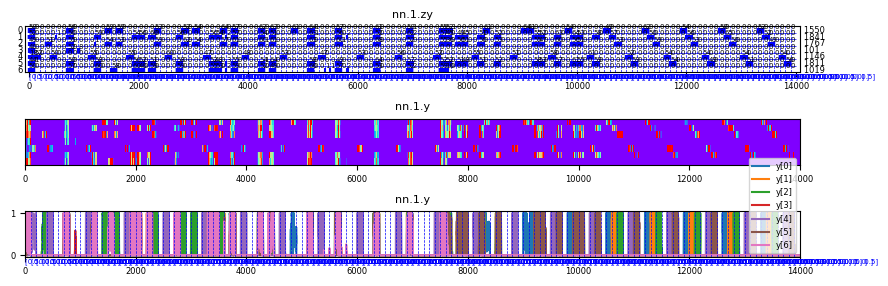

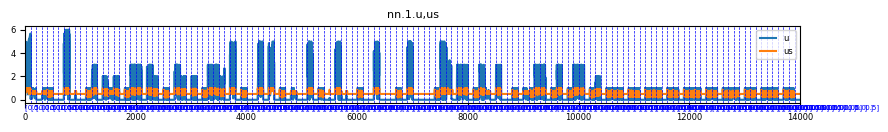

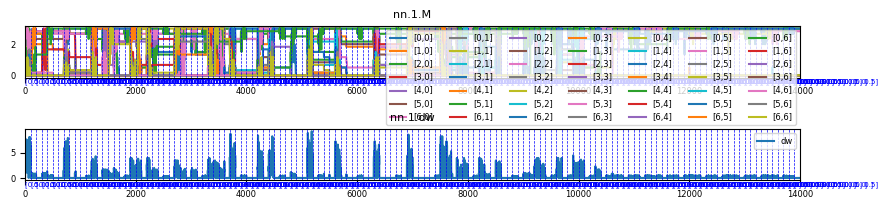

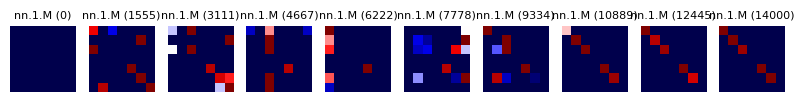

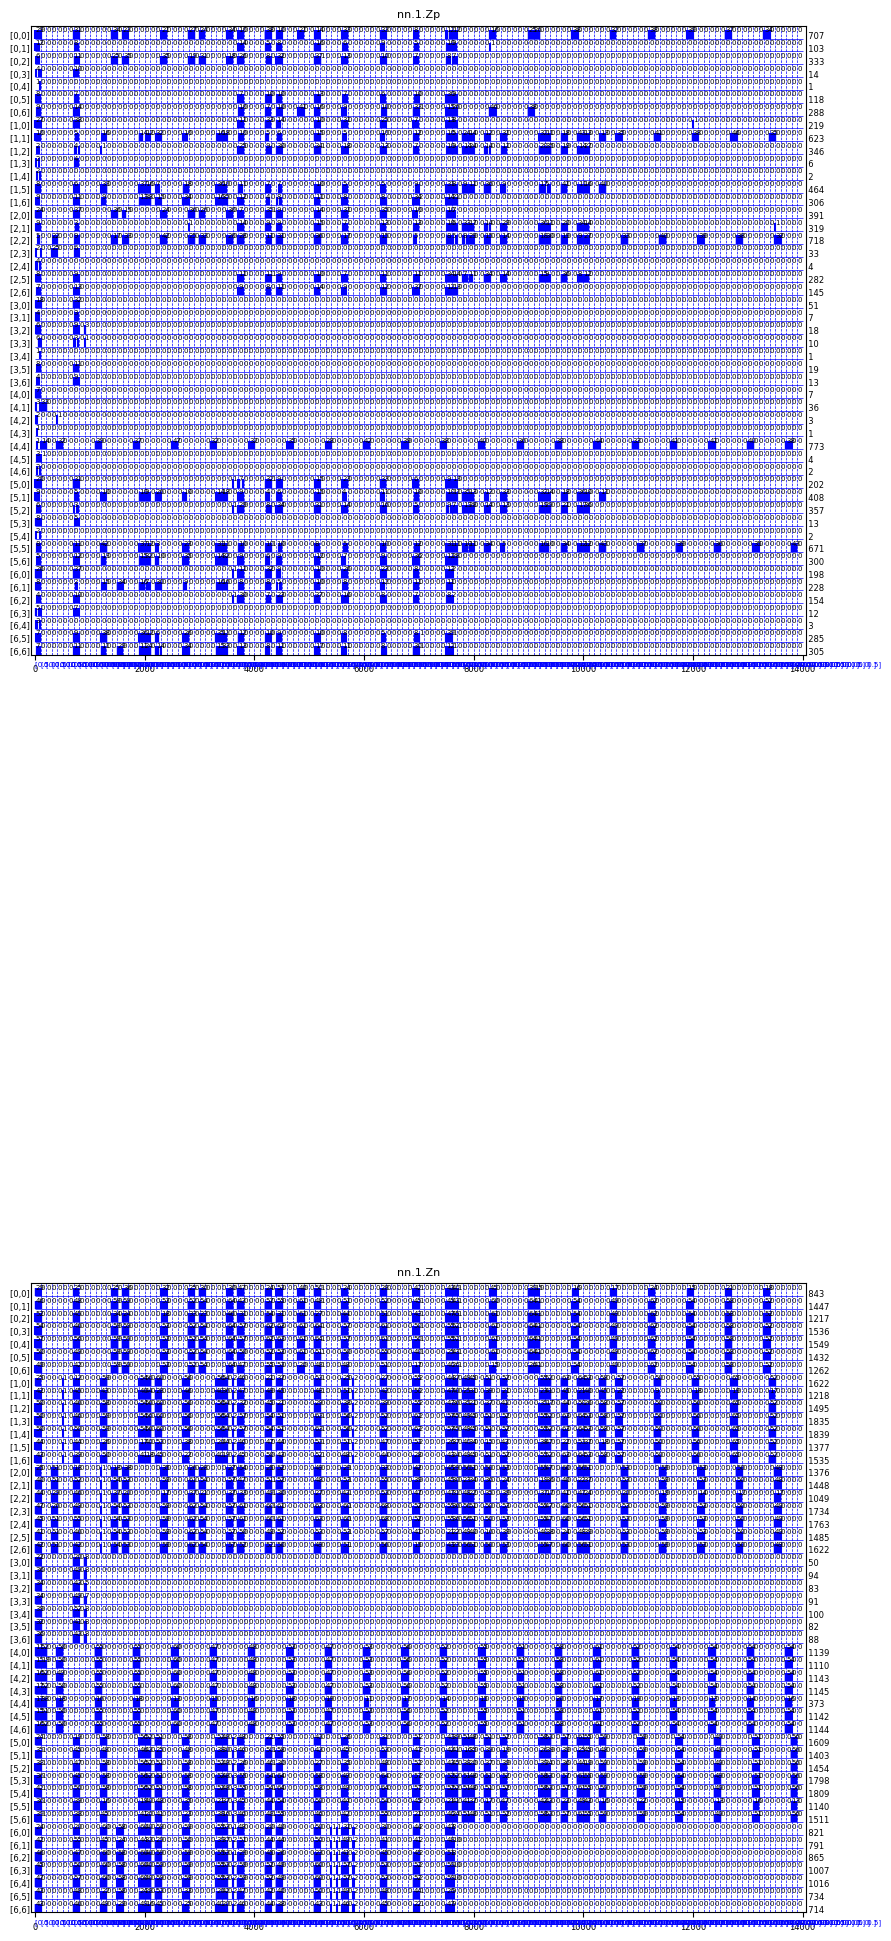

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x24412ebb640>,
 'context': <spikeml.core.run.Context at 0x244037b2e00>}

In [12]:
print(SSNNParams().fmt())
params_7_7 = SSNNParams(g=.5,  e_err=2, t_p=2, t_d=3, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params_7_7.fmt())

ss_0_6 = signal_pulse(7, T=100, L=20, s=[0,1,2,3,4,5,6], value=.5)
#ss_0_6_= signal_pulse(7, T=100, L=1, s=[0,1,2,3,4,5,6,-1], value=.5)
#ss_0__6= signal_pulse(7, T=100, L=1, s=[0,-1,1,-1,2,-1,3,-1,4,-1,5,-1,6,-1], value=.5)

SIZE_7_7=[7,7]
options = None
#options = {'log.matrix': False, 'log.err': False}
result_7_7 = test_run_ssnn(size=SIZE_7_7, ss=ss_0_6, params=params_7_7, log_step=0, options=options)
result_7_7

run: 1/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021DB7E18370>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D6FB05030>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021DB7E1A5C0>, 'context': Context(t=6999)}
run: 2/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D6FACB4F0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D52229120>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D4EDB1720>, 'context': Context(t=6999)}
run: 3/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021DBE028220>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D6FACB520>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D6FAC81C0>, 'context': Context(t=6999)}
run: 4/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021DBE028520>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021DB7ED1000

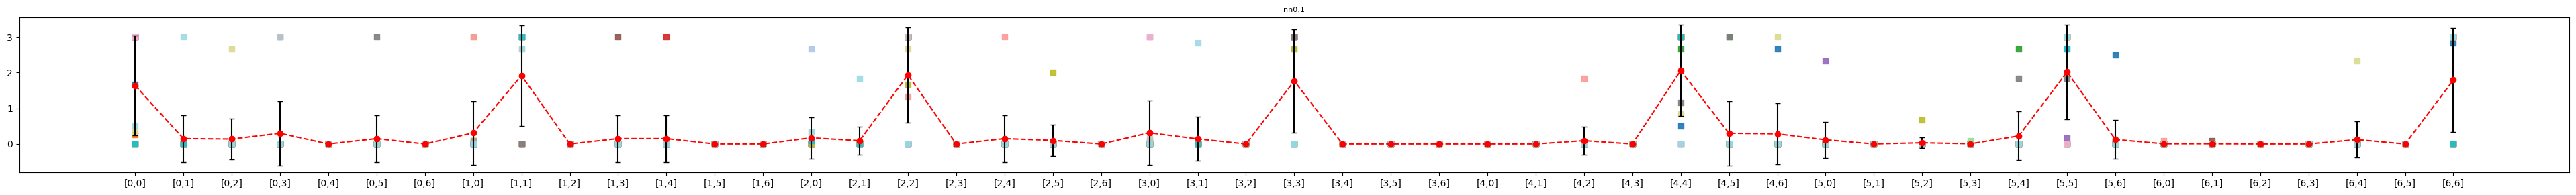

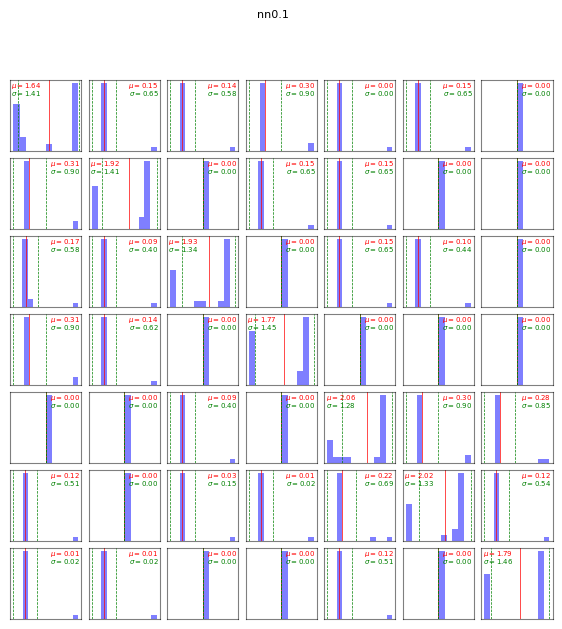

nn0.1: [0,0] x [1,0]]
  c1: [1.6667 3.     0.2667 3.     3.     3.     3.     0.     3.     3.     0.     3.     3.     3.     0.     0.     0.
 0.3333 0.     0.5   ]
  c2: [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e-01 3.0000e+00 0.0000e+00 3.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 1.0000e-01 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.1102e-16]
  test: Mann-Whitney U test
  statistic: 307.0
  p-value: 0.0015520309507714336
  reject_H0: True
nn0.1: [0,0] x [2,0]]
  c1: [1.6667 3.     0.2667 3.     3.     3.     3.     0.     3.     3.     0.     3.     3.     3.     0.     0.     0.
 0.3333 0.     0.5   ]
  c2: [0.     2.6667 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.3333 0.1    0.3333]
  test: Mann-Whitney U test
  statistic: 320.0
  p-value: 0.0003523687907249903
  reject_H0: True
nn0.1: [0,0] x [3,0]]
  c1: [1.6667 3.     0.2667 3.     3.     3.     3.     0.     3.     3.  

In [ ]:
results_7_7 = test_nrun_ssnn(runs=20, size=SIZE_7_7, ss=ss_0_6, params=params_7_7, log_runs=1, log_step=-1, options=options)
plot_snn_stats(results_7_7)
htest_connector_identity(results_7_7)    
results_7_7.log_monitor()

## Chain - SSNN: 9x9

SSNNParams:k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,t_b=20,e_b=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1
SSNNParams:k_p=2,k_n=2,t_cp=5.0,t_cn=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,t_b=20.0,e_b=2,g=0.5,e_err=2.0,vmin=0.0,vmax=1.0,e_z=2.0,pf=1,pmax=0.8
nn <spikeml.core.base.Chain object at 0x0000024421DB6440> :
  nn.s <spikeml.core.snn.SSensor object at 0x0000024421D07550> : (9,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x0000024421DB5F00> : (9, 9) OK OK
    nn.1 <spikeml.core.snn.RateConnector object at 0x0000024421D07430> : (9, 9)
t= 0:
nn.s: sx=[0.5 0.  0.  0.  0.  0.  0.  0.  0. ]; s=[0.5 0.  0.  0.  0.  0.  0.  0.  0. ]  -> zs=[1 0 0 0 0 0 0 0 0]
nn.1: s=[0.5 0.  0.  0.  0.  0.  0.  0.  0. ] | zs=[1 0 0 0 0 0 0 0 0] -> y=[0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05] | zy=[0 0 0 0 0 0 1 0 0]


----------
t= 9000:
nn.s: sx=[0.  0.  0.  0.  0.  0.  0.  0.  0.5]; s=[0.     0.     0.     0.     0.     0.     0.     0.     0.4091]  -> zs=[0 0 0 0 0 0 0 0 0]
nn.1: s=[0.     0.     0.     0.     0.     0.     0.     0.     0.4091] | zs=[0 0 0 0 0 0 0 0 0] -> y=[0.     0.     0.     0.     0.     0.     0.     0.2143 0.3396] | zy=[0 0 0 0 0 0 0 1 0]


----------
nn:
   mean_error: 0.0801
   0: [0.5 0.  0.  0.  0.  0.  0.  0.  0. ] (#1000): Err: 0.1052
   1: [0.  0.5 0.  0.  0.  0.  0.  0.  0. ] (#1000): Err: 0.1512
   2: [0.  0.  0.5 0.  0.  0.  0.  0.  0. ] (#1000): Err: 0.0000
   3: [0.  0.  0.  0.5 0.  0.  0.  0.  0. ] (#1000): Err: 0.0556
   4: [0.  0.  0.  0.  0.5 0.  0.  0.  0. ] (#1000): Err: 0.1090
   5: [0.  0.  0.  0.  0.  0.5 0.  0.  0. ] (#1000): Err: 0.0993
   6: [0.  0.  0.  0.  0.  0.  0.5 0.  0. ] (#1000): Err: 0.0605
   7: [0.  0.  0.  0.  0.  0.  0.  0.5 0. ] (#1000): Err: 0.0544
   8: [0.  0.  0.  0.  0.  0.  0.  0.  0.5] (#1000): Err: 0.0860
   0: [0.5 0.  0.  0.  0.  0.  0.  0.  0. ] ([(0, 99), (900, 999), (1800, 1899), (2700, 2799), (3600, 3699), (4500, 4599), (5400, 5499), (6300, 6399), (7200, 7299), (8100, 8199)]): Err: 0.1052
   1: [0.  0.5 0.  0.  0.  0.  0.  0.  0. ] ([(100, 199), (1000, 1099), (1900, 1999), (2800, 2899), (3700, 3799), (4600, 4699), (5500, 5599), (6400, 6499), (7300, 7399), (8200, 8299)]):

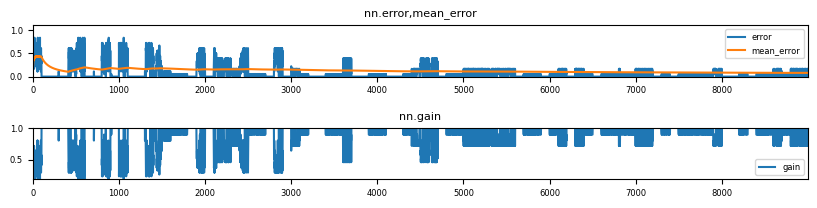

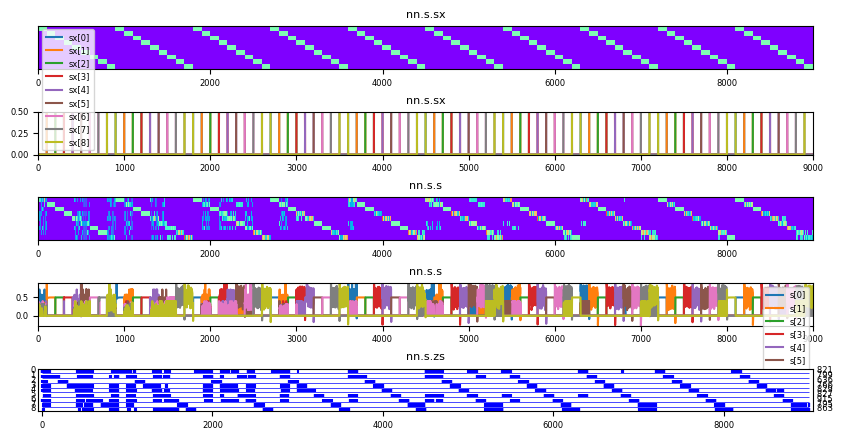

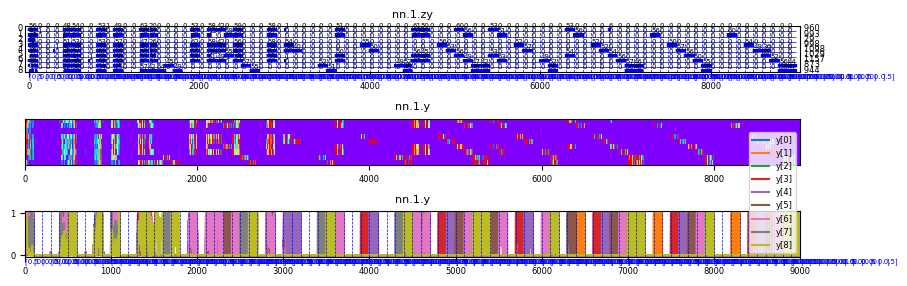

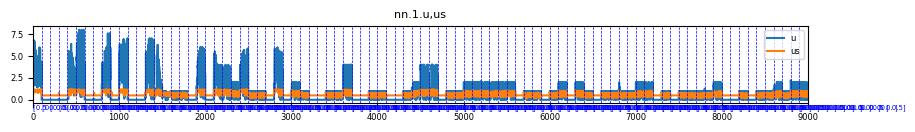

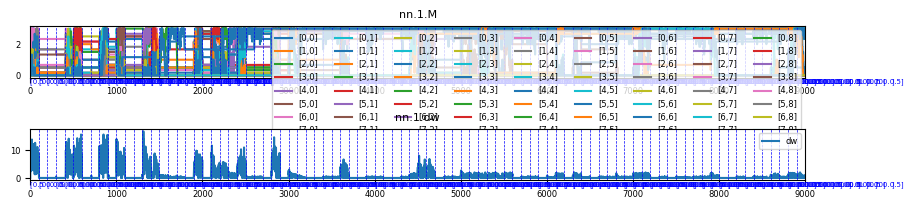

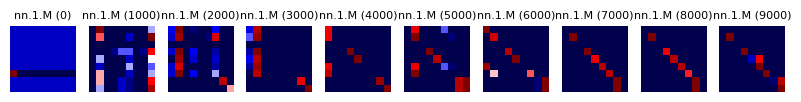

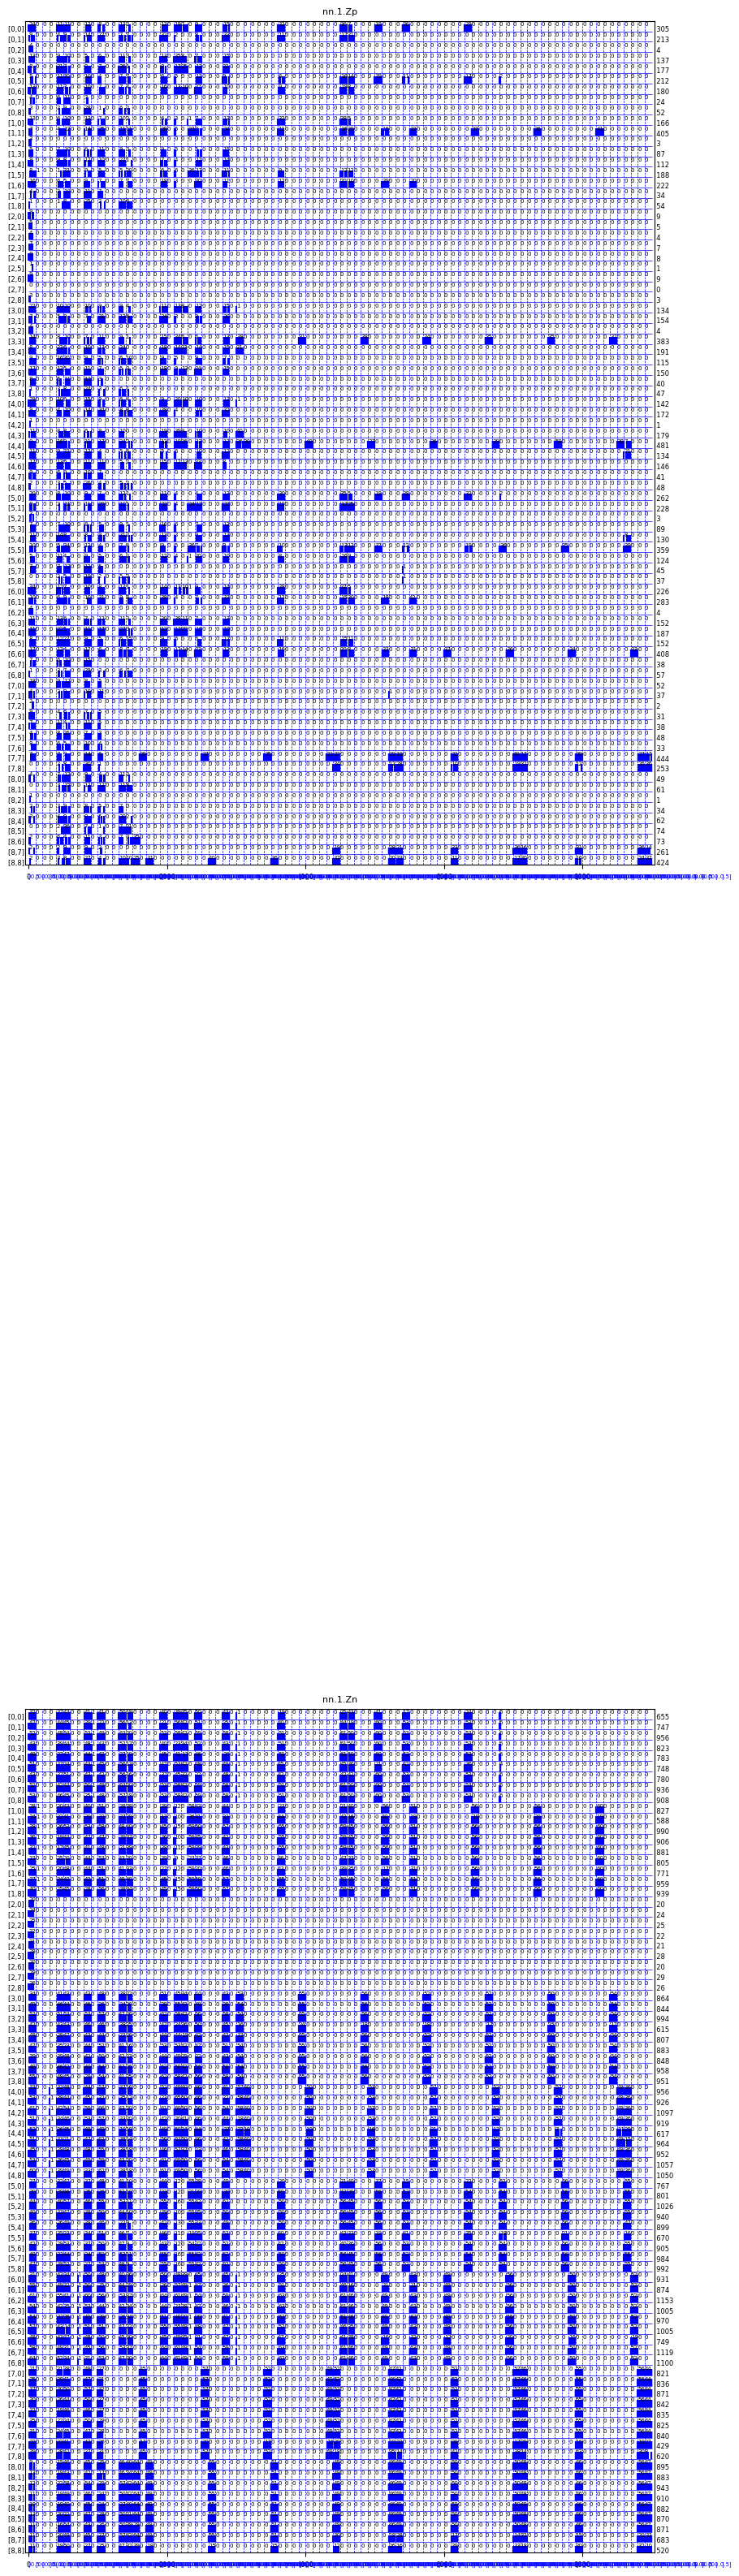

{'ref': <spikeml.core.feedback.FeedbackAdapter at 0x2440ef0ab90>,
 'context': <spikeml.core.run.Context at 0x24423037f70>}

In [13]:
print(SSNNParams().fmt())
params_9_9 = SSNNParams(g=.5,  e_err=2, t_p=2, t_d=3, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=2, vmin=0, vmax=1, cmax=3, cmin=0.0, c_in=0, c_out= 0) #-1.5
print(params_9_9.fmt())

ss_0_8 = signal_pulse(9, T=100, L=10, s=[0,1,2,3,4,5,6,7,8], value=.5)
#ss_0_8_= signal_pulse(9, T=100, L=1, s=[0,1,2,3,4,5,6,-1], value=.5)
#ss_0__8= signal_pulse(9, T=100, L=1, s=[0,-1,1,-1,2,-1,3,-1,4,-1,5,-1,6,-1], value=.5)

SIZE_9_9=[9,9]
options = None
#options = {'log.matrix': False, 'log.err': False}
result_9_9 = test_run_ssnn(size=SIZE_9_9, ss=ss_0_8, params=params_9_9, log_step=0, options=options)
result_9_9


run: 1/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D528A95A0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D74C80820>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D74C80850>, 'context': Context(t=8999)}
run: 2/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D528A9300>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021DB1BF2740>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021DB1BF24A0>, 'context': Context(t=8999)}
run: 3/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D528A9390>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D528A8BB0>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000021D528A87C0>, 'context': Context(t=8999)}
run: 4/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000021D712075E0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000021D528A93F0

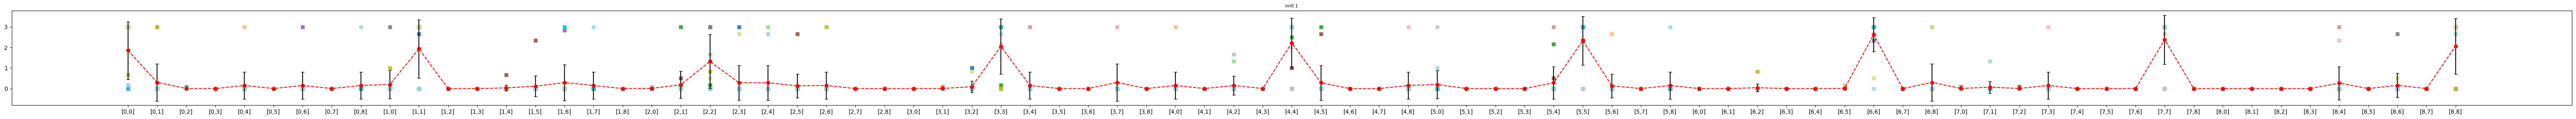

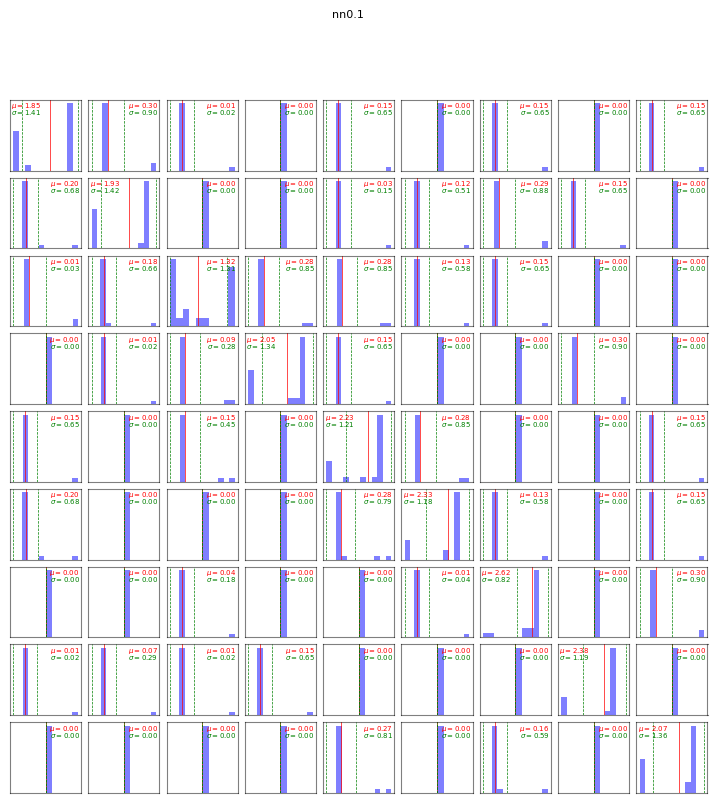

nn0.1: [0,0] x [1,0]]
  c1: [3.     0.     3.     3.     3.     3.     3.     3.     0.1667 3.     0.     3.     3.     0.1    3.     0.     0.6667
 3.     0.     0.1667]
  c2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 1. 0. 0. 0.]
  test: Mann-Whitney U test
  statistic: 341.5
  p-value: 2.1774683915172496e-05
  reject_H0: True
nn0.1: [0,0] x [2,0]]
  c1: [3.     0.     3.     3.     3.     3.     3.     3.     0.1667 3.     0.     3.     3.     0.1    3.     0.     0.6667
 3.     0.     0.1667]
  c2: [0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1]
  test: Mann-Whitney U test
  statistic: 355.0
  p-value: 3.5570880795746533e-06
  reject_H0: True
nn0.1: [0,0] x [3,0]]
  c1: [3.     0.     3.     3.     3.     3.     3.     3.     0.1667 3.     0.     3.     3.     0.1    3.     0.     0.6667
 3.     0.     0.1667]
  c2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  test: Mann-Whitney U test
  statistic: 360.0
  p-value: 7.90596

In [81]:
results_9_9 = test_nrun_ssnn(runs=20, size=SIZE_9_9, ss=ss_0_8, params=params_9_9, log_runs=1, log_step=-1, options=options)
plot_snn_stats(results_9_9)
htest_connector_identity(results_9_9)    
results_9_9.log_monitor()

In [ ]:
#size(s)=3 ;no feedback
#print(SSNNParams())
params = SSNNParams(g=2, pmax=.7, e_err=2, t_p=1, t_d=3,
                    t_b=0, t_tdp=10, e_z=3, vmin=0, vmax=1, cmax=1.5
                    , cmin=0, c_in=2, c_out= 3)
print(params)

s0 = np.array([1, 1, 0])
ss = signal_pulse(3, T=400, L=1, s=[s0,-1,2,-1], value=.3)
result = test_run_ssnn(ss=ss, params=params, mean=(.2,.1), sd=0, feedback=False, log_step=-1, debug=True)
result

## Chain - SSNN: Sensor Redundacy

In [11]:
import spikeml as sml
from spikeml.core.signal import signal_dc, signal_pulse, encode1_onehot, encode_onehot, signal_ranges, mean_per_input
from spikeml.core.matrix import matrix_split, normalize_matrix, _mult, cmask, cmask2, matrix_init, matrix_init2
from spikeml.core.monitor import Monitor
from spikeml.core.spikes import pspike, spike
from spikeml.core.base import Component, Module, Fan, Composite, Chain
from spikeml.core.snn import Layer, SimpleLayer, SNN, SSNN, SSensor, DSSNN, Connector, LinearConnector, RateConnector, LIConnector, LIConnector2
from spikeml.core.chain import make_snn_chain, make_ssnn_chain, chain_validate
from spikeml.core.snn import ssnn_apply_update
from spikeml.core.feedback import compute_error, xcompute_error, compute_sg
from spikeml.core.runner import run, nrun, Context, Results
from spikeml.core.snn_monitor import SSensorMonitor, SNNMonitor, SSNNMonitor, ConnectorMonitor, LIConnectorMonitor
from spikeml.core.snn_viewer import  SSensorMonitorViewer, SNNMonitorViewer, SSNNMonitorViewer, ConnectorMonitorViewer, LIConnectorMonitorViewer, ErrorMonitorViewer
from spikeml.core.snn_stats import connector_stats, htest_connections, htest_connector_identity
from spikeml.core.snn_stats_viewer import plot_snn_stats
      

SSNNParams:c_k=2,t_c=5.0,t_p=2.0,t_d=3.0,c_in=0.0,c_out=0.0,cmin=0.0,cmax=3.0,mean=0.1,sd=0.0,g=0.8,e_err=2.0,vmin=0.0,vmax=1.0,e_z=0.5,pf=1,pmax=0.8,t_b=20.0,e_b=2
nn <spikeml.core.base.Chain object at 0x0000015D2715CC40> :
  nn.s <spikeml.core.snn.SSensor object at 0x0000015D4B77E4D0> : (4,) OK OK
  nn.1 <spikeml.core.snn.SSNN object at 0x0000015D2715F760> : (2, 4) OK OK
t=0
nn.s: (_sx=[0.5 0. ]; _s=[0.5 0. ]) ; sx=[0.5 0.5 0.  0. ]; s=[0.5 0.5 0.  0. ]  -> zs=[1 1 0 0]
sx=[0.5 0. ]; sy=[0. 0.]; sg=0.61; s=[0.30326533 0.        ]; err=0.250
----------
t=1
nn.s: (_sx=[0.5 0. ]; _s=[0.30326533 0.        ]) ; sx=[0.5 0.5 0.  0. ]; s=[0.30326533 0.30326533 0.         0.        ]  -> zs=[0 0 0 0]
sx=[0.5 0. ]; sy=[0. 0.]; sg=0.61; s=[0.30326533 0.        ]; err=0.250
----------
t=2
nn.s: (_sx=[0.5 0. ]; _s=[0.30326533 0.        ]) ; sx=[0.5 0.5 0.  0. ]; s=[0.30326533 0.30326533 0.         0.        ]  -> zs=[0 0 0 0]
sx=[0.5 0. ]; sy=[0.8 0. ]; sg=0.61; s=[0.78848986 0.        ]; err=0.2

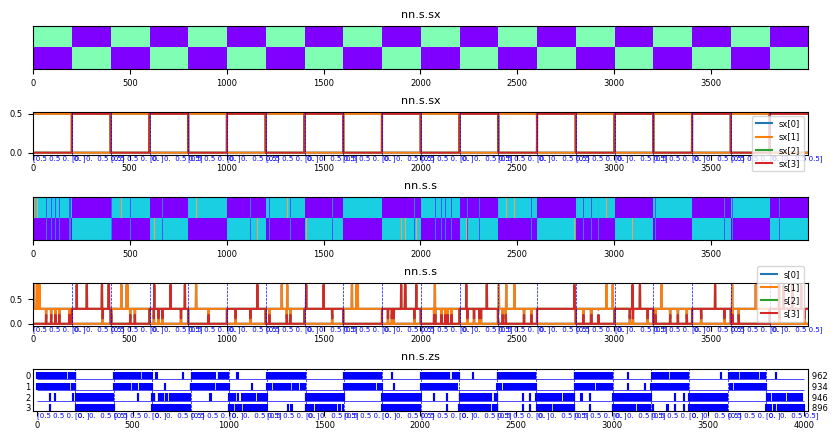

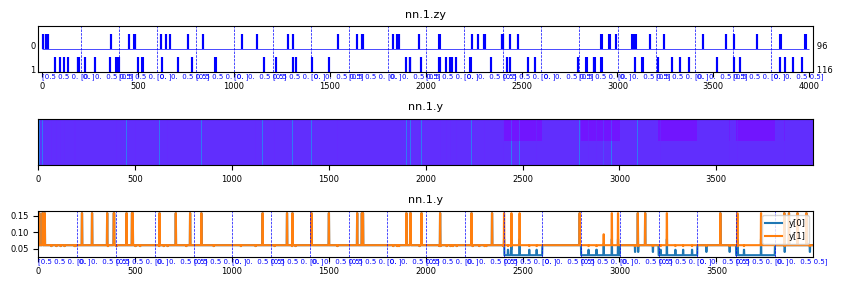

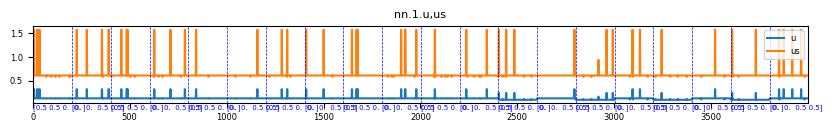

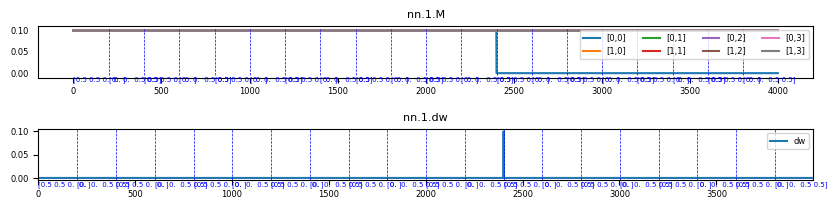

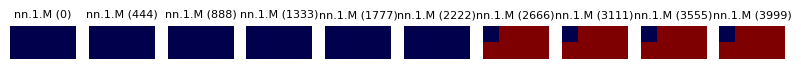

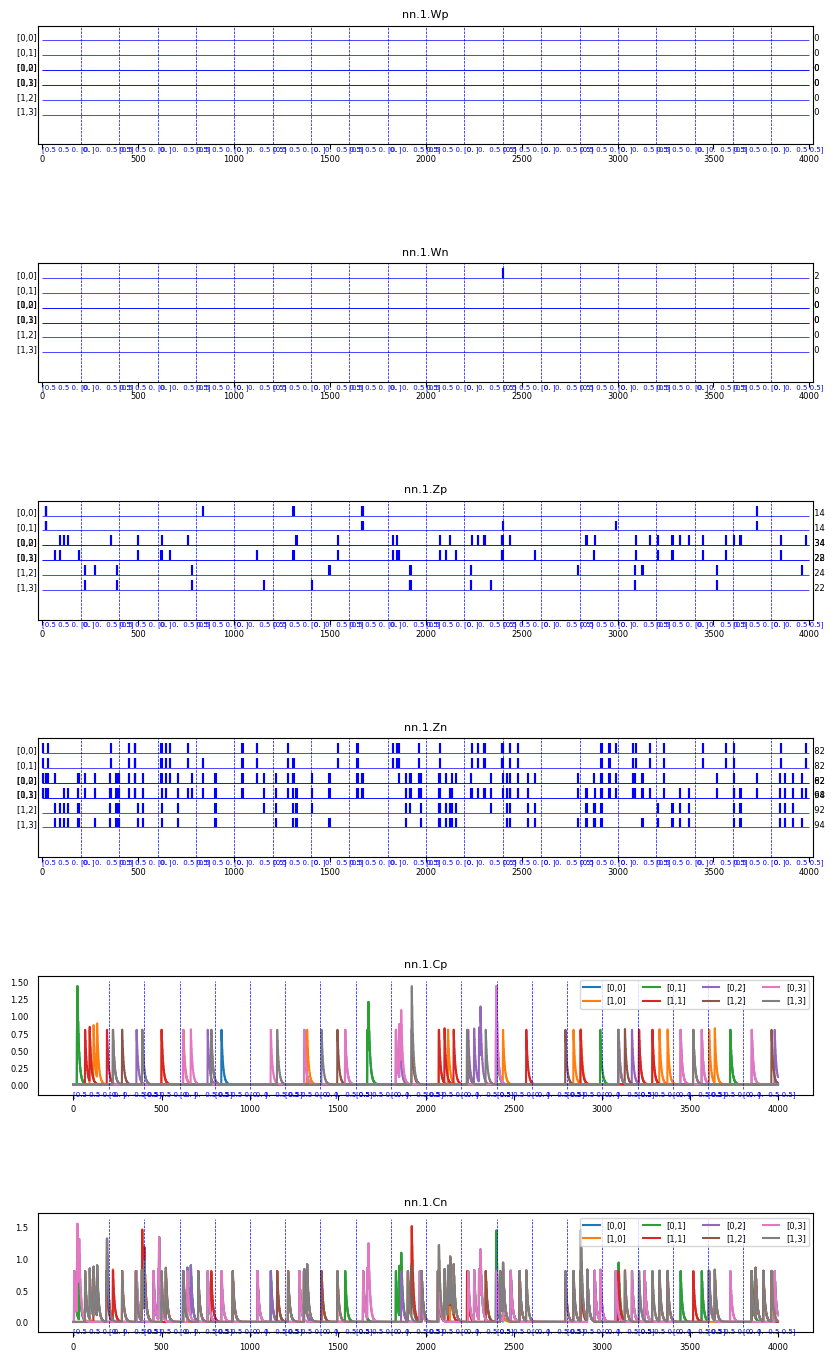

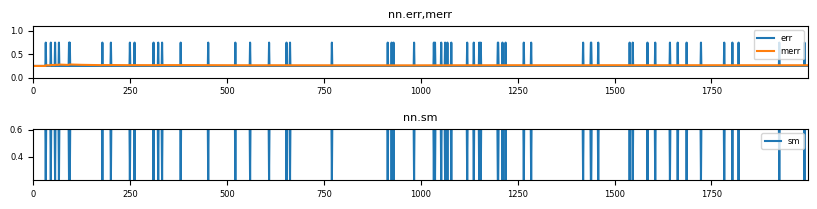

{'nn': <spikeml.core.base.Chain at 0x15d2715cc40>,
 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor at 0x15d4b77c580>,
 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer at 0x15d4b77cfd0>,
 'context': Context(t=1999)}

In [ ]:
params = SSNNParams(g=.8,  e_err=2, t_p=2, t_d=3, mean=0.1, sd=0, t_cp=5, t_cn=5,
                    t_b=20, t_tdp=10, pmax=.8, e_z=.5, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params.fmt())

ss_0_1 = signal_pulse(2, T=100, L=10, s=[0,1], value=.5)
ss_0_1_= signal_pulse(2, T=100, L=1, s=[0,-1,1,-1], value=.5)
#ss_0= signal_pulse(2, T=500, L=1, s=[0], value=.5)

SIZE_4_2=[4,2]
options = None
options = {'log.matrix': False, 'log.err': True, 'types': [SSensor]}
result = test_run_ssnn(size=SIZE_4_2, ss=ss_0_1, params=params, log_step=1, options=options)
result

run: 1/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000015D29F72D40>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000015D29FD6D70>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000015D29FD5A50>, 'context': Context(t=1999)}
run: 2/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000015D2B71A380>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000015D267B4CA0>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000015D29F73FA0>, 'context': Context(t=1999)}
run: 3/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000015D2B718B50>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000015D2B71B9A0>, 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer object at 0x0000015D2B71BAC0>, 'context': Context(t=1999)}
run: 4/20
  -> {'nn': <spikeml.core.base.Chain object at 0x0000015D2B71A3B0>, 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor object at 0x0000015D2B71A740

ValueError: 'x' and 'y' must have the same size

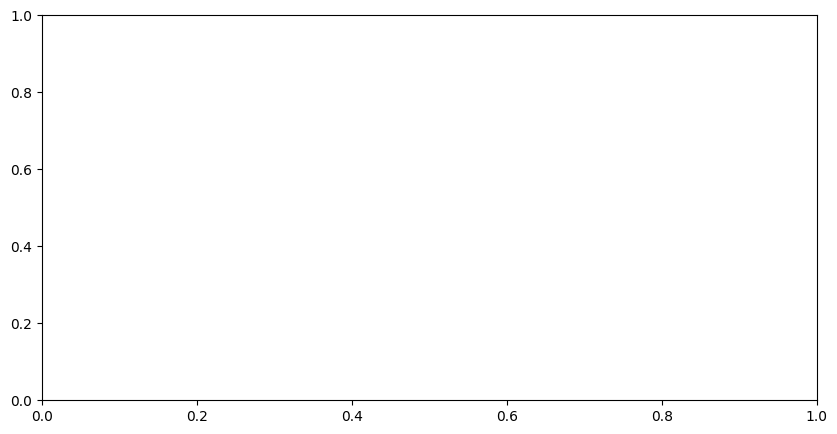

In [12]:
results = test_nrun_ssnn(runs=20, size=SIZE_4_2, ss=ss_0_1, params=params, log_runs=1, log_step=-1, options=options)
plot_snn_stats(results)
htest_connector_identity(results)    
results.log_monitor()

# Chain: SNN

SSNNParams:c_k=2,t_c=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1,t_b=20,e_b=2
SNNParams:c_k=2,t_c=10,t_p=1,t_d=5,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0.1,sd=0.0,size=2,g=1,e_err=5,vmin=0,vmax=1,e_z=2,pf=1,pmax=1,t_x=20,k_x=0.5,r_sd=0.1


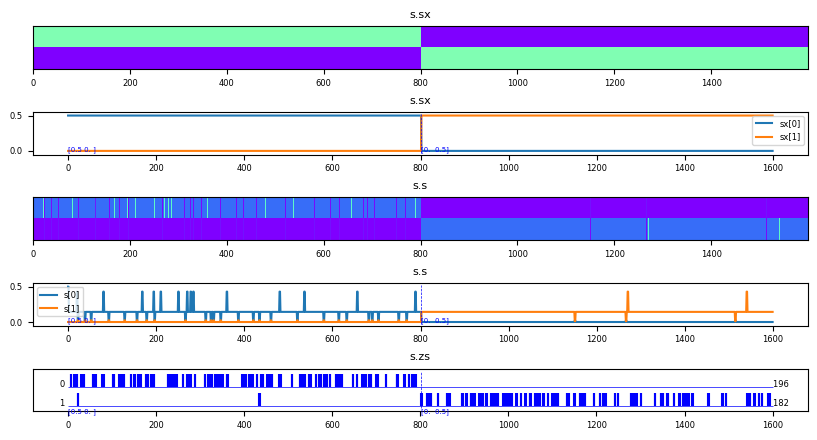

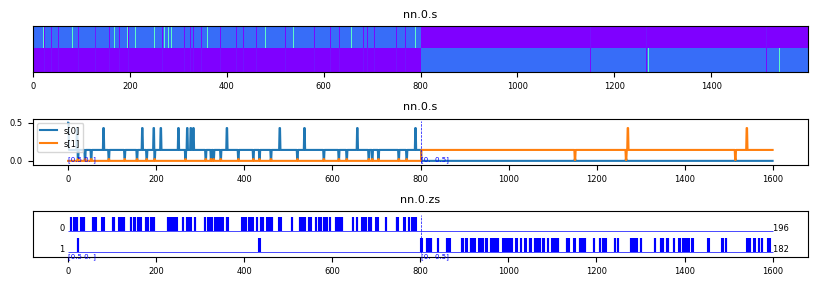

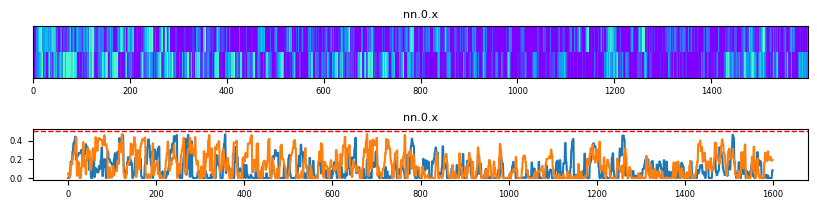

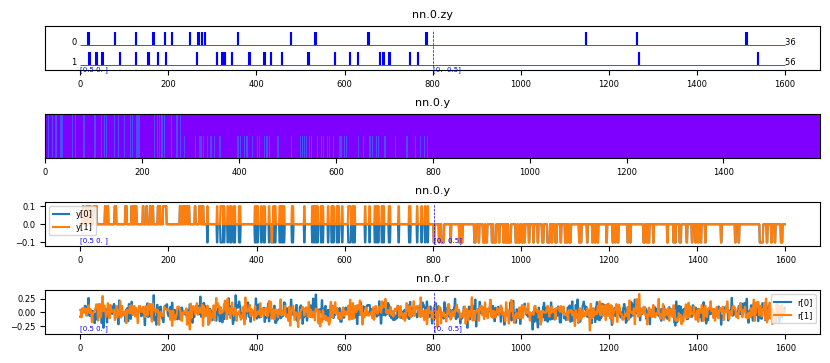

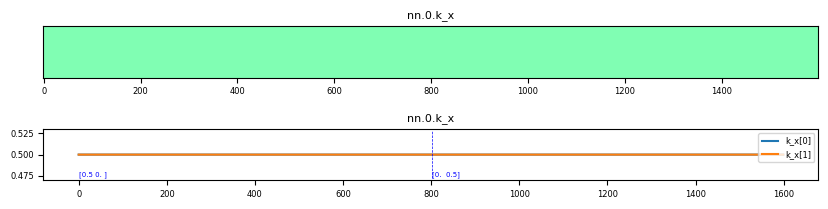

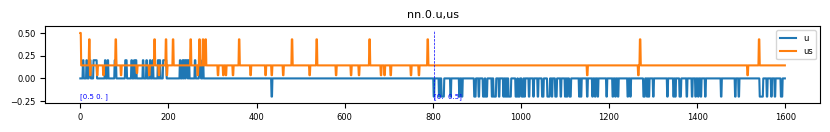

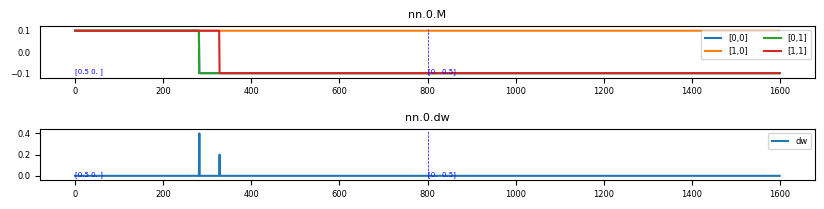

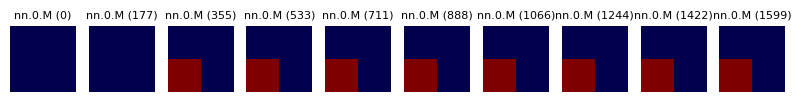

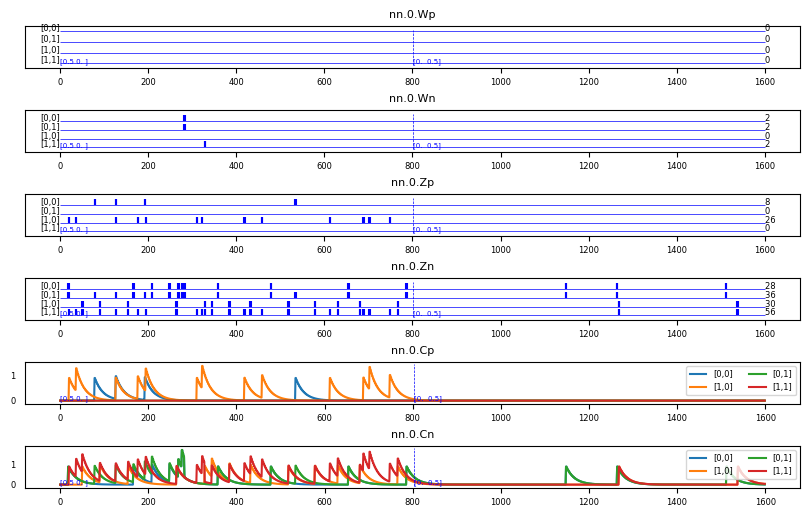

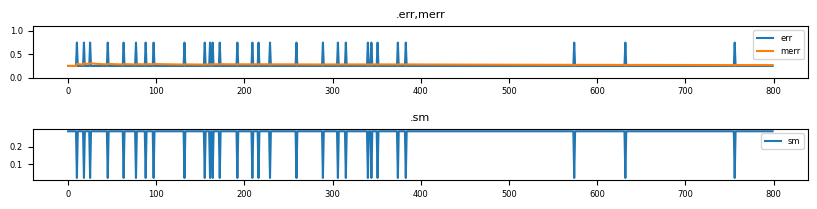

: merr: 0.2681
: 0: [0.5 0. ] (#401); Err: 0.2824
: 1: [0.  0.5] (#399); Err: 0.2538


{'nn': <spikeml.core.base.Chain at 0x1ddf0073190>,
 'err_monitor': <spikeml.core.snn_monitor.ErrorMonitor at 0x1ddf0036dd0>,
 'err_viewer': <spikeml.core.snn_viewer.ErrorMonitorViewer at 0x1ddf0035390>,
 't': 799}

In [5]:
params = SNNParams()
print(SSNNParams().fmt())
params = SNNParams(k_x=.5, r_sd=0.1, size=2, mean=.1, sd=0)
print(params.fmt())

ss_0_1 = signal_pulse(2, T=400, L=1, s=[0,1], value=.5)
ss_0_1_= signal_pulse(2, T=1000, L=1, s=[0,-1,1,-1], value=.5)
ss_0= signal_pulse(2, T=500, L=1, s=[0], value=.5)
ss=ss_0_1

SIZE=2
#SIZE=2
#SIZE=[2,2]
#SIZE=[(5,2),2]
#SIZE=[(3,2),3,2])
#SIZE=[(2,3),(3,3), (3,2)])

options = None
#options = {'log.matrix': False, 'log.err': False}

result = test_run_snn(size=SIZE, ss=ss, params=params, log_step=-1, options=options)
result

# Optimize

In [ ]:
def search_SSNN(T=2000, N=100, ss=None, mean=.1, sd=0, debug=False):
    params0 = SSNNParams(g=1, e_err=5, t_p=.5, t_d=5, pmax=1, e_z=2, c_k=2, t_cp=5, t_cn=5, c_in=0, c_out=0, cmin=0, cmax=2)
    if ss is None:
        ss = signal_pulse(2, T=200, L=1, s=[0,1], value=.5)

    def f(_params):
        
        params = setattrs(params0.model_copy(), _params)
        results = test_ssnn_apply_update(T=T, N=N, params=params, ss=ss, mean=.1, sd=0, log_step=-1, debug=False, quite=True)

        M = None
        for M_ in results:
            M = M_ if M is None else M+M_
        M /= len(results)

        err = -M[0,0]-M[1,1]+M[1,0]+M[0,1]
        err_ = float(2*M.trace() - M.sum())
        if debug:
            print('->', _params, '->', err, err_)
        return err
    
    params = set_all_attrs(SSNNParams(), None, exclude=['g', 't_p', 't_d', 't_c', 'c_k', 'pmax']) #, 't_b', 'k_b'
    spec = make_params_spec(params)
    print('search:', spec, N)
    print('>>>', params0)
    _params, err = params_search(spec, f, debug=False)
    params = setattrs(params0.model_copy(), _params)
    print('<<<', params, '->', err)
    return _params, params
    
_params, params = search_SSNN(T=1000, N=50, debug=False)
#print(_params)
#print(params)

NameError: name 'set_all_attrs' is not defined

In [ ]:
def search_nn1(runs=1, mean=0.0, sd=0.1, debug=False):
    ss_0_1 = signal_pulse(2, T=200, L=1, s=[0,1], value=.3)
    ss_0= signal_pulse(2, T=1000, L=1, s=[0], value=.1)
    ss_0_= signal_pulse(2, T=200, L=1, s=[0,0,0,0,-1], value=.3)

    def f(_params):
        params = setattrs(SSNNParams(), _params)
        #print('->', _params, params)
        if runs==1:
            result = test_run_ssnn(ss=ss_0, params=params, mean=.1, sd=0, log_step=-1, plot=False, debug=False)
            M = result['nn'].M
        else:
            results = nrun(runs=runs, nn_creator= lambda n,_: make_ssnn(name=f'nn{n}', params=params, ss=ss_0, mean=mean, sd=sd),
                ss=ss_0, params=params, feedback=True, plot=False, log_runs=-1, log_step=-1, debug=False)
            M = None
            for result in results:
                M = result['nn'].M if M is None else M+result['nn'].M
            M /= len(reults)

        err = -M[0,0]+M[0,1]+M[1,0]+M[1,1]
        if debug:
            print('->', _params, '->', err)
        return err
    
        
    params = set_all_attrs(SSNNParams(), None, exclude=['g', 't_p', 't_d', 'pmax'])
    spec = make_params_spec(params)
    print('search:', spec, runs)
    _params, err = params_search(spec, f, debug=False)
    params = setattrs(SSNNParams(), _params)
    print('>>>', _params, params, '->', err)
    return _params, params
    
_params, params = search_nn1(runs=1, debug=False)

search: {'g': (1, (0, 2)), 't_w': (1, (0, 2)), 't_wn': (5, (0, 10)), 'pmax': (0.5, (0, 1))} 1
>>> {'g': 1.0000004584460764, 't_w': 1.000000458084401, 't_wn': 5.000002296376916, 'pmax': 0.5000002301351621} SSNNParams({'g': 1.0000004584460764, 'e_err': 0.05, 't_w': 1.000000458084401, 't_wn': 5.000002296376916, 'e_z': 2, 'e_ltp': 0.5, 't_tdp': 5, 'pf': 1, 'pmax': 0.5000002301351621, 'k_ltd': 0.2, 'f_ltd': 0.5, 'k_in': 1, 'k_out': 1, 't_b': 20, 'k_b': 2, 'cmin': -2, 'cmax': 2, 'vmin': 0, 'vmax': 1}) -> -0.0544243666473265


SSNNParams({'g': 2.0, 'e_err': 2.0, 't_w': 1.0, 't_wn': 3.0, 'e_z': 3.0, 'e_ltp': 0.5, 't_tdp': 10.0, 'pf': 1, 'pmax': 0.7, 'k_ltd': 0.2, 'f_ltd': 0.5, 'k_in': 0.0, 'k_out': 0.0, 't_b': 0.0, 'k_b': 2, 'cmin': 0.0, 'cmax': 3.0, 'vmin': 0.0, 'vmax': 1.0})
SSNNParams({'g': 2.0, 'e_err': 2.0, 't_w': 1.0, 't_wn': 3.0, 'e_z': 3.0, 'e_ltp': 0.5, 't_tdp': 10.0, 'pf': 1, 'pmax': 0.7, 'k_ltd': 0.2, 'f_ltd': 0.5, 'k_in': 0.0, 'k_out': 0.0, 't_b': 0.0, 'k_b': 2, 'cmin': 0.0, 'cmax': 3.0, 'vmin': 0.0, 'vmax': 1.0})
t=0
nn: s=[0.3 0.  0. ] | zs=[1 0 0] -> y=[0.03 0.03 0.03] | zy=[1 0 0] | z=[0.03 0.   0.  ]
----------
t=999
nn: s=[0.1646 0.     0.    ] | zs=[1 0 0] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]
----------


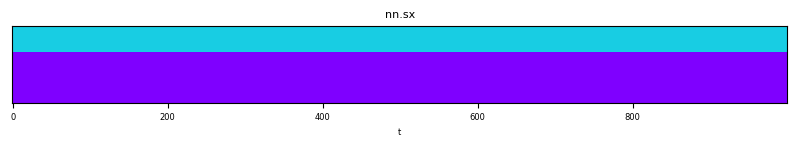

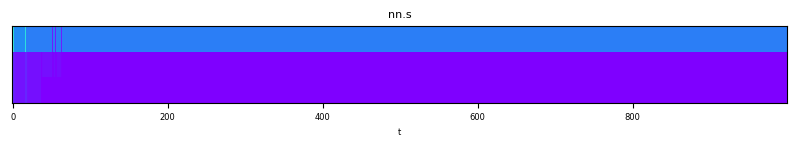

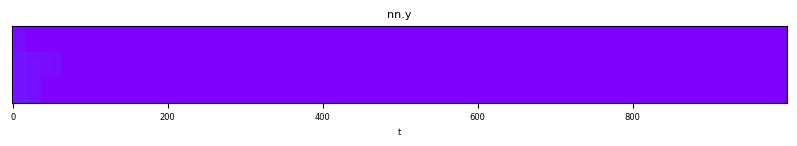

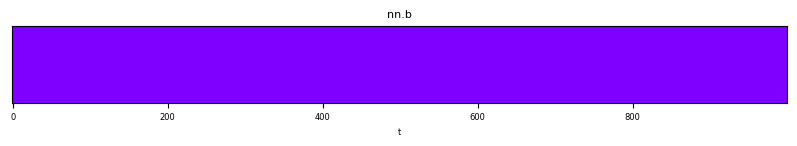

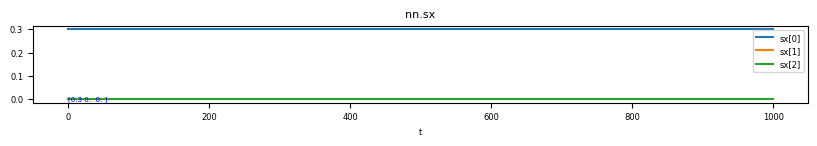

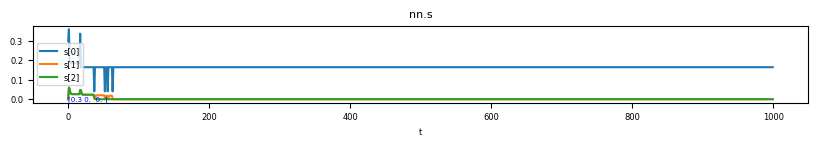

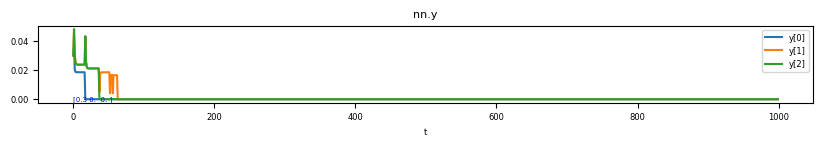

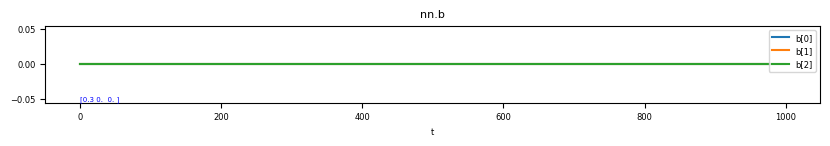

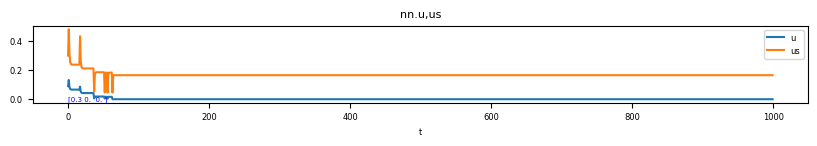

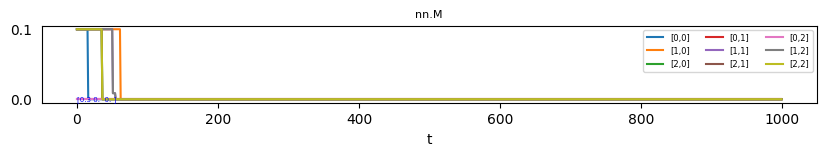

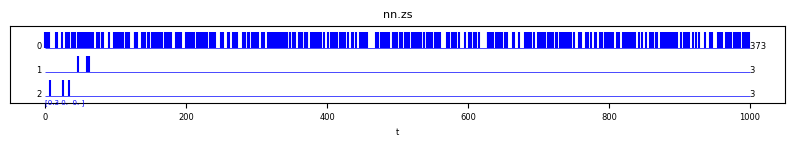

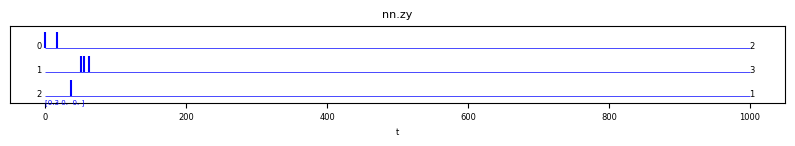

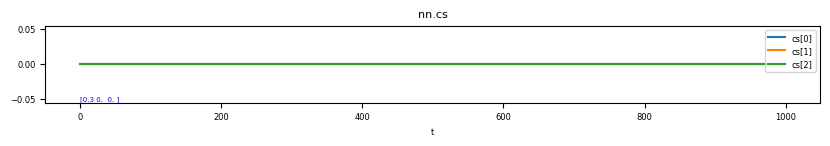

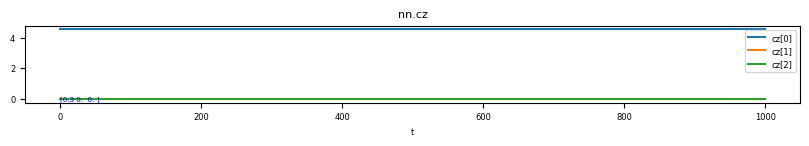

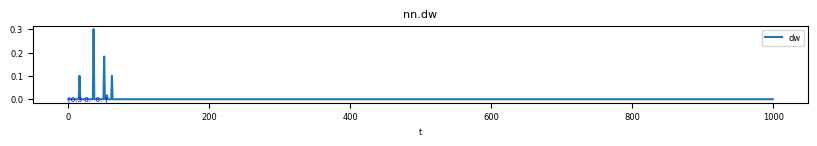

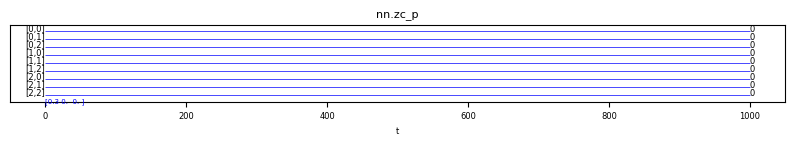

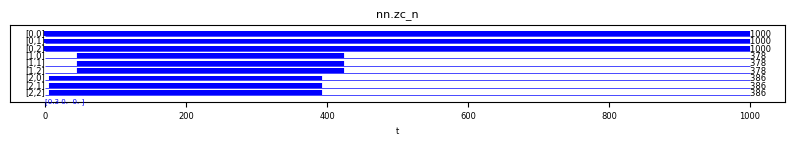

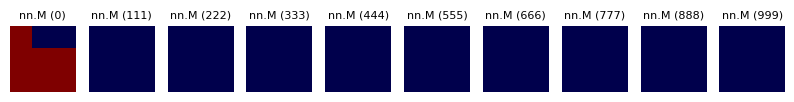

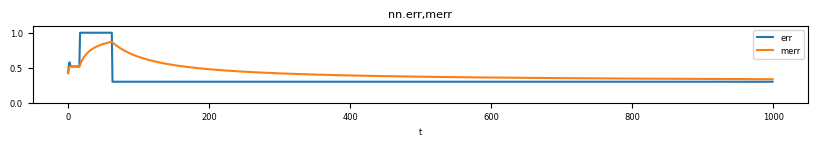

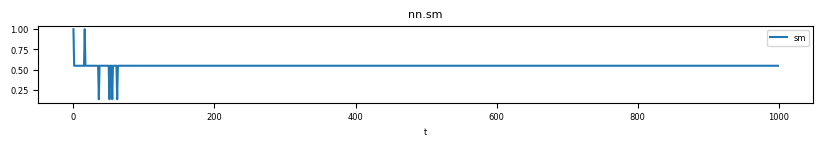

nn: merr: 0.3359
nn: 0: [0.3 0.  0. ] (#1000); Err: 0.3359


{'nn': <__main__.SSANN at 0x1ff297600d0>,
 'err_stats': <__main__.ErrorStats at 0x1ff2b6cee90>,
 'err_viewer': <__main__.ErrorStatsViewer at 0x1ff29553580>,
 't': 999}

In [ ]:
#size(s)=3
#print(SSNNParams())
params = SSNNParams(g=2, pmax=.7, e_err=2, t_p=1, t_d=3,
                    t_b=0, t_tdp=10, e_z=3, vmin=0, vmax=1, cmax=3, cmin=0, c_in=0, c_out= 0) #-1.5
print(params)
ss_0= signal_pulse(3, T=1000, L=1, s=[0], value=.3)
ss_0_1_2_0_= signal_pulse(3, T=500, L=1, s=[0,1,2,0,-1], value=.3)
ss_1_0_2_1_= signal_pulse(3, T=500, L=1, s=[1,0,2,1,-1], value=.3)

ss=ss_0 #ss_0_1_2_0_
def _monitor(c):
    #if c.t>500 and c.t<1000: print(f't:{c.t}')
    pass
    
result = test_run_ssnn(ss=ss, params=params, mean=.1, sd=0, log_step=-1, options={'log.matrix': False, 'log.err': False}, debug=True, callback=_monitor)
result

SSNNParams({'g': 2.0, 'e_err': 2.0, 't_w': 1.0, 't_wn': 3.0, 'e_z': 3.0, 'e_ltp': 0.5, 't_tdp': 10.0, 'pf': 1, 'pmax': 0.7, 'k_ltd': 0.2, 'f_ltd': 0.5, 'k_in': 2.0, 'k_out': 3.0, 't_b': 0.0, 'k_b': 2, 'cmin': -1.5, 'cmax': 1.5, 'vmin': 0.0, 'vmax': 1.0})
SSNNParams({'g': 2.0, 'e_err': 2.0, 't_w': 1.0, 't_wn': 3.0, 'e_z': 3.0, 'e_ltp': 0.5, 't_tdp': 10.0, 'pf': 1, 'pmax': 0.7, 'k_ltd': 0.2, 'f_ltd': 0.5, 'k_in': 2.0, 'k_out': 3.0, 't_b': 0.0, 'k_b': 2, 'cmin': -1.5, 'cmax': 1.5, 'vmin': 0.0, 'vmax': 1.0})
t=0
nn: s=[0.3 0.  0. ] | zs=[1 0 0] -> y=[0.03 0.03 0.03] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0.3 0.  0. ]; s=[0.1976 0.0329 0.0329]; err=0.423 ; sm=0.549
----------
t=500
nn: s=[0.1646 0.     0.    ] | zs=[1 0 0] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0.  0.3 0. ]; s=[0.     0.1646 0.    ]; err=0.300 ; sm=0.549
----------
t=1000
nn: s=[0.     0.1646 0.    ] | zs=[0 1 0] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0.  0.  0.3]; s=[0.     0.     0.1646]; err=0.300 ; sm=0.549
----------
t=1500
nn: s=[0.     0.     0.1646] | zs=[0 0 1] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0.3 0.  0. ]; s=[0.1646 0.     0.    ]; err=0.300 ; sm=0.549
----------
t=2000
nn: s=[0.1646 0.     0.    ] | zs=[0 0 0] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0. 0. 0.]; s=[0. 0. 0.]; err=0.300 ; sm=0.549
----------
t=2499
nn: s=[0. 0. 0.] | zs=[0 0 0] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0. 0. 0.]; s=[0. 0. 0.]; err=0.000 ; sm=1.000
----------


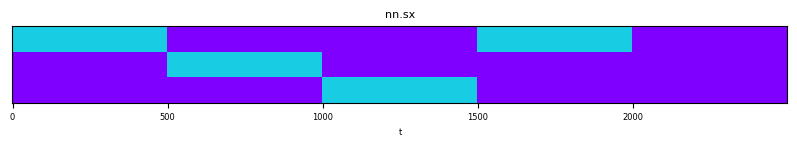

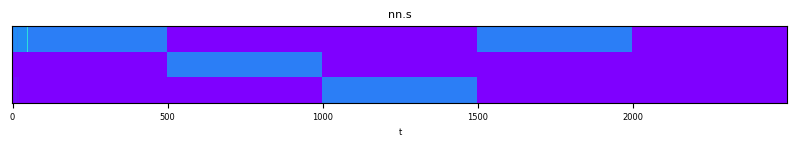

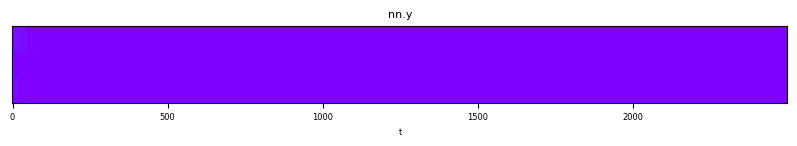

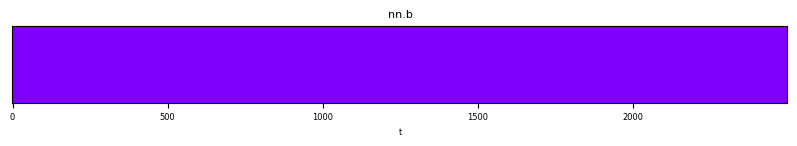

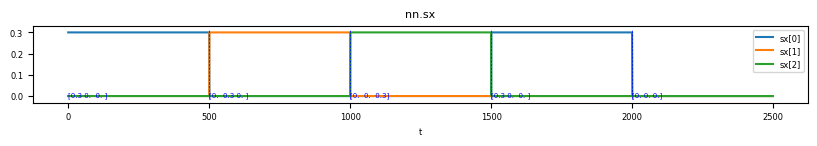

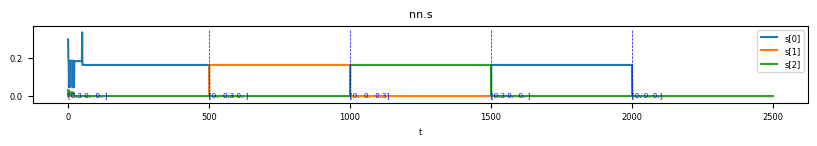

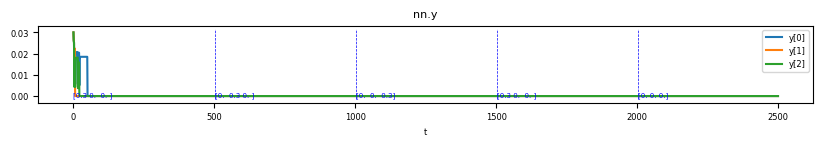

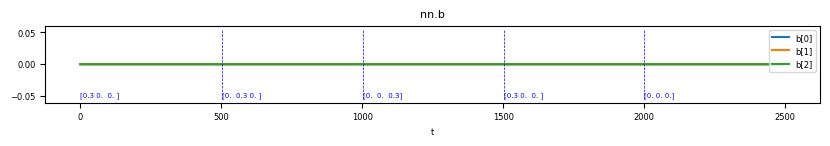

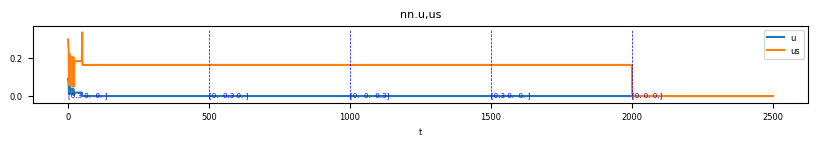

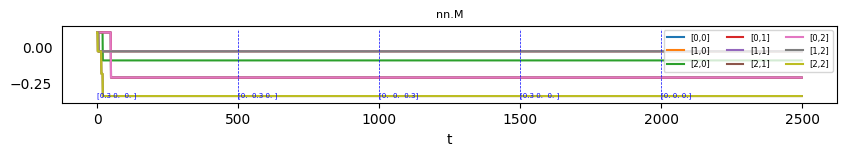

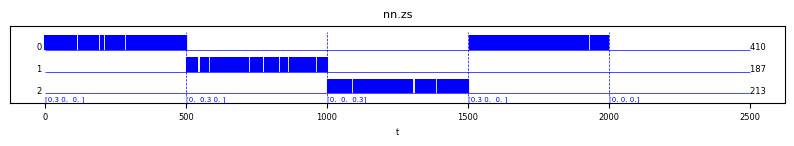

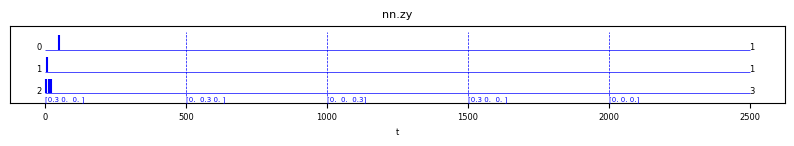

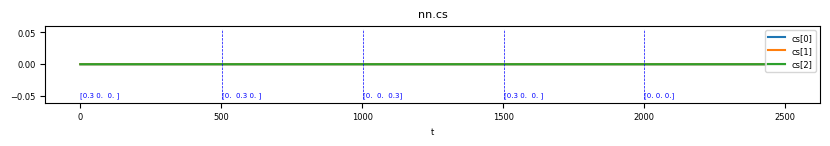

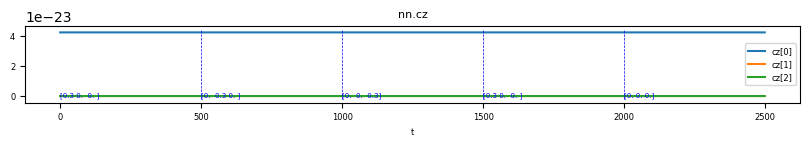

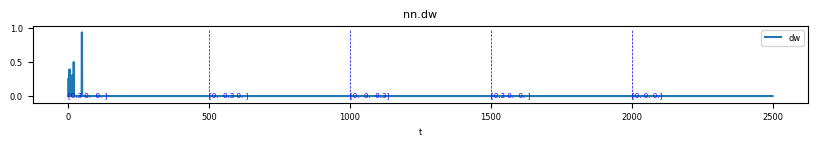

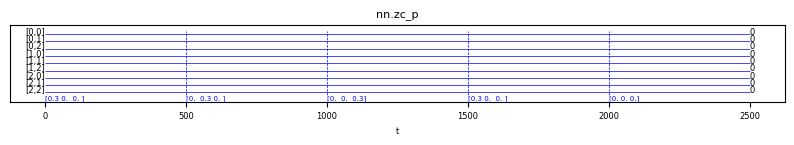

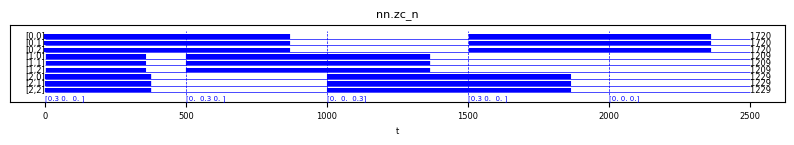

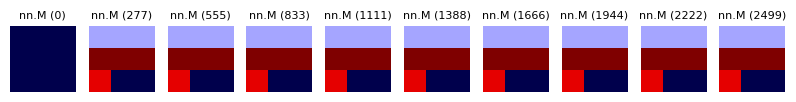

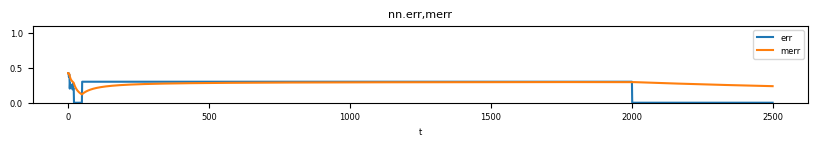

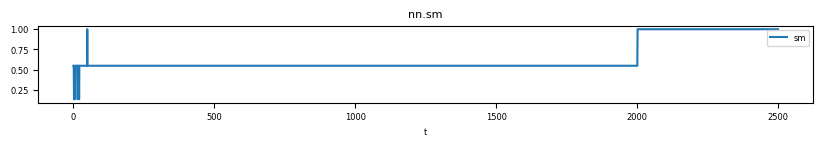

nn: merr: 0.2365
nn: 0: [0.3 0.  0. ] (#1001); Err: 0.2910
nn: 1: [0.  0.3 0. ] (#500); Err: 0.3000
nn: 2: [0.  0.  0.3] (#500); Err: 0.3000
nn: 3: [0. 0. 0.] (#499); Err: 0.0000


{'nn': <__main__.SSANN at 0x1ff2d8e4cd0>,
 'err_stats': <__main__.ErrorStats at 0x1ff299fbc40>,
 'err_viewer': <__main__.ErrorStatsViewer at 0x1ff299f86a0>,
 't': 2499}

In [ ]:
#size(s)=3 ; M twin
#print(SSNNParams())
params = SSNNParams(g=2, pmax=.7, e_err=2, t_p=1, t_d=3,
                    t_b=0, t_tdp=10, e_z=3, vmin=0, vmax=1, cmax=1.5, cmin=-1.5, c_in=2, c_out= 3)
print(params)
ss_0_1_2_0_= signal_pulse(3, T=500, L=1, s=[0,1,2,0,-1], value=.3)
ss_1_0_2_1_= signal_pulse(3, T=500, L=1, s=[1,0,2,1,-1], value=.3)

ss=ss_0_1_2_0_
result = test_run_ssnn(ss=ss, params=params, mean=(.2,.1), sd=0, log_step=500, debug=True)
result

SRLParams{'t_w': 5, 't_wn': 5, 'k_z': 0.5, 'k_ltd': 0.2, 'k_in': 1, 'k_out': 1, 't_b': 30, 'k_b': 2, 'vmin': 0, 'vmax': 1}
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
t=0
nn: s=[0.5 0.  0. ] | zs=[0 0 0] -> y=[0.05 0.05 0.05] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0.5 0.  0. ]; s=[0.5 0.  0. ]; err=0.423 
----------
t=200
nn: s=[0.  0.5 0. ] | zs=[0 1 0] -> y=[0.     0.0407 0.    ] | zy=[0 1 0] | z=[0.     0.0407 0.    ]


sx=[0.  0.5 0. ]; s=[0.     0.5407 0.    ]; err=0.000 ; dy: {dy:.3f}
----------
t=400
nn: s=[0.  0.  0.5] | zs=[0 0 1] -> y=[0.     0.     0.1634] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0. 0. 0.]; s=[0. 0. 0.]; err=0.000 ; dy: {dy:.3f}
----------
t=600
nn: s=[0. 0. 0.] | zs=[0 0 0] -> y=[0. 0. 0.] | zy=[0 0 0] | z=[0. 0. 0.]


sx=[0.  0.5 0. ]; s=[0.  0.5 0. ]; err=0.000 ; dy: {dy:.3f}
----------
t=800
nn: s=[0. 0. 1.] | zs=[0 0 1] -> y=[0.     0.     0.6912] | zy=[0 0 1] | z=[0.     0.     0.6912]


sx=[0.  0.  0.5]; s=[0. 0. 1.]; err=0.000 ; dy: {dy:.3f}
----------


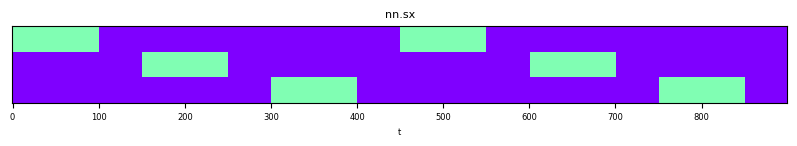

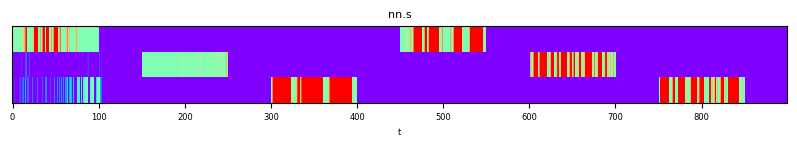

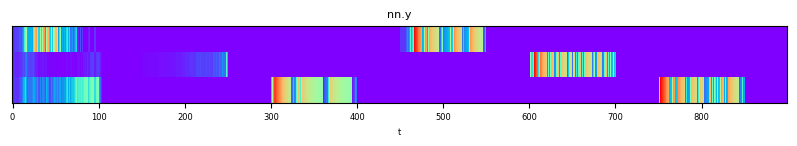

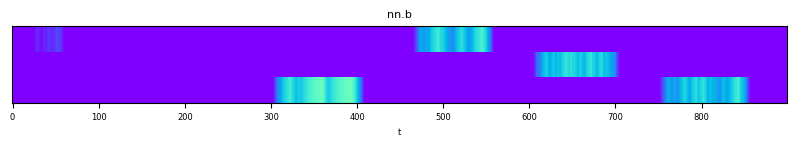

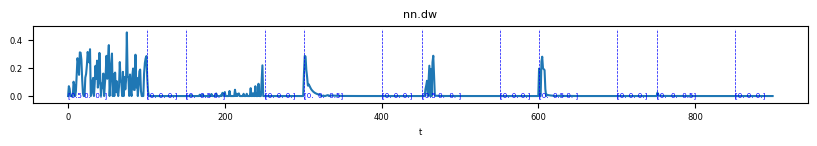

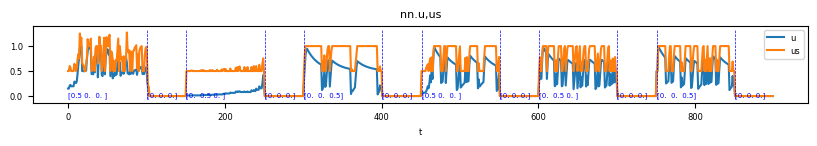

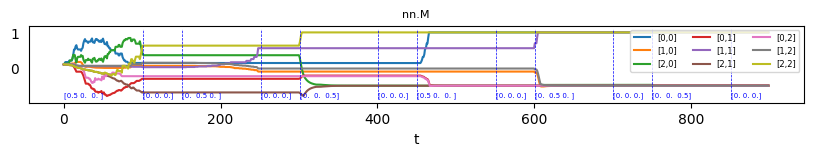

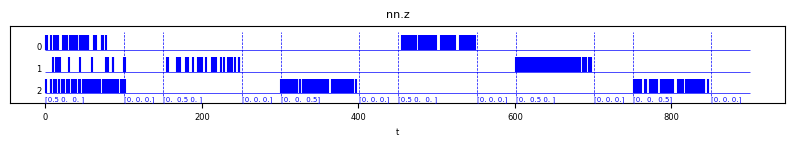

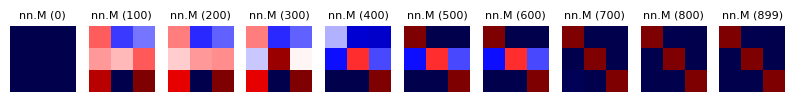

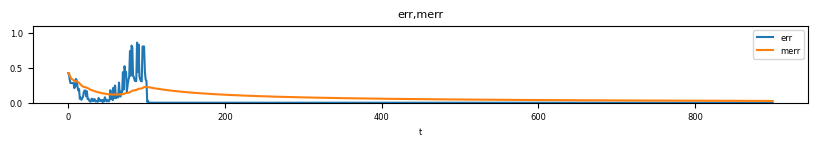

0: [0.5 0.  0. ] (#201); Err: 0.1139
1: [0. 0. 0.] (#299); Err: 0.0001
2: [0.  0.5 0. ] (#200); Err: 0.0000
3: [0.  0.  0.5] (#200); Err: 0.0000


In [ ]:
#M = np.array([[0.98,-1.00],[0.02,0.21]])
mean=.1 #(.1, .05)

params = SSNNParams(t_p=5, t_d=5, t_b=30, e_z=K_Z) #
#params = SSNNParams(t_p=5, t_d=-1, t_b=10, e_z=K_Z) #

#ss_0__4
result = test_run_ssnn(ss=ss_0__1__2, params=params, DY=-1, mean=mean, sd=0, log_step=200, debug=True)
result

SRLParams{'t_w': 5, 't_wn': 40, 'k_z': 0.5, 'k_ltd': 0.2, 'k_in': 1, 'k_out': 1, 't_b': 30, 'k_b': 2, 'vmin': 0, 'vmax': 1}
[[ 0.018  -0.049  -0.0426]
 [-0.0105  0.0685  0.034 ]
 [-0.1158 -0.0092 -0.0451]
 [ 0.0447 -0.1452 -0.1373]
 [-0.0699 -0.0051 -0.0719]]
t=0
nn: s=[0.5 0.5 0. ] | zs=[0 1 0] -> y=[0.    0.029 0.    0.    0.   ] | zy=[0 0 0 0 0] | z=[0. 0. 0. 0. 0.]


----------
t=200
nn: s=[0.  0.  0.5] | zs=[0 0 1] -> y=[0. 0. 0. 0. 0.] | zy=[0 0 0 0 0] | z=[0. 0. 0. 0. 0.]


----------
t=400
nn: s=[0.5 0.5 0. ] | zs=[1 1 0] -> y=[0.  0.5 0.  0.  0. ] | zy=[0 1 0 0 0] | z=[0.  0.5 0.  0.  0. ]


----------


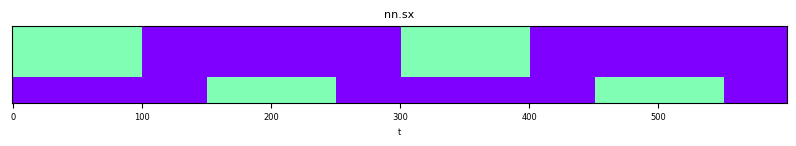

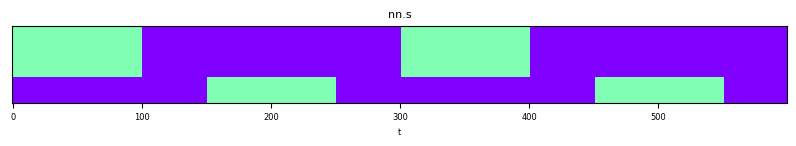

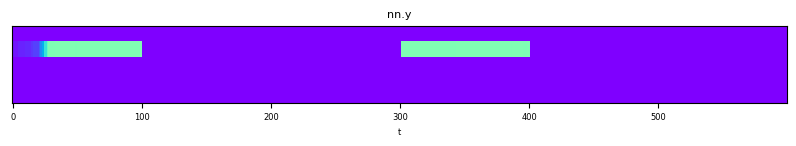

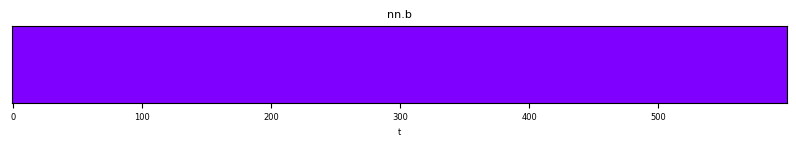

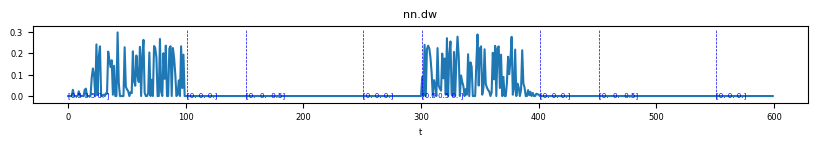

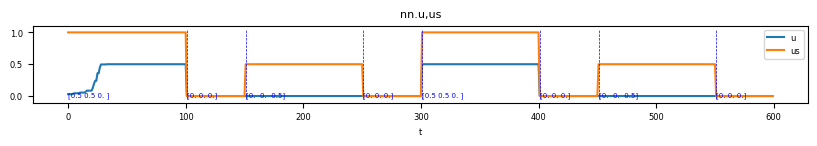

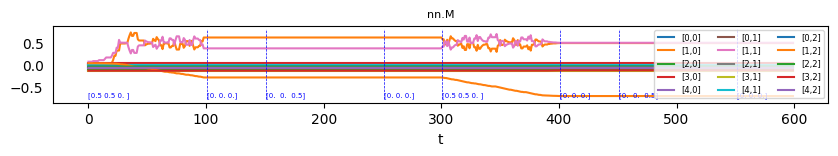

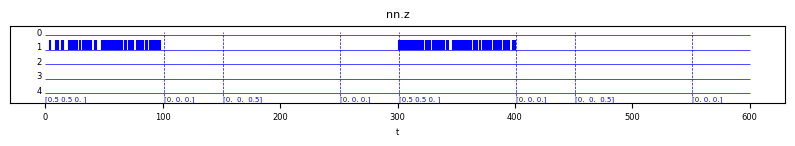

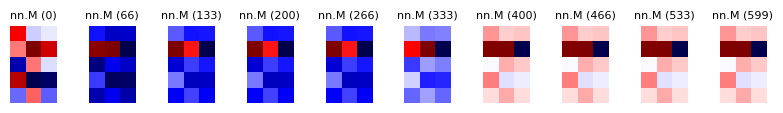

(<__main__.SATRL at 0x1d1f9ae6da0>, None, 599)

In [ ]:
params = SSNNParams(t_p=5, t_d=40, t_b=30, e_z=K_Z) #
#params = SSNNParams(t_p=5, t_d=-1, t_b=10, e_z=K_Z) #
#ss_0__4
result = test_run_ssnn(ss=ss3_3__0, size=(5, 3), feedback=False, params=params, DY=-1, mean=0, sd=0.1, log_step=200, debug=True)
result